<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🧬 Diabetes Prediction Challenge ❤️
    </h1>
</div>

# 📂 Overview

**Background**

The **Diabetes Health Indicators** dataset is constructed from synthesized health-related attributes that resemble real-world clinical and behavioral data used to assess diabetes risk. The dataset includes a wide range of **clinical metrics, lifestyle factors, and demographic information**, making it suitable for research on predictive modeling, health risk analysis, and designing scoring systems.

This dataset contains a mix of **numerical and categorical** variables reflecting lifestyle choices (diet, alcohol intake, physical activity), biological measurements (BMI, cholesterol, triglycerides, blood pressure), and medical history (hypertension, cardiovascular diseases, family diabetes history).

The dataset is ideal for:

* **In-depth Exploratory Data Analysis (EDA)**
* **Feature engineering & risk scoring**
* **Binary classification modeling**
* **Benchmarking and comparing ML algorithms on health data**

**Goal of the Project**

Build a machine learning model to **predict the likelihood of diabetes** (`diagnosed_diabetes`: 0/1) based on health indicators and lifestyle behaviors.

**Key Features**

| Feature Name                         | Description                                                    |
| ------------------------------------ | -------------------------------------------------------------- |
| `id`                                 | Unique identifier, not used for modeling                       |
| `age`                                | Age of the individual                                          |
| `alcohol_consumption_per_week`       | Weekly alcohol consumption                                     |
| `physical_activity_minutes_per_week` | Total minutes of physical activity per week                    |
| `diet_score`                         | Nutrition quality score                                        |
| `sleep_hours_per_day`                | Average hours of sleep per day                                 |
| `screen_time_hours_per_day`          | Daily screen time (phone/computer)                             |
| `bmi`                                | Body Mass Index                                                |
| `waist_to_hip_ratio`                 | Waist-to-hip ratio, indicator of visceral fat                  |
| `systolic_bp`                        | Systolic blood pressure                                        |
| `diastolic_bp`                       | Diastolic blood pressure                                       |
| `heart_rate`                         | Heart rate                                                     |
| `cholesterol_total`                  | Total cholesterol                                              |
| `hdl_cholesterol`                    | HDL cholesterol (good cholesterol)                             |
| `ldl_cholesterol`                    | LDL cholesterol (bad cholesterol)                              |
| `triglycerides`                      | Triglyceride level                                             |
| `gender`                             | Gender                                                         |
| `ethnicity`                          | Ethnic group                                                   |
| `education_level`                    | Education level                                                |
| `income_level`                       | Income level                                                   |
| `smoking_status`                     | Smoking status                                                 |
| `employment_status`                  | Employment status                                              |
| `family_history_diabetes`            | Family history of diabetes                                     |
| `hypertension_history`               | History of hypertension                                        |
| `cardiovascular_history`             | History of cardiovascular diseases                             |
| `diagnosed_diabetes`                 | Target variable (0 = no diabetes, 1 = diagnosed with diabetes) |

**Files Provided**

From *Kaggle Playground Series – Season 5, Episode 12*:

* `train.csv`: Training dataset with target.
* `test.csv`: Test dataset without target.
* `sample_submission.csv`: Submission template.
* Data is synthetically generated based on realistic health indicator distributions.

(Source: [Kaggle Competition – S5E12](https://www.kaggle.com/competitions/playground-series-s5e12))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
!pip install statsmodels > pip_log_statsmodels.txt 2>&1
!pip install scikit_posthocs > pip_log_scikit_posthocs.txt 2>&1
!pip install pingouin > pip_log_pingouin.txt 2>&1

In [2]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import shap

# Statistical functions
from scipy.stats import skew, kurtosis, probplot

# Display utilities for Jupyter notebooks
from IPython.display import display, HTML

# Machine learning preprocessing and modeling
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix

import xgboost as xgb

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Metrics
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             precision_recall_curve, average_precision_score)

# Statistical
from scipy.stats import chi2_contingency
from scipy.stats import probplot
from scipy.stats import kruskal
import scikit_posthocs as sp
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
from scipy.stats import levene
from scipy import stats
import pingouin as pg
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

In [3]:
class Config:
    seed = 42
    max_iter = 50000
    n_split_shuffle = 1
    n_split_kfold = 5
    test_size = 0.2
    train_csv = "/kaggle/input/playground-series-s5e12/train.csv"
    test_csv = "/kaggle/input/playground-series-s5e12/test.csv"
    target_feature = "diagnosed_diabetes"   

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [4]:
# Load the datasets
df_train = pd.read_csv(Config.train_csv)
df_test = pd.read_csv(Config.test_csv)

# Verify shapes
print("[i] Train Data Shape:", df_train.shape)
print("\n[i] Test Data Shape:", df_test.shape)

[i] Train Data Shape: (700000, 26)

[i] Test Data Shape: (300000, 25)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [5]:
# Display few rows of each dataset
print("[i] Train Data Preview:")
display(df_train.head())

print("\n[i] Test Data Preview:")
display(df_test.head())

[i] Train Data Preview:


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,62,199,58,114,102,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,71,199,50,121,124,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,73,188,59,114,108,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,74,182,54,85,123,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,85,206,49,131,124,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0



[i] Test Data Preview:


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history
0,700000,45,4,100,4.3,6.8,6.2,25.5,0.84,123,70,64,209,55,135,111,Female,White,Highschool,Middle,Former,Employed,0,0,0
1,700001,35,1,87,3.5,4.6,9.0,28.6,0.88,120,74,59,159,47,83,145,Female,White,Highschool,Middle,Never,Unemployed,0,0,0
2,700002,45,1,61,7.6,6.8,7.0,28.5,0.94,112,71,75,173,43,99,184,Male,White,Highschool,Low,Never,Employed,0,0,0
3,700003,55,2,81,7.3,7.3,5.0,26.9,0.91,114,81,61,203,59,116,128,Male,White,Graduate,Middle,Former,Employed,0,0,0
4,700004,77,2,29,7.3,7.6,8.5,22.0,0.83,131,78,79,177,59,87,133,Male,White,Graduate,Low,Current,Unemployed,0,0,0


In [6]:
# Display information about the DataFrames
print("[i] Displaying Train Data Info:")
df_train.info()

print("\n[i] Displaying Test Data Info:")
df_test.info()

print("\n[✓] Completed displaying DataFrame info.")

[i] Displaying Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  

**Dataset Size and Structure**

* **Train:** 700000 samples · 26 columns (including target `diagnosed_diabetes`)
* **Test:** 300000 samples · 25 columns (no `diagnosed_diabetes`), ready for prediction.

**Feature Overview**

* **Numerical features:**
`age`, `physical_activity_minutes_per_week`, `diet_score`, `sleep_hours_per_day`, `screen_time_hours_per_day`, `bmi`, `waist_to_hip_ratio`, `systolic_bp`, `diastolic_bp`, `heart_rate`, `cholesterol_total`, `hdl_cholesterol`, `ldl_cholesterol`, `triglycerides`.

* **Categorical features:**
`alcohol_consumption_per_week`, `gender`, `ethnicity`, `education_level`, `income_level`, `smoking_status`, `employment_status`, `family_history_diabetes`, `hypertension_history`, `cardiovascular_history`.

* **Target variable:**
`diagnosed_diabetes`

**Data Consistency**

* Data types are consistent (`float64`/`int64` for numeric, `object` for categorical).
* Column alignment is perfect across Train and Test — no schema drift or feature mismatch.
* The column `id` is not meaningful for analysis. So this column is not really a part of the information we should care about. We can drop this column for both train and test data.

In [7]:
df_train.drop("id", axis=1, inplace=True)
list_test_id = df_test["id"].copy().to_list()
df_test.drop("id", axis=1, inplace=True)

## Numerical Feature Summary — Data Analyst Perspective

In [8]:
num_features = ["age", "physical_activity_minutes_per_week", "diet_score", "sleep_hours_per_day", "screen_time_hours_per_day", 
                "bmi", "waist_to_hip_ratio", "systolic_bp", "diastolic_bp", "heart_rate", "cholesterol_total", "hdl_cholesterol", 
                "ldl_cholesterol", "triglycerides"]
cat_features = ["alcohol_consumption_per_week", "gender", "ethnicity", "education_level", "income_level", "smoking_status", 
                "employment_status", "family_history_diabetes", "hypertension_history", "cardiovascular_history"]
print("[i] Train Data describe:")
cm = sns.light_palette("blue", as_cmap=True)
display(df_train[num_features].describe().T.style.background_gradient(cmap=cm))

print("\n[i] Test Data describe:")
display(df_test[num_features].describe().T.style.background_gradient(cmap=cm))

[i] Train Data describe:


,count,mean,std,min,25%,50%,75%,max
age,700000.000000,50.359734,11.655520,19.000000,42.000000,50.000000,58.000000,89.000000
physical_activity_minutes_per_week,700000.000000,80.230803,51.195071,1.000000,49.000000,71.000000,96.000000,747.000000
diet_score,700000.000000,5.963695,1.463336,0.100000,5.000000,6.000000,7.000000,9.900000
sleep_hours_per_day,700000.000000,7.002200,0.901907,3.100000,6.400000,7.000000,7.600000,9.900000
screen_time_hours_per_day,700000.000000,6.012733,2.022707,0.600000,4.600000,6.000000,7.400000,16.500000
bmi,700000.000000,25.874684,2.860705,15.100000,23.900000,25.900000,27.800000,38.400000
waist_to_hip_ratio,700000.000000,0.858766,0.037980,0.680000,0.830000,0.860000,0.880000,1.050000
systolic_bp,700000.000000,116.294193,11.010390,91.000000,108.000000,116.000000,124.000000,163.000000
diastolic_bp,700000.000000,75.440924,6.825775,51.000000,71.000000,75.000000,80.000000,104.000000
heart_rate,700000.000000,70.167749,6.938722,42.000000,65.000000,70.000000,75.000000,101.000000



[i] Test Data describe:


,count,mean,std,min,25%,50%,75%,max
age,300000.000000,50.432397,11.938741,19.000000,42.000000,50.000000,59.000000,89.000000
physical_activity_minutes_per_week,300000.000000,92.349087,62.187399,1.000000,51.000000,77.000000,115.000000,748.000000
diet_score,300000.000000,5.945838,1.481068,0.100000,5.000000,6.000000,7.000000,9.900000
sleep_hours_per_day,300000.000000,6.997795,0.914693,3.100000,6.400000,7.000000,7.600000,9.900000
screen_time_hours_per_day,300000.000000,6.011278,2.060472,0.600000,4.600000,6.000000,7.400000,15.900000
bmi,300000.000000,25.881906,2.894289,15.100000,23.900000,25.900000,27.800000,38.300000
waist_to_hip_ratio,300000.000000,0.859007,0.038523,0.690000,0.830000,0.860000,0.890000,1.050000
systolic_bp,300000.000000,116.374117,11.252146,91.000000,108.000000,116.000000,124.000000,170.000000
diastolic_bp,300000.000000,75.396013,6.950340,51.000000,71.000000,75.000000,80.000000,104.000000
heart_rate,300000.000000,70.048350,7.090543,42.000000,65.000000,70.000000,75.000000,101.000000


**Analysis:**

* **Age**: Avg ~50 years, stable distribution across both train and test.
* **Physical Activity**: Train avg ~80 min/week, Test avg ~92 min/week → **significantly higher in Test**.
* **Sleep Hours**: Avg ~7 hours/day, very consistent across datasets.
* **Screen Time**: Avg ~7 hours/day, similar distribution in both sets.
* **BMI**: Avg ~25.8, slightly in the Overweight range (WHO).
* **Blood Pressure**: Systolic ~116 and Diastolic ~75 → within normal range.
* **Cholesterol Total**: Train ~186 vs Test ~187 → **nearly identical distribution**.
* **LDL / HDL / Triglycerides**: Lipid indicators show extremely similar means across both sets.

**Key Highlight**:
**Physical activity is the most shifted feature between Train and Test**, which may affect the model’s generalization if it becomes an important predictor.

## Categorical Feature Summary — Data Analyst Perspective

In [9]:
def convert_cat(features, df):
    """
    Convert specified columns to categorical dtype.
    This helps reduce memory usage and prepares features
    for encoding steps in the ML pipeline.
    """
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")

convert_cat(cat_features, df=df_train)
convert_cat(cat_features, df=df_test)

# Display information about the DataFrames
print("[i] Displaying Train Data Info:")
df_train.info()

print("\n[i] Displaying Test Data Info:")
df_test.info()

[i] Displaying Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype   
---  ------                              --------------   -----   
 0   age                                 700000 non-null  int64   
 1   alcohol_consumption_per_week        700000 non-null  category
 2   physical_activity_minutes_per_week  700000 non-null  int64   
 3   diet_score                          700000 non-null  float64 
 4   sleep_hours_per_day                 700000 non-null  float64 
 5   screen_time_hours_per_day           700000 non-null  float64 
 6   bmi                                 700000 non-null  float64 
 7   waist_to_hip_ratio                  700000 non-null  float64 
 8   systolic_bp                         700000 non-null  int64   
 9   diastolic_bp                        700000 non-null  int64   
 10  heart_rate                          700000 non-n

In [10]:
print("[i] Train Data describe:")
display(df_train[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

print("\n[i] Test Data describe:")
display(df_test[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

[i] Train Data describe:


,count,unique,top,freq
alcohol_consumption_per_week,700000,9,2,246592
gender,700000,3,Female,363237
ethnicity,700000,5,White,386153
education_level,700000,4,Highschool,344145
income_level,700000,5,Middle,290557
smoking_status,700000,3,Never,494448
employment_status,700000,4,Employed,516170
family_history_diabetes,700000,2,0,595419
hypertension_history,700000,2,0,572607
cardiovascular_history,700000,2,0,678773



[i] Test Data describe:


,count,unique,top,freq
alcohol_consumption_per_week,300000,9,1,104820
gender,300000,3,Female,154098
ethnicity,300000,5,White,168375
education_level,300000,4,Highschool,153355
income_level,300000,5,Middle,124249
smoking_status,300000,3,Never,211666
employment_status,300000,4,Employed,217993
family_history_diabetes,300000,2,0,254124
hypertension_history,300000,2,0,244677
cardiovascular_history,300000,2,0,290067


**Analysis:**

* **Alcohol Consumption:** 9 unique levels; distribution very similar between Train and Test → **no category shift**.
* **Gender:** Slightly female-dominant in both sets → **balanced enough** for modeling.
* **Ethnicity:** 5 groups, with **White** being the most common → consistent across datasets.
* **Education Level:** 4 levels; **Highschool** most frequent → stable representation.
* **Income Level:** 6 groups; **Middle income** dominates → reflects typical population structure.
* **Smoking Status:** 3 categories; **Never-smokers form the largest group** → strong class imbalance.
* **Employment Status:** 4 categories; **Employed** is the majority → similar in Train/Test.
* **Family History of Diabetes:** Binary; majority **No history** → potential strong predictor.
* **Hypertension History:** Binary; majority **No hypertension** → consistent pattern.
* **Cardiovascular History:** Binary; majority **No cardiovascular disease** → also highly imbalanced.

**Key Highlight**

* Most categorical features show **consistent distributions between Train and Test**, indicating **no significant distribution shift**.
* The most imbalanced variables are: **Smoking status, family diabetes history, hypertension history, and cardiovascular history** → these may heavily influence model learning.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value

In [11]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 80)
    
    if total_missing == 0:
        print(f"[✓] No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n[!] Total missing values: {total_missing:,} out of {total_rows:,} rows.")

print("[i] Checking missing values for Train Set...")
displayNULL(df_train, dataset_name="Train Set")

print("\n[i] Checking missing values for Test Set...")
displayNULL(df_test, dataset_name="Test Set")

print("\n[✓] Completed checking for NULL values across datasets.")

[i] Checking missing values for Train Set...
[✓] No missing values detected in 700,000 rows.

[i] Checking missing values for Test Set...
[✓] No missing values detected in 300,000 rows.

[✓] Completed checking for NULL values across datasets.


## Checking duplicate Value

In [12]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    # print("=" * 80)
    print(f"[i] {dataset_name} Duplicate Analysis...")
    print("=" * 80)

    if duplicates_count == 0:
        print(f"[✓] No duplicate rows found out of {total_rows:,} total rows.")
    else:
        print(f"[!] {duplicates_count:,} duplicate rows detected ({duplicates_count/total_rows:.2%}).")
        print(f"[!] Rows affected: {duplicates_count:,} out of {total_rows:,}.")

datasets = {
    "Training Data": df_train,
    "Test Data": df_test
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    print()

print("[✓] Duplicate value inspection successfully completed across datasets.")

[i] Training Data Duplicate Analysis...
[✓] No duplicate rows found out of 700,000 total rows.

[i] Test Data Duplicate Analysis...
[✓] No duplicate rows found out of 300,000 total rows.

[✓] Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [13]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 40)
    print(f"[i] Checking for outliers in {dataset_name}...")
    print("=" * 40)
    outlier_info = []
    
    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        
        if len(outliers) > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": len(outliers),
                # "Outlier Detail": outliers.tolist()
            })

    if len(outlier_info) == 0:
        print("[✓] No outliers detected in any of the selected features.")
    else:
        return pd.DataFrame(outlier_info)

checking_outlier(list_feature=num_features, df=df_train, dataset_name="Training Data")

[i] Checking for outliers in Training Data...


,Feature,Outlier Count
0,age,1013
1,physical_activity_minutes_per_week,33490
2,diet_score,1997
3,sleep_hours_per_day,6152
4,screen_time_hours_per_day,2337
5,bmi,4254
6,waist_to_hip_ratio,6159
7,systolic_bp,775
8,diastolic_bp,5752
9,heart_rate,1797


In [14]:
checking_outlier(list_feature=num_features, df=df_test, dataset_name="Test data")

[i] Checking for outliers in Test data...


,Feature,Outlier Count
0,age,339
1,physical_activity_minutes_per_week,15579
2,diet_score,1050
3,sleep_hours_per_day,3235
4,screen_time_hours_per_day,1179
5,bmi,2107
6,waist_to_hip_ratio,329
7,systolic_bp,599
8,diastolic_bp,2767
9,heart_rate,1044


**Insight**

**Missing Values Analysis**

* We conducted a thorough examination for missing values across the **train** and **test** datasets.

* **No missing values** were detected — ensuring clean synthetic data for model training.

**Duplicate Records Analysis**

* We performed a check for exact duplicate rows that could artificially inflate performance or introduce bias.

* **No duplicates** detected across the **train** and **test** datasets. — ensuring test predictions are made on unique samples.

**Outlier Analysis**

* We also examined the datasets for checking outliers.
* **The outliers** were found in dataset at features. But we can not remove them since these outliers reflect reality.
* Both **train** and **test** datasets contain **notable outliers** in `age`, `physical_activity_minutes_per_week`, `diet_score`, `sleep_hours_per_day`, `screen_time_hours_per_day`, `bmi`, `waist_to_hip_ratio`, `systolic_bp`, `diastolic_bp`, `heart_rate`, `cholesterol_total`, `hdl_cholesterol`, `ldl_cholesterol`, `triglycerides`.

**Conclusion**

* The **training and test datasets** exhibit excellent data quality with **no missing or duplicate entries**.
* The outlier value exist across the **train** and **test** datasets.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [15]:
def color(n_colors=2, tone="diverging"):
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])
    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

In [16]:
def cal_ChiSquare(cat_feature, target_feature, df, show_expected=False, show_residuals=False):
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    print(f"\n[i] Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'...")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    print(f"[i] Chi-squared statistic: {chi2:.3f}")
    print(f"[i] Degrees of freedom: {dof}")
    print(f"[i] p-value: {p:.6f}")

    if p < 0.05:
        print("[✓] Result: p-value < 0.05 → Reject H₀")
        print(f"[✓] Variables '{cat_feature}' and '{target_feature}' are statistically associated.")
    else:
        print("[!] Result: p-value ≥ 0.05 → Fail to reject H0")
        print(f"[!] No statistically significant association detected between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        print("\n[i] Expected Frequencies:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))

    # Optional: show standardized residuals
    if show_residuals:
        residuals = (crosstab - expected) / np.sqrt(expected)
        print("\n[i] Standardized Residuals:")
        print(round(residuals, 2))

        # Heatmap of residuals
        plt.figure(figsize=(10, 7))
        sns.heatmap(residuals, annot=True, cmap=sns.diverging_palette(0, 230, 90, 60, as_cmap=True), center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=12, pad=15)
        plt.ylabel(cat_feature)
        plt.xlabel(target_feature)
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df, categorical_feature, numeric_feature):
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        print(f"[x] Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        print(f"\n[i] Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}...")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        print(f"[i] Kruskal-Wallis H-statistic: {stat:.3f}")
        print(f"[i] p-value: {p}")

        if p < 0.05:
            print("[✓] Significant difference detected among groups (p < 0.05).")
            print("[i] Running Dunn's Post-Hoc Test (Bonferroni corrected)...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            print("[!] No statistically significant difference detected between groups (p ≥ 0.05).")

def check_normality_with_plots(df, feature, target_feature, threshold_skew_1=0.5, threshold_skew_2=1.0,
                               threshold_kurt=1.5, ncols=2):
    """
    Check the normality of numerical features *within each group* of a categorical feature,
    using Skewness, Kurtosis, and Q–Q plots. 
    If non-normality is detected in any group, automatically perform Kruskal–Wallis test.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing both numeric and categorical features.

    feature : numeric
        Numerical columns to test (e.g. ["Temparature"]).

    target_feature : str
        Categorical variable name (e.g. "Fertilizer_Name").

    threshold_skew_1 : float, default = 0.5
        Threshold for approximately symmetric (|skew| ≤ 0.5).

    threshold_skew_2 : float, default = 1.0
        Threshold for moderate skewness (0.5 < |skew| ≤ 1.0).

    threshold_kurt : float, default = 1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default = 2
        Number of Q–Q plots per row.
    """

    results = []
    non_normal_detected = False

    print(f"\n[i] Checking normality of feature '{feature}' by groups of '{target_feature}'...")

    # ===  Evaluate normality within each group ===
    print(f"[i] Evaluating distribution characteristics...")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    print("[i] Generating Q–Q plots for visual assessment...")

    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=12, weight="bold")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    cm = sns.light_palette("blue", as_cmap=True)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    # === Final evaluation ===
    if non_normal_detected:
        print("[!] At least one group deviates from normality.")
        print("[i] Non-normal distribution detected → Consider Kruskal–Wallis or Mann–Whitney U test.")
    else:
        print("[✓] All groups approximately follow a normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df, numeric_feature, categorical_feature, typ=2):
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        print("[x] Error: ANOVA requires at least 3 groups.")
        return
    else:
        print(f"\n[i] Running ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})...")

        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        print("\n[i] ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            print("\n[✓] Significant difference detected (p < 0.05).")
            print("[i] Running Tukey's HSD post-hoc test...")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            print("\n[!] No statistically significant difference detected (p ≥ 0.05).")

def perform_welch_anova(df, numeric_feature, categorical_feature):
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        print("[x] Error: Welch’s ANOVA requires 3 or more groups.")
        return

    print(f"\n[i] Running Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    print("[i] Assessing mean differences under heteroscedastic conditions...")

    # Perform Welch's ANOVA (scipy.stats)
    welch_result = stats.f_oneway(*groups)
    print("\n[i] Welch’s ANOVA Result:")
    print(f"[i] F-statistic: {welch_result.statistic:.4f}")
    print(f"[i] p-value: {welch_result.pvalue:.6f}")

    # Interpret result
    if welch_result.pvalue < 0.05:
        print("\n[✓] Significant difference detected (p < 0.05).")
        print("[i] Performing Games–Howell post-hoc test...\n")

        # Perform Games–Howell post-hoc test (robust for unequal variances)
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)

        display(HTML("<b>Games–Howell Post-hoc Test (adjusted p-values)</b>"))
        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        print("\n[!] No statistically significant difference detected (p ≥ 0.05).")

def check_homogeneity_of_variance(df, feature, target_feature, alpha=0.05, ratio_threshold=2.0):
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.
    feature : str
        Numeric variable to test (e.g. "Temparature").
    target_feature : str
        Categorical grouping variable (e.g. "Fertilizer_Name").
    alpha : float, default = 0.05
        Significance level for hypothesis testing.
    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → Use One-Way ANOVA or Independent Two-Sample T-Test
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
        - If ratio ≥ 2 OR p < 0.05  →  Use Kruskal–Wallis or Mann–Whitney U test.
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="mean")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "[✓] Variances are statistically and practically homogeneous."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "[!] Statistically different variances, but practical difference is small."
        recommendation = "ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended."
        anova_use = True
    else:
        status = "[x] Strong variance heterogeneity detected."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Blues")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    print("\n[i] Interpretation:")
    print(f"   {status}")
    print(f"   Recommendation → {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe, categorical_feature, num_feature):
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """
    groups = dataframe[categorical_feature].dropna().unique()

    # Validation check
    if len(groups) != 2:
        print(f"[x] Error: Mann–Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    print(f"\n[i] Running Mann–Whitney U Test: '{num_feature}' by '{categorical_feature}'...")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    print(f"[i] U statistic: {stat}")
    print(f"[i] p-value    : {p:.6f}")

    # Interpretation
    if p <= 0.05:
        print("\n[✓] Significant difference detected between the two groups (Reject H0).")
        median1 = group1.median()
        median2 = group2.median()

        print(f"[i] Median of group '{groups[0]}': {median1:.4f}")
        print(f"[i] Median of group '{groups[1]}': {median2:.4f}")

        if median1 > median2:
            print(f"[i] Interpretation: Group '{groups[0]}' has a higher median '{num_feature}'.")
        elif median1 < median2:
            print(f"[i] Interpretation: Group '{groups[1]}' has a higher median '{num_feature}'.")
        else:
            print("[i] Interpretation: Medians are equal, although distributions may still differ.")
    else:
        print("\n[!] No statistically significant difference detected (Fail to reject H0).")

def t_test_with_cohens_d(data, categorical_feature, num_feature, equal_var=False):
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        print("[x] Error: Independent T-Test requires exactly 2 groups.")
        return

    test_type = (
        "Student’s T-Test (equal variances)" 
        if equal_var 
        else "Welch’s T-Test (unequal variances)"
    )

    print(f"\n[i] Running Independent Two-Sample T-Test: '{num_feature}' ~ '{categorical_feature}'")
    print(f"[i] Test Type: {test_type}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Display results
    print(f"\n[i] Comparing groups: '{groups[0]}' vs '{groups[1]}'")
    print(f"[i] t-statistic: {t_stat:.3f}")
    print(f"[i] p-value: {p_value:.6f}")
    print(f"[i] Cohen's d: {cohens_d:.3f}")

    # Significance interpretation
    if p_value < 0.05:
        print("[✓] Significant difference detected (p < 0.05).")
    else:
        print("[!] No statistically significant difference detected (p ≥ 0.05).")

    # Effect size interpretation
    abs_d = abs(cohens_d)

    if abs_d < 0.2:
        effect_label = "small"
    elif abs_d < 0.5:
        effect_label = "medium"
    else:
        effect_label = "large"

    print(f"[i] Effect size interpretation: {effect_label} effect (|d| = {abs_d:.3f})")

## Diabetes Distribution

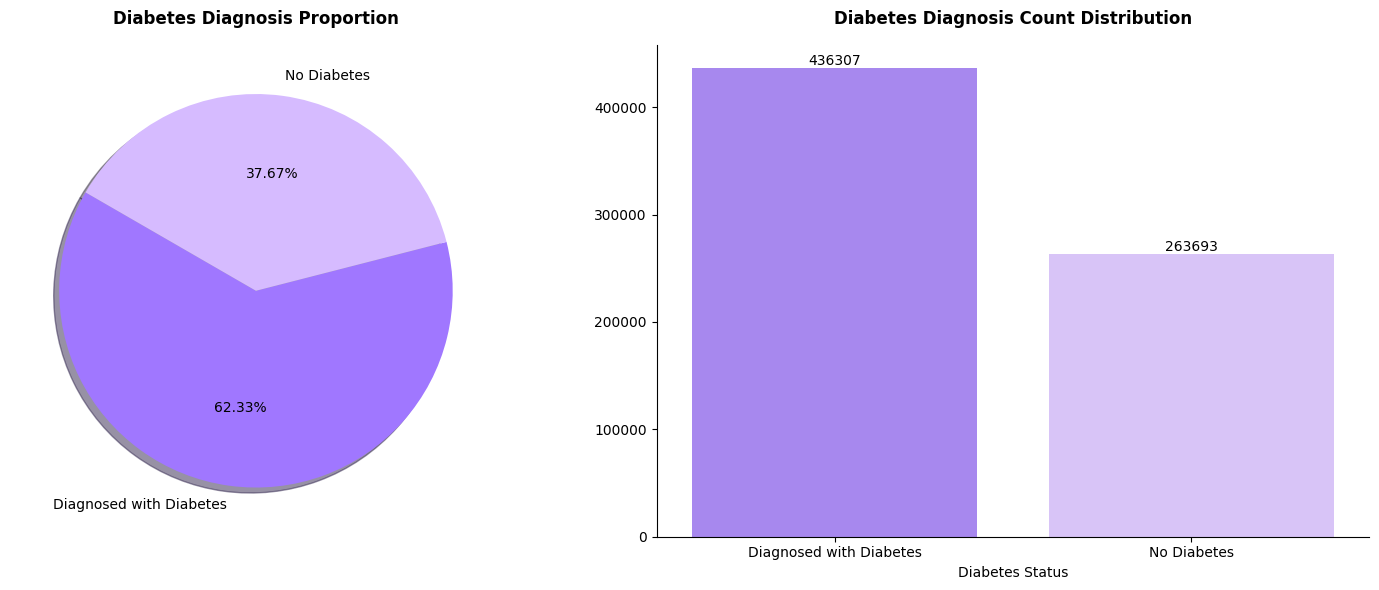

In [17]:
df_plot = df_train.copy()
df_plot["diagnosed_diabetes"] = df_plot["diagnosed_diabetes"].map({
    0: "No Diabetes",
    1: "Diagnosed with Diabetes"
})

# Prepare data and colors
status_counts = df_plot["diagnosed_diabetes"].value_counts().sort_index()
order = status_counts.index.tolist()
colors = color(n_colors=len(order), tone="custom")
palette = dict(zip(order, colors))

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Pie chart ---
ax[0].pie(status_counts, labels=order, colors=colors, autopct="%1.2f%%", startangle=150, shadow=True)
ax[0].set_title("Diabetes Diagnosis Proportion", fontweight="bold", fontsize=12, pad=15)

# --- Count plot ---
sns.countplot(data=df_plot, x="diagnosed_diabetes", order=order, palette=palette, ax=ax[1])
ax[1].set_title("Diabetes Diagnosis Count Distribution", fontweight="bold", fontsize=12, pad=15)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=10)
ax[1].set(xlabel="Diabetes Status", ylabel="")
sns.despine(ax=ax[1])

plt.tight_layout()
plt.show()

**Diabetes Diagnosis Status**
* The majority of individuals fall into the **Diagnosed with Diabetes** group — accounting for over **62%** of the dataset.

**Details:**
* **Diagnosis Rate:**
  * *Diagnosed with Diabetes*: **62.33%**
  * *No Diabetes*: **37.67%**

* **Count:**
  * *Diagnosed with Diabetes*: **436,307 individuals**
  * *No Diabetes*: **263,693 individuals**

**Interpretation:**
* The dataset exhibits a **clear class imbalance**, with the “Diagnosed with Diabetes” class being significantly more prevalent.

## Numerical Feature Distributions

In [18]:
def rgba_from_tuple(c):
    """Convert a tuple (r,g,b,a) floats (0–1) into rgba string."""
    r, g, b, a = c
    return f"rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, {a})"

def plot_numerical_features_plotly(df_train, df_test, num_features):
    n = len(num_features)

    fig = make_subplots(
        rows=n,
        cols=2,
        subplot_titles=[
            f"<b>Histogram of {num_features[i//2]}</b>" if i % 2 == 0 else f"<b>Box Plot of {num_features[i//2]}</b>"
            for i in range(n * 2)
        ],
        horizontal_spacing=0.08,
        vertical_spacing=0.015
    )

    raw_colors = color(n_colors=2, tone="diverging")
    train_color = rgba_from_tuple(raw_colors[0])
    test_color  = rgba_from_tuple(raw_colors[1])

    for idx, feature in enumerate(num_features, start=1):

        # Histogram train
        fig.add_trace(
            go.Histogram(
                x=df_train[feature],
                name="Train data",
                opacity=0.6,
                marker_color=train_color,
                nbinsx=20
            ),
            row=idx, col=1
        )

        # Histogram test
        fig.add_trace(
            go.Histogram(
                x=df_test[feature],
                name="Test data",
                opacity=0.6,
                marker_color=test_color,
                nbinsx=20
            ),
            row=idx, col=1
        )

        # Box train
        fig.add_trace(
            go.Box(
                x=df_train[feature],
                name="Train data",
                marker_color=train_color,
                orientation="h"
            ),
            row=idx, col=2
        )

        # Box test
        fig.add_trace(
            go.Box(
                x=df_test[feature],
                name="Test data",
                marker_color=test_color,
                orientation="h"
            ),
            row=idx, col=2
        )
    fig.update_annotations(font=dict(family="Segoe UI", size=12, color="white"))
    fig.update_layout(
        height=350 * n,
        width=1200,
        title=dict(
            text="<b>Numerical Feature Comparison: Train vs Test<b>",
            font=dict(size=12, family="Segoe UI", color="white")
        ),
        showlegend=False,
        hovermode="x unified",
        template="plotly_dark"
    )

    # Remove gridlines for clean look
    fig.update_xaxes(showgrid=False, title_font=dict(size=12, color="white", family="Segoe UI"))
    fig.update_yaxes(showgrid=False, title_font=dict(size=12, color="white", family="Segoe UI"))
    fig.add_annotation(
        text="Created By Thuan Dao.",
        xref="paper", yref="paper",
        x=0.95, y=-0.015,
        showarrow=False,
        font=dict(size=10, color="white", family="Segoe UI")
    )

    fig.show()
# plot_numerical_features_plotly(df_train = df_train, df_test = df_test, num_features=num_features)
# Due to the extremely large output generated by this cell, the notebook exceeded Kaggle’s IOPub output limits and triggered a timeout.
# To prevent this issue, the visualization has been simplified (or switched to a lighter rendering method) to reduce output size and ensure smooth execution.

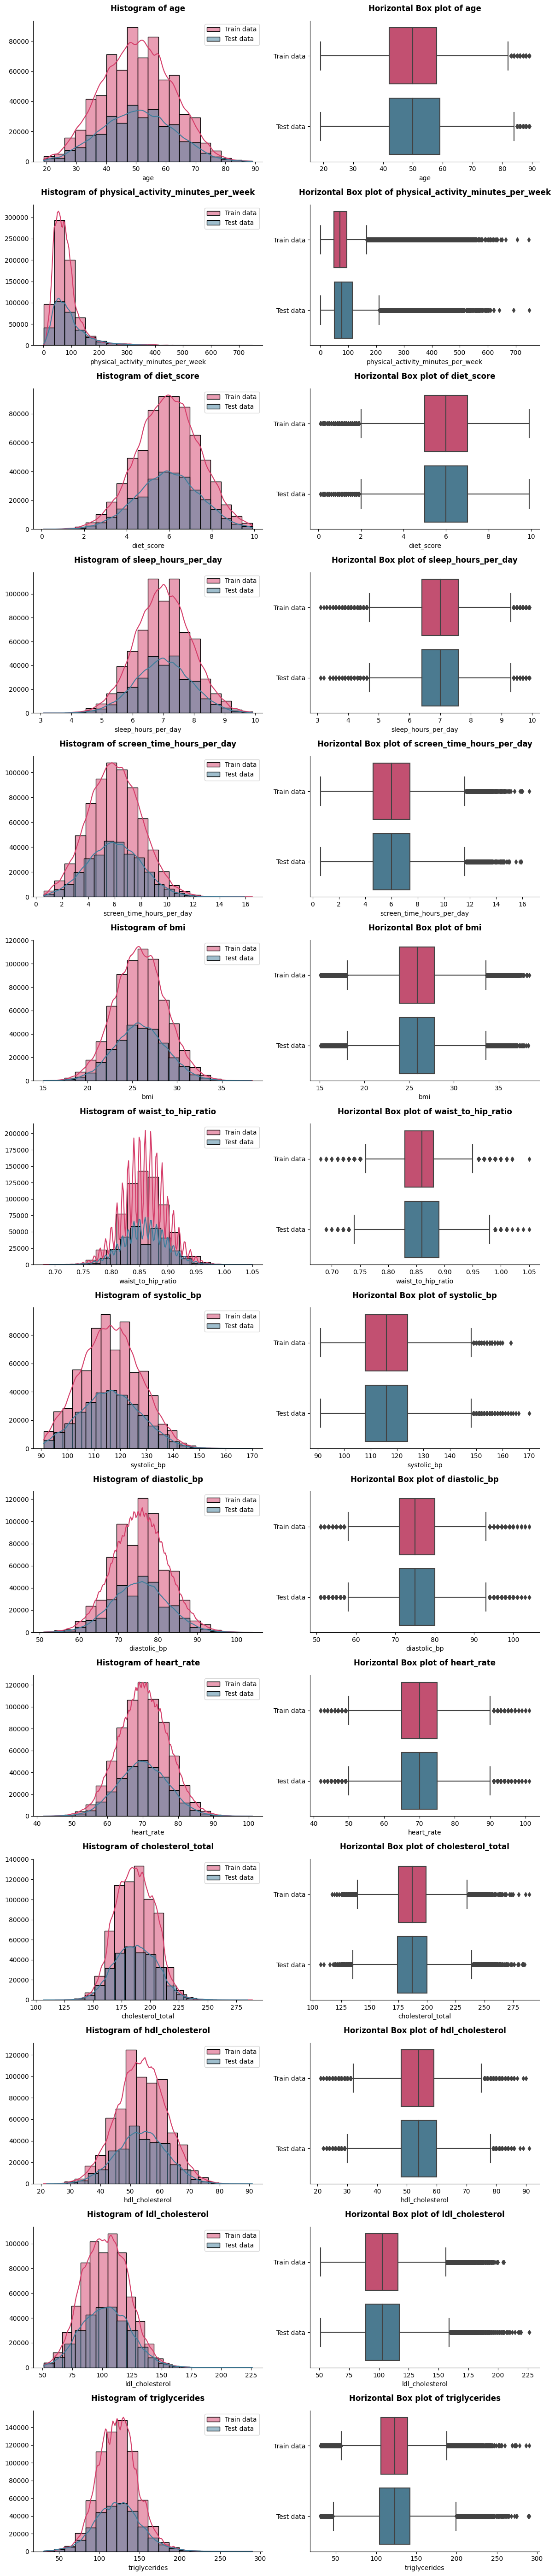

In [19]:
def plot_numerical_features(df_train, df_test, num_features):
    colors = color(n_colors=2, tone="diverging")
    n = len(num_features)

    fig, ax = plt.subplots(n, 2, figsize=(12, n * 4))
    ax = np.array(ax).reshape(n, 2)

    for i, feature in enumerate(num_features):
        sns.histplot(data=df_train[feature], color=colors[0], bins=20, kde=True, ax=ax[i, 0], label="Train data")
        sns.histplot(data=df_test[feature], color=colors[1], bins=20, kde=True, ax=ax[i, 0], label="Test data")
        ax[i, 0].set_title(f"Histogram of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 0].legend()
        ax[i, 0].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 0])

        df_plot = pd.concat([
            pd.DataFrame({"Dataset": "Train data", feature: df_train[feature]}),
            pd.DataFrame({"Dataset": "Test data", feature: df_test[feature]})
        ]).reset_index(drop=True)

        sns.boxplot(data=df_plot, x=feature, y="Dataset", palette=colors, orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 1].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 1])

    plt.tight_layout()
    plt.show()
plot_numerical_features(df_train = df_train, df_test = df_test, num_features=num_features)

In [20]:
def check_skewness(data, dataset_name, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    else:
        pass

    print(f"\n[i] Skewness for {dataset_name}...")
    print("-"*80)
    print(f"{'Feature':<40} | {'Skewness':<9} | {'Remark'}")
    print("-"*80)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<40} | {skew:>+9.4f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<40} | {skew:>+9.4f} | {remark}")
    print("-"*80)
    return skew_feature, skew_df

skew_feature_train, skew_train_df = check_skewness(df_train, "Train Data")
skew_feature_test, skew_test_df = check_skewness(df_test, "Test Data")


[i] Skewness for Train Data...
--------------------------------------------------------------------------------
Feature                                  | Skewness  | Remark
--------------------------------------------------------------------------------
physical_activity_minutes_per_week       |   +2.8142 | Highly skewed
triglycerides                            |   +0.1924 | Approximately symmetric
ldl_cholesterol                          |   +0.1323 | Approximately symmetric
screen_time_hours_per_day                |   +0.1141 | Approximately symmetric
systolic_bp                              |   +0.0972 | Approximately symmetric
diet_score                               |   -0.0630 | Approximately symmetric
cholesterol_total                        |   +0.0611 | Approximately symmetric
waist_to_hip_ratio                       |   +0.0377 | Approximately symmetric
bmi                                      |   +0.0321 | Approximately symmetric
hdl_cholesterol                          | 

**Insight**

* **Distributions are highly consistent across Train, Test datasets**, with no visible shifts or irregularities.
* **Histograms** show mostly **uniform or mildly oscillating patterns**, indicating stable value ranges without strong peaks.
* **Boxplots** confirm that the **median and interquartile ranges align closely** among all datasets — no apparent outliers.
* `physical_activity_minutes_per_week` is slightly **right-skewed**, meaning **log transformation or power transformation** should be applied to highly skewed features to improve **normality and model performance**.

## Correlation Analysis of Numerical Features

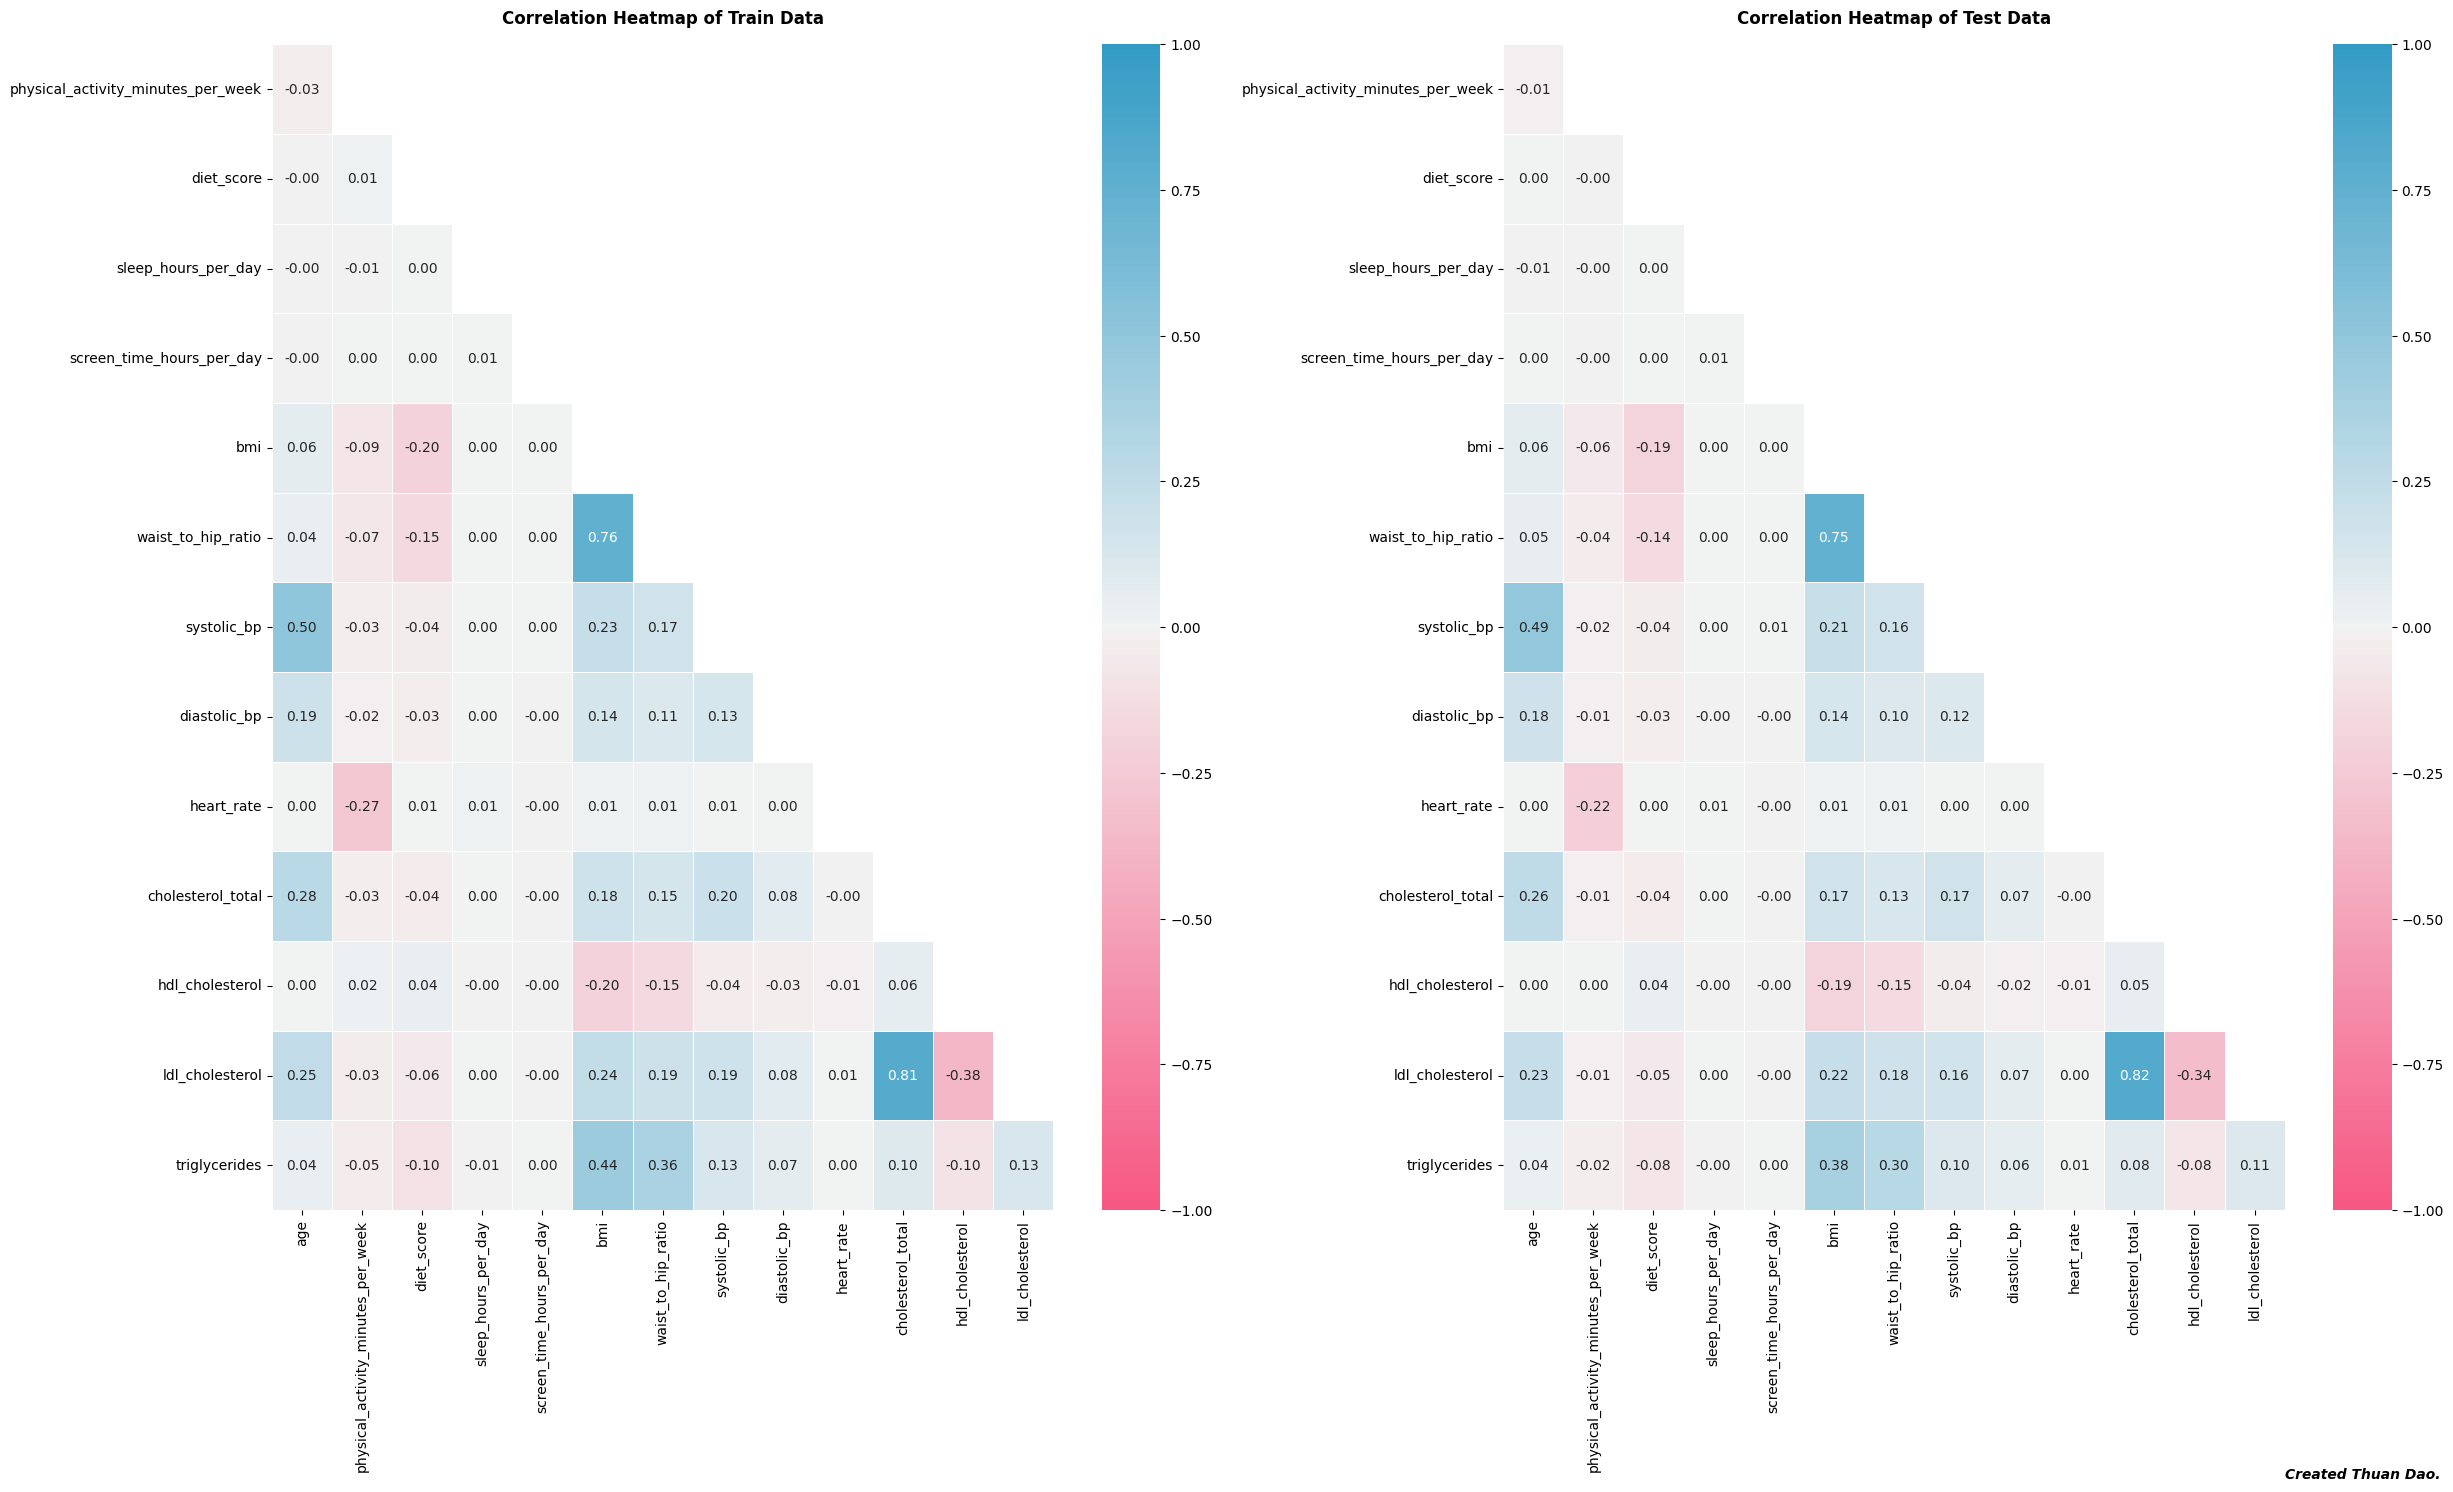

In [21]:
def plot_correlation(df_train, df_test, train_name="Train Data", test_name="Test Data", figsize=(25, 15)):
    corr_train = df_train.corr(numeric_only=True)
    corr_test = df_test.corr(numeric_only=True)

    mask_train = np.triu(np.ones_like(corr_train, dtype=bool))
    adjusted_mask_train = mask_train[1:, :-1]
    adjusted_cereal_corr_train = corr_train.iloc[1:, :-1]

    mask_test = np.triu(np.ones_like(corr_test, dtype=bool))
    adjusted_mask_test = mask_test[1:, :-1]
    adjusted_cereal_corr_test = corr_test.iloc[1:, :-1]

    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    fig, ax = plt.subplots(1, 2, figsize=figsize)

    sns.heatmap(data=adjusted_cereal_corr_train, mask=adjusted_mask_train,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[0])
    ax[0].set_title(f"Correlation Heatmap of {train_name}", fontsize=12, weight="bold", loc="center", pad=15)

    sns.heatmap(data=adjusted_cereal_corr_test, mask=adjusted_mask_test,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[1])
    ax[1].set_title(f"Correlation Heatmap of {test_name}", fontsize=12, weight="bold", loc="center", pad=15)
    plt.text(13,16, "Created Thuan Dao.", fontsize=10, color="black", fontweight="bold", style="italic")
    plt.tight_layout()
    plt.show()

plot_correlation(df_train=df_train.drop(columns="diagnosed_diabetes", axis=1),
                 df_test=df_test)

**Correlation Matrix of Health Indicators (Excluding Target Column)**

**Overview**

* The selected numerical health indicators show **mostly weak correlations**, indicating **minimal multicollinearity** concerns for modeling.
* The Train và Test datasets share **consistent correlation patterns**, confirming stable synthetic data generation.

**Key Highlights**

**Waist-to-hip ratio ↔ LDL cholesterol**

* Strong positive correlation (**~0.75–0.76**)
  → Individuals with a **higher waist-to-hip ratio** tend to have **higher LDL cholesterol**, a well-known cardiovascular risk pattern.

**LDL cholesterol ↔ Total cholesterol**

* Very strong positive correlation (**~0.81–0.82**)
  → Expected biologically, since LDL is a major component of total cholesterol.

**Age ↔ Systolic blood pressure**

* Moderate positive correlation (**~0.49–0.50**)
  → Systolic pressure tends to **increase with age**, reflecting normal physiological trends.

**Systolic BP ↔ Diastolic BP**

* Mild correlation (**~0.21–0.23**)
  → These two blood pressure components relate but are not strongly linear.

**Other variable pairs**

* Most correlation coefficients are **near zero**, meaning:

  * No strong linear relationships.
  * Variables remain **largely independent**, which is beneficial for most ML algorithms.

**Summary**

* No multicollinearity concerns — safe to use these features together in modeling.
* Strong correlations appear only among **expected physiological relationships**.
* Excluding the categorical target from the correlation matrix is the correct approach.

## Categorical Feature Distributions

In [22]:
def plot_categorical_distribution_across_datasets(
    df_train: pd.DataFrame = df_train,
    df_test: pd.DataFrame = df_test,
    feature="gender"
):
    # --- Summarize categorical feature in training set ---
    train_summary = (
        df_train[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Train_Count")
    )

    # Calculate percentage distribution in training data
    train_summary["Train_%"] = round((train_summary["Train_Count"] / train_summary["Train_Count"].sum() * 100), 2)

    # --- Summarize categorical feature in test set ---
    test_summary = (
        df_test[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Test_Count")
    )

    # Calculate percentage distribution in test data
    test_summary["Test_%"] = round((test_summary["Test_Count"] / test_summary["Test_Count"].sum() * 100), 2)

    # --- Merge train and test summaries for comparison ---
    summary = pd.merge(train_summary, test_summary, on="Category", how="inner")

    # Ensure Category column is of string type before handling missing values
    summary["Category"] = summary["Category"].astype(str)

    # Fill missing values only for numeric columns
    numeric_cols = ["Train_Count", "Train_%", "Test_Count", "Test_%"]
    summary[numeric_cols] = summary[numeric_cols].fillna(0)

    # Convert summary table to HTML for better visualization in notebook
    html = summary.to_html(
        index=False,
        justify="center",
        classes="table table-striped table-hover",
    )

    # Display formatted HTML table with title
    display(HTML(f"[✓] Categorical Feature Distribution: <b>{feature}</b>" + html))
    print("*" * 80)


# ----- Run the function for all categorical features -----
cat_features = ["alcohol_consumption_per_week", "gender", "ethnicity", "education_level", "income_level", "smoking_status", 
                "employment_status", "family_history_diabetes", "hypertension_history", "cardiovascular_history"]

for feature in cat_features:
    plot_categorical_distribution_across_datasets(df_train, df_test, feature)

Category,Train_Count,Train_%,Test_Count,Test_%
2,246592,35.23,104723,34.91
1,246311,35.19,104820,34.94
3,137565,19.65,59091,19.70
4,52973,7.57,23407,7.80
5,13322,1.90,6305,2.10
6,2728,0.39,1401,0.47
7,447,0.06,215,0.07
8,59,0.01,37,0.01
9,3,0.00,1,0.00


********************************************************************************


Category,Train_Count,Train_%,Test_Count,Test_%
Female,363237,51.89,154098,51.37
Male,333085,47.58,144102,48.03
Other,3678,0.53,1800,0.60


********************************************************************************


Category,Train_Count,Train_%,Test_Count,Test_%
White,386153,55.16,168375,56.12
Hispanic,129984,18.57,53534,17.84
Black,106301,15.19,45203,15.07
Asian,60120,8.59,25077,8.36
Other,17442,2.49,7811,2.60


...

********************************************************************************


Category,Train_Count,Train_%,Test_Count,Test_%
0,572607,81.8,244677,81.56
1,127393,18.2,55323,18.44


********************************************************************************


Category,Train_Count,Train_%,Test_Count,Test_%
0,678773,96.97,290067,96.69
1,21227,3.03,9933,3.31


********************************************************************************


**Overall Consistency in Categorical Feature Distributions**

* The categorical variables across the **Train and Test datasets** show a **high degree of consistency**.
* There are **no noticeable signs of distributional shift** or **sampling bias** across datasets.

## Bivariate Analysis

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,51.820056,52.000000,11.593097
1,No Diabetes,263693,47.943484,48.000000,11.352802



[i] Checking normality of feature 'age' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


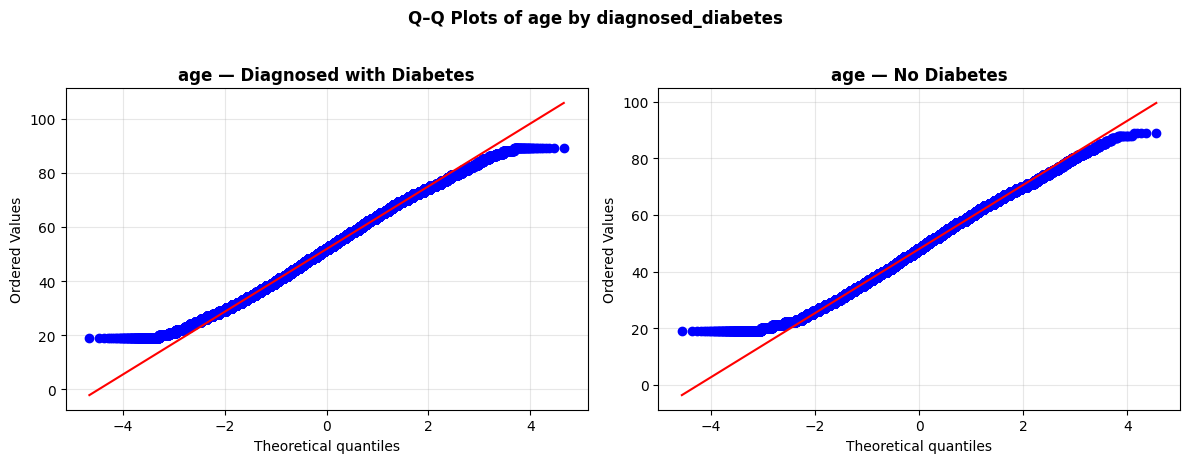

,Feature,Group,Skewness,Kurtosis,Remark
0,age,Diagnosed with Diabetes,0.0090,-0.4027,"Approximately symmetric, Normal tails"
1,age,No Diabetes,0.0230,-0.3999,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,119.4794
1,p-value,0.000000
2,Max/Min Variance Ratio,1.04



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'age' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 137.331
[i] p-value: 0.000000
[i] Cohen's d: 0.338
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: medium effect (|d| = 0.338)


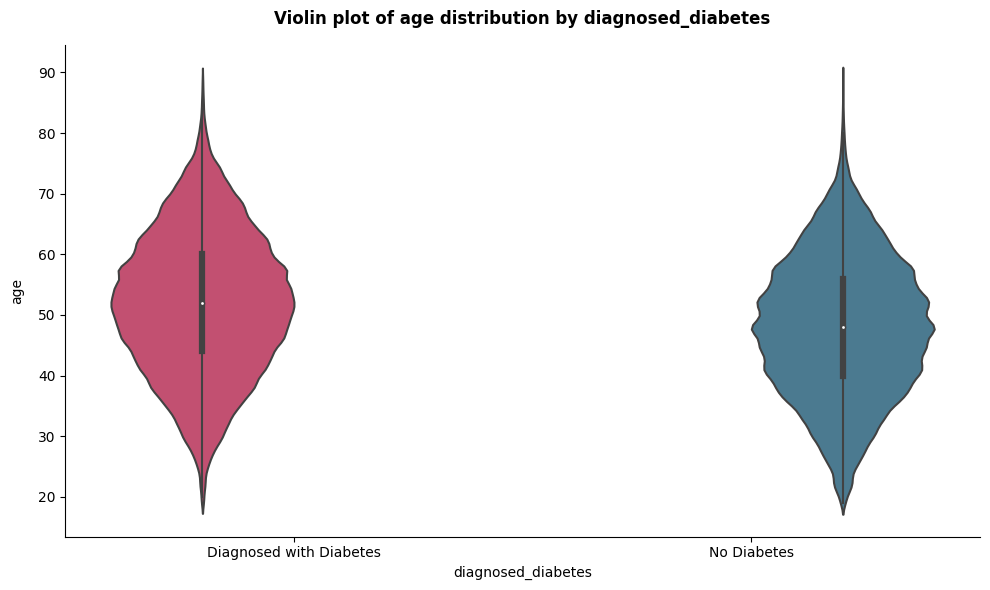

,diagnosed_diabetes,Count,Mean,Median,Std
0,No Diabetes,263693,91.411873,79.000000,60.302019
1,Diagnosed with Diabetes,436307,73.473245,65.000000,43.428555



[i] Checking normality of feature 'physical_activity_minutes_per_week' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


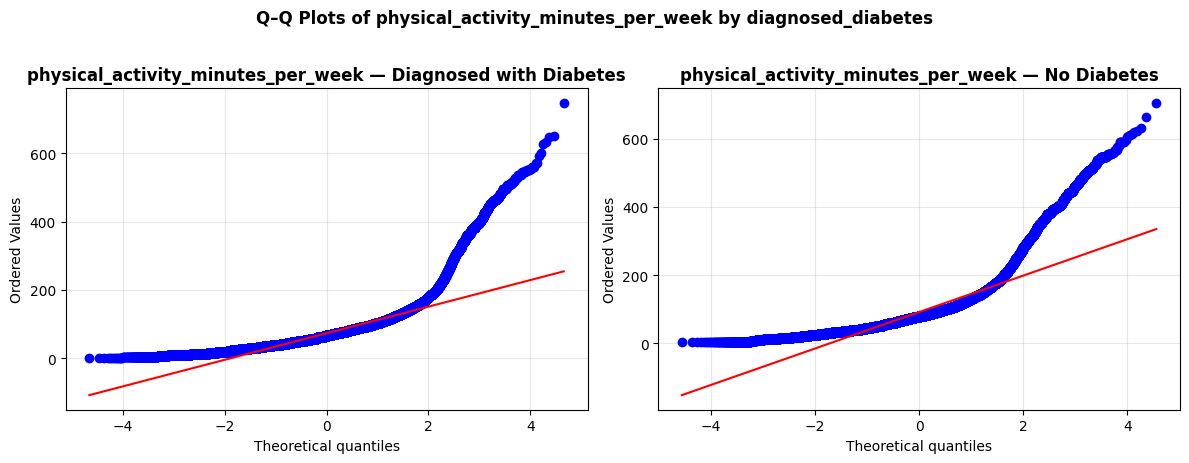

,Feature,Group,Skewness,Kurtosis,Remark
0,physical_activity_minutes_per_week,Diagnosed with Diabetes,2.8946,16.4526,"Highly skewed, Heavy/light tails"
1,physical_activity_minutes_per_week,No Diabetes,2.5105,9.3458,"Highly skewed, Heavy/light tails"


[!] At least one group deviates from normality.
[i] Non-normal distribution detected → Consider Kruskal–Wallis or Mann–Whitney U test.

[i] Running Mann–Whitney U Test: 'physical_activity_minutes_per_week' by 'diagnosed_diabetes'...
[i] U statistic: 46357997380.5
[i] p-value    : 0.000000

[✓] Significant difference detected between the two groups (Reject H0).
[i] Median of group 'Diagnosed with Diabetes': 65.0000
[i] Median of group 'No Diabetes': 79.0000
[i] Interpretation: Group 'No Diabetes' has a higher median 'physical_activity_minutes_per_week'.


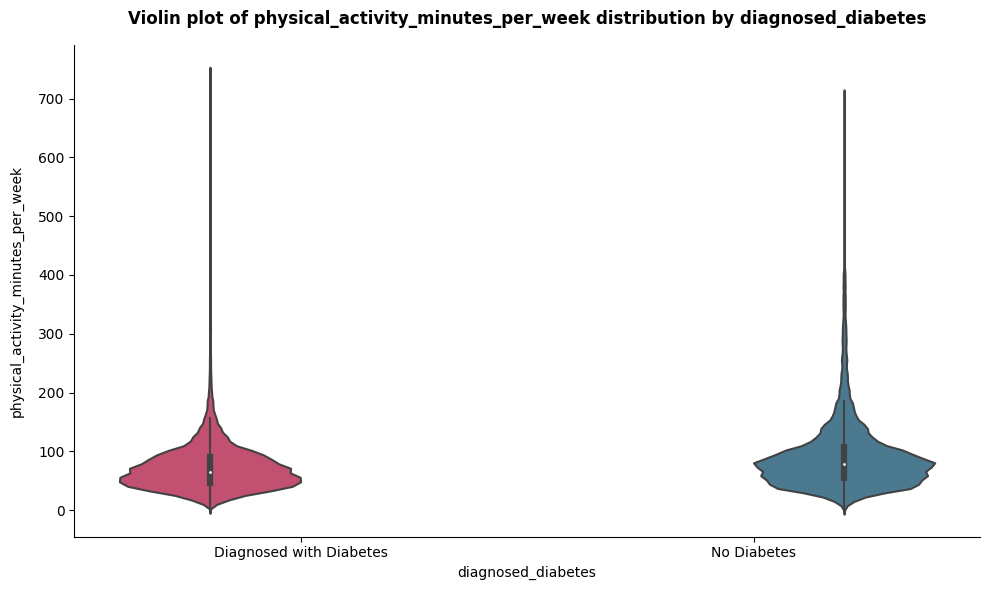

,diagnosed_diabetes,Count,Mean,Median,Std
0,No Diabetes,263693,6.058035,6.100000,1.464877
1,Diagnosed with Diabetes,436307,5.906678,5.900000,1.459453



[i] Checking normality of feature 'diet_score' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


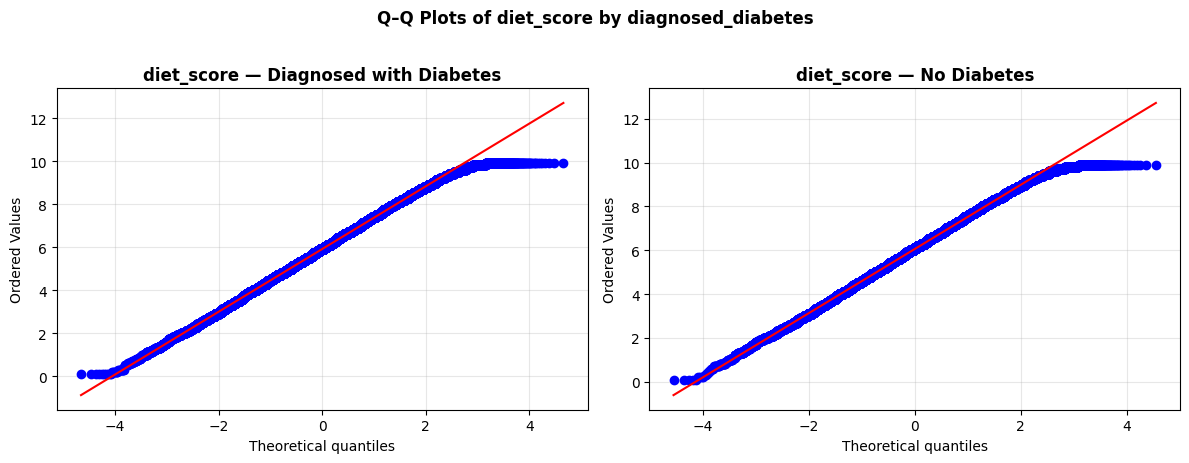

,Feature,Group,Skewness,Kurtosis,Remark
0,diet_score,Diagnosed with Diabetes,-0.0553,-0.1477,"Approximately symmetric, Normal tails"
1,diet_score,No Diabetes,-0.0777,-0.1797,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,7.7397
1,p-value,0.005402
2,Max/Min Variance Ratio,1.01



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'diet_score' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: -41.947
[i] p-value: 0.000000
[i] Cohen's d: -0.104
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.104)


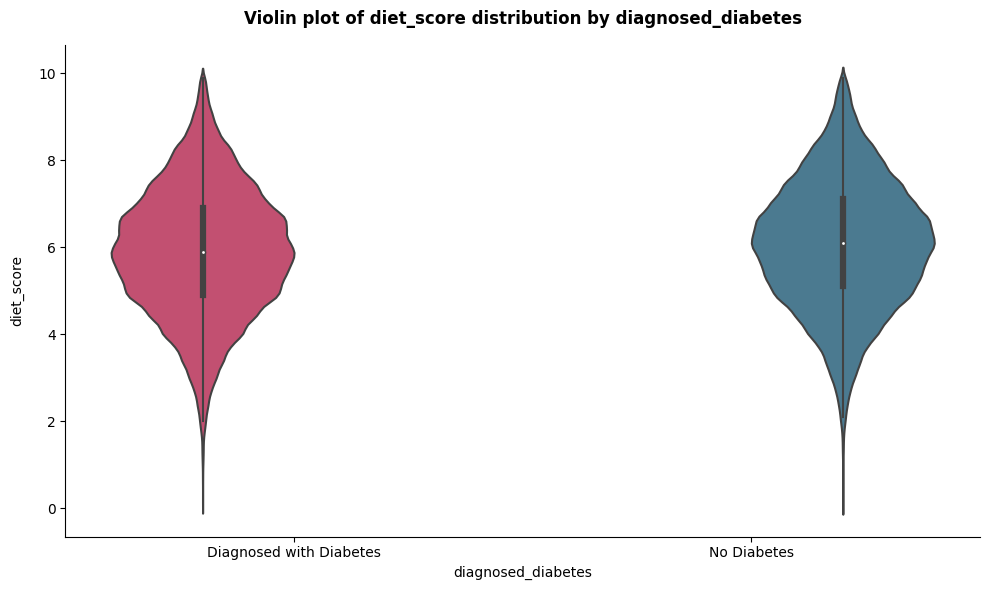

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,7.004660,7.000000,0.900570
1,No Diabetes,263693,6.998129,7.000000,0.904101



[i] Checking normality of feature 'sleep_hours_per_day' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


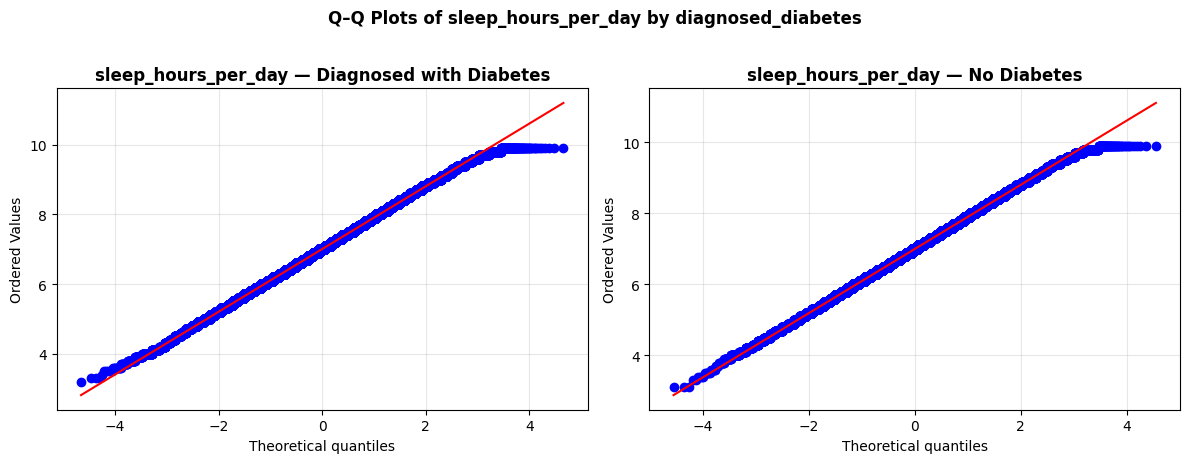

,Feature,Group,Skewness,Kurtosis,Remark
0,sleep_hours_per_day,Diagnosed with Diabetes,-0.0020,-0.0611,"Approximately symmetric, Normal tails"
1,sleep_hours_per_day,No Diabetes,0.0072,-0.0581,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,2.8506
1,p-value,0.091342
2,Max/Min Variance Ratio,1.01



[i] Interpretation:
   [✓] Variances are statistically and practically homogeneous.
   Recommendation → Use One-Way ANOVA or Independent Two-Sample T-Test.

[i] Running Independent Two-Sample T-Test: 'sleep_hours_per_day' ~ 'diagnosed_diabetes'
[i] Test Type: Student’s T-Test (equal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 2.936
[i] p-value: 0.003330
[i] Cohen's d: 0.007
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.007)


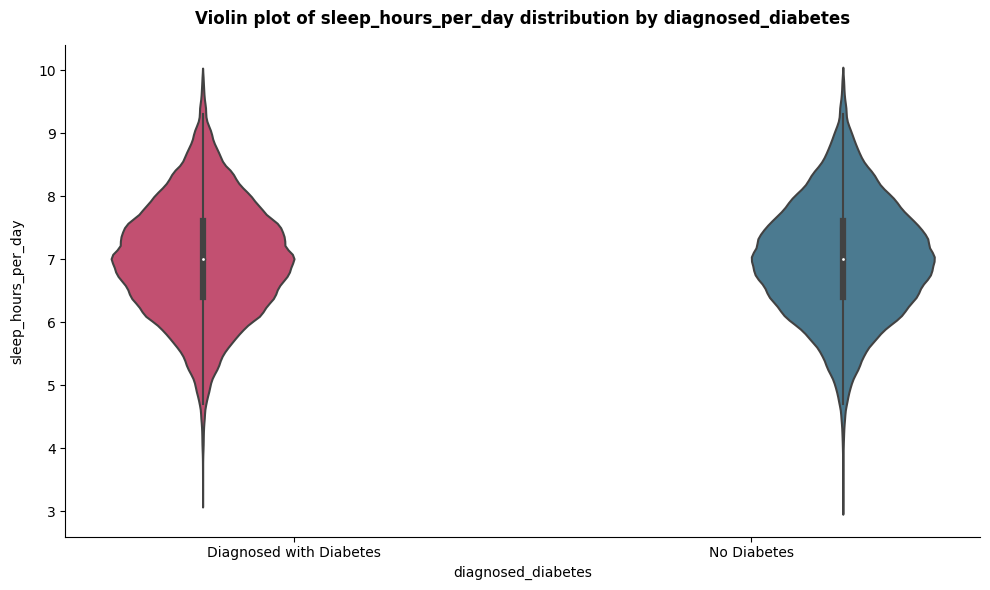

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,6.041372,6.000000,2.019437
1,No Diabetes,263693,5.965346,5.900000,2.027223



[i] Checking normality of feature 'screen_time_hours_per_day' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


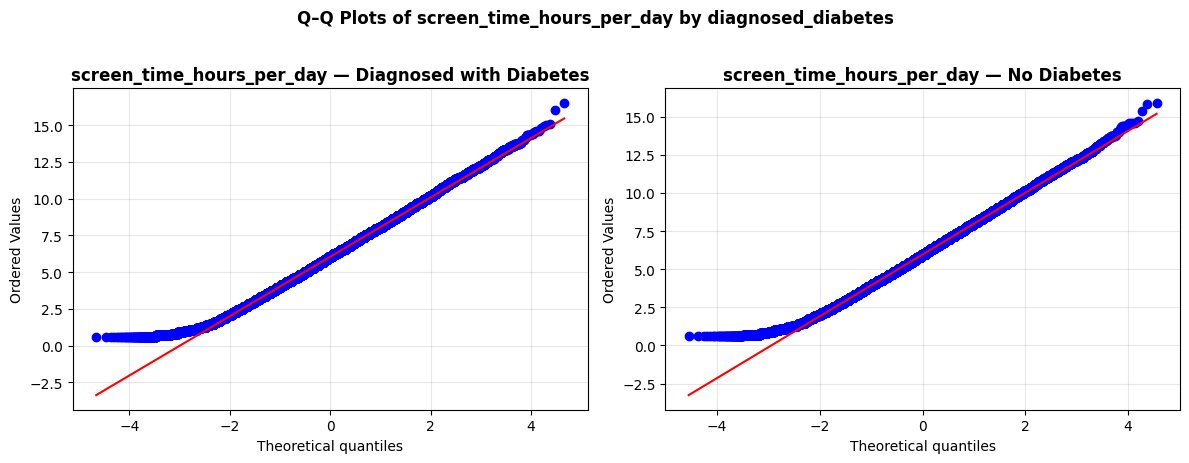

,Feature,Group,Skewness,Kurtosis,Remark
0,screen_time_hours_per_day,Diagnosed with Diabetes,0.1106,-0.1190,"Approximately symmetric, Normal tails"
1,screen_time_hours_per_day,No Diabetes,0.1206,-0.1546,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,9.6502
1,p-value,0.001893
2,Max/Min Variance Ratio,1.01



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'screen_time_hours_per_day' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 15.226
[i] p-value: 0.000000
[i] Cohen's d: 0.038
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.038)


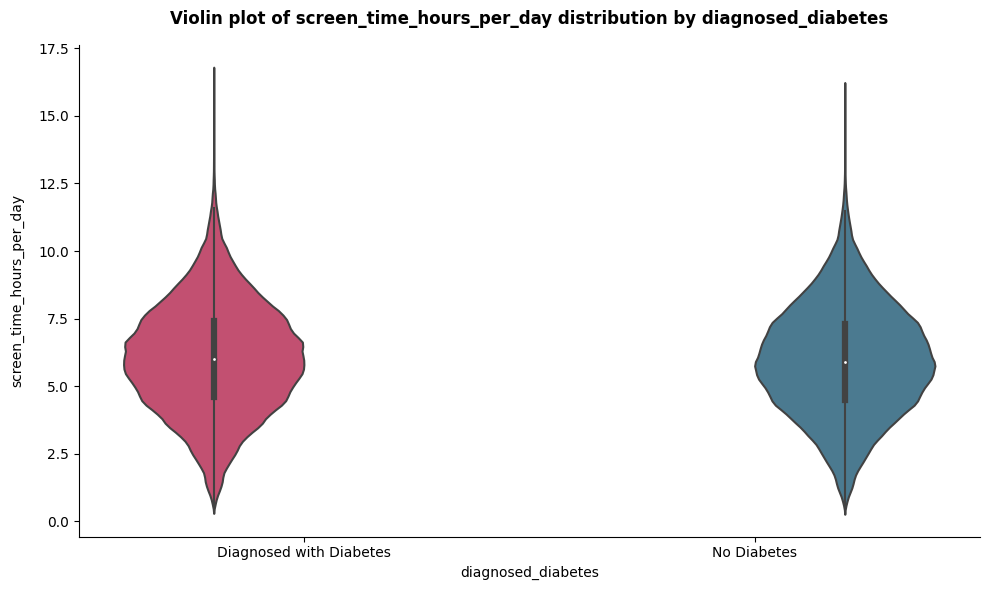

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,26.109489,26.100000,2.852350
1,No Diabetes,263693,25.486175,25.500000,2.832044



[i] Checking normality of feature 'bmi' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


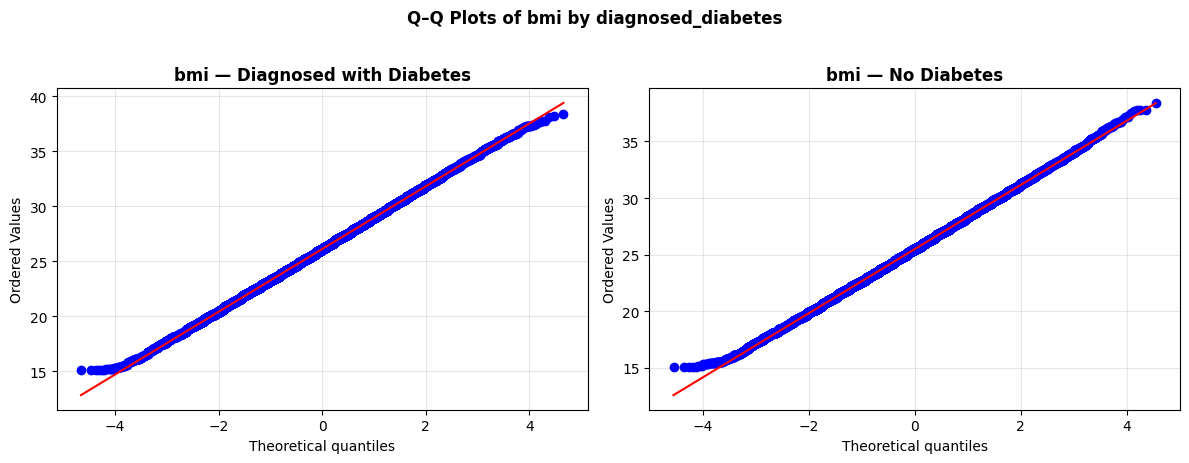

,Feature,Group,Skewness,Kurtosis,Remark
0,bmi,Diagnosed with Diabetes,0.0306,-0.0210,"Approximately symmetric, Normal tails"
1,bmi,No Diabetes,0.0319,-0.0246,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,15.9560
1,p-value,0.000065
2,Max/Min Variance Ratio,1.01



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'bmi' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 88.988
[i] p-value: 0.000000
[i] Cohen's d: 0.219
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: medium effect (|d| = 0.219)


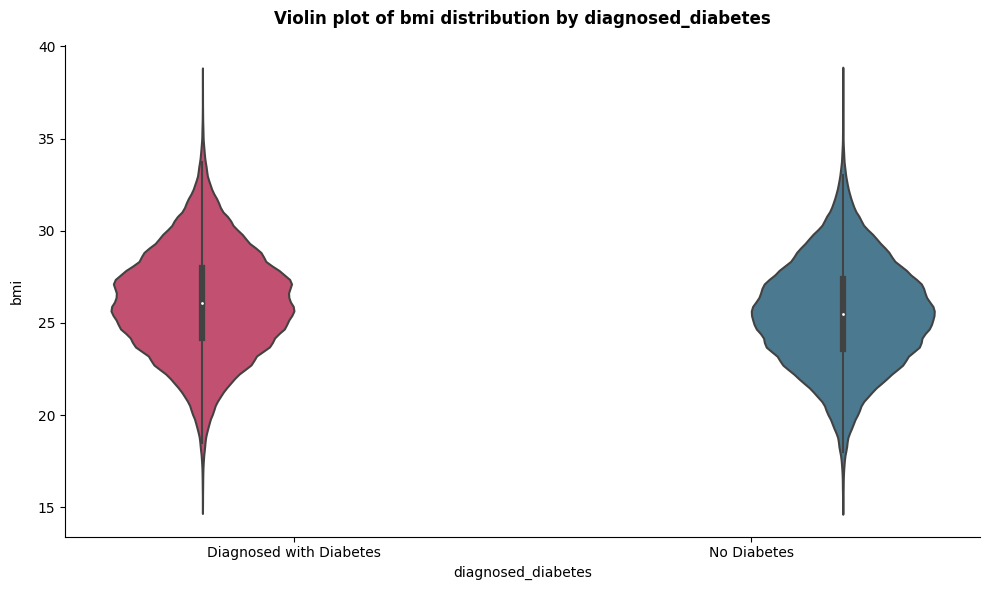

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,0.861159,0.860000,0.037819
1,No Diabetes,263693,0.854806,0.850000,0.037914



[i] Checking normality of feature 'waist_to_hip_ratio' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


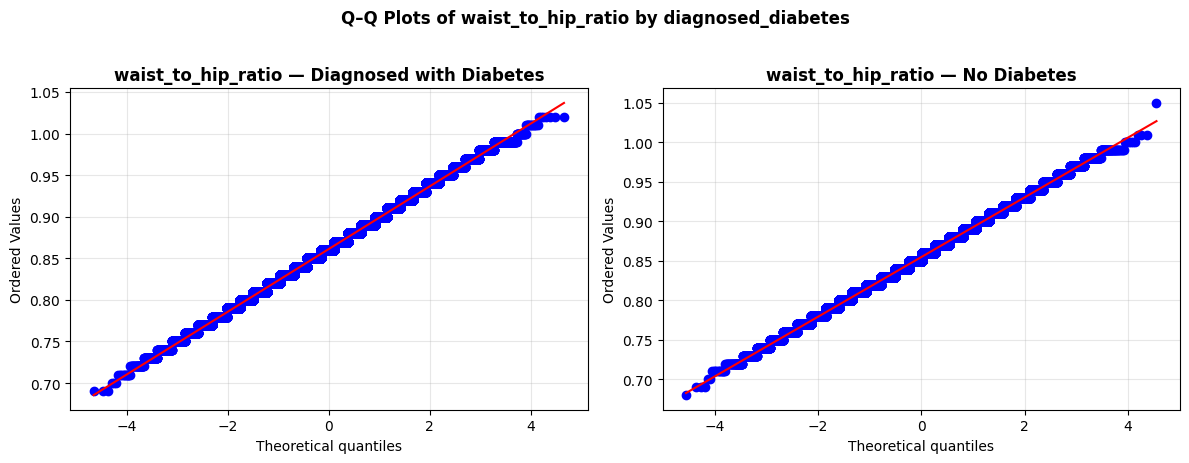

,Feature,Group,Skewness,Kurtosis,Remark
0,waist_to_hip_ratio,Diagnosed with Diabetes,0.0385,0.0214,"Approximately symmetric, Normal tails"
1,waist_to_hip_ratio,No Diabetes,0.0397,-0.0047,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,43.4959
1,p-value,0.000000
2,Max/Min Variance Ratio,1.01



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'waist_to_hip_ratio' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 67.993
[i] p-value: 0.000000
[i] Cohen's d: 0.168
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.168)


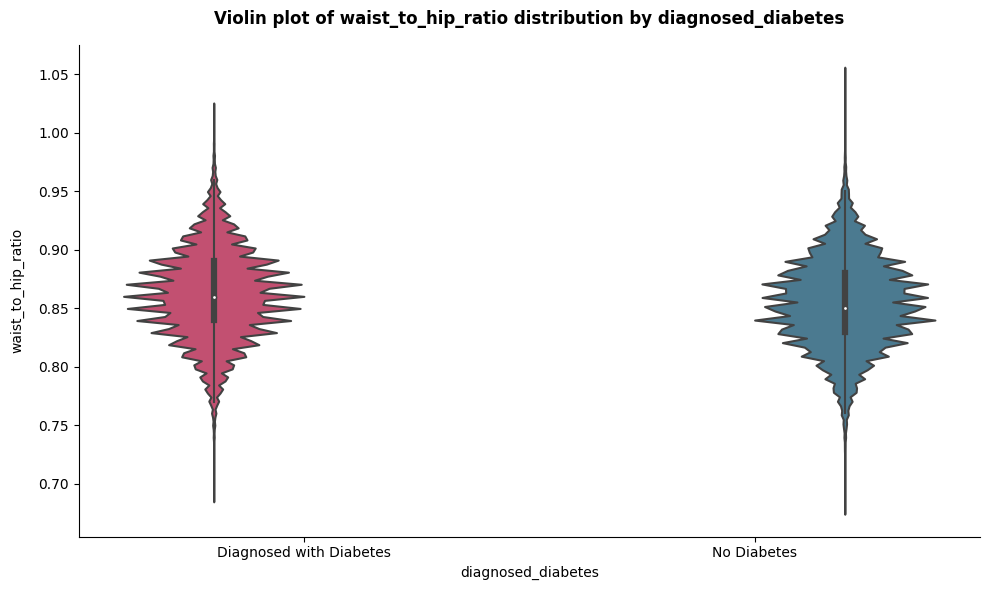

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,117.211202,117.000000,11.031119
1,No Diabetes,263693,114.776907,115.000000,10.806463



[i] Checking normality of feature 'systolic_bp' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


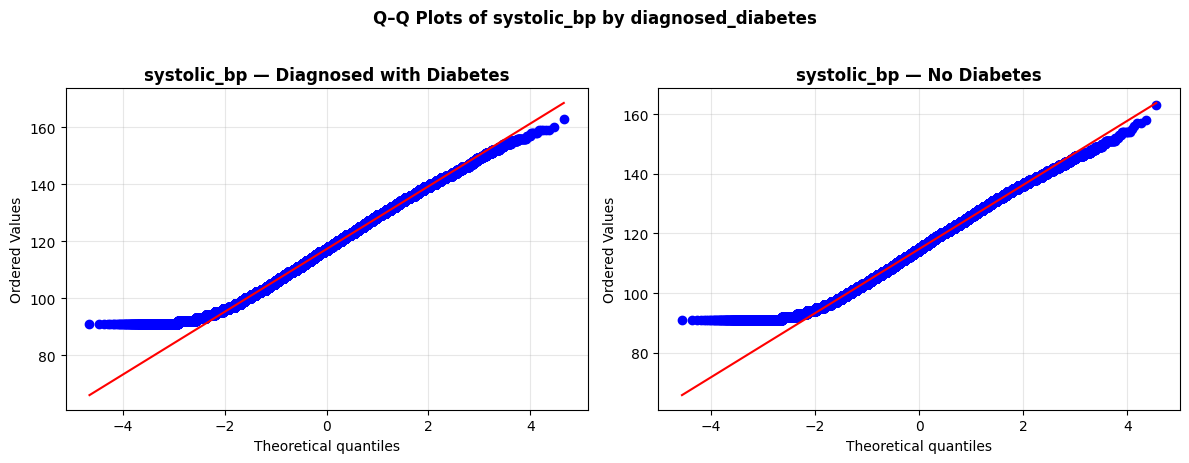

,Feature,Group,Skewness,Kurtosis,Remark
0,systolic_bp,Diagnosed with Diabetes,0.0801,-0.3703,"Approximately symmetric, Normal tails"
1,systolic_bp,No Diabetes,0.1160,-0.4448,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,71.1599
1,p-value,0.000000
2,Max/Min Variance Ratio,1.04



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'systolic_bp' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 90.610
[i] p-value: 0.000000
[i] Cohen's d: 0.223
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: medium effect (|d| = 0.223)


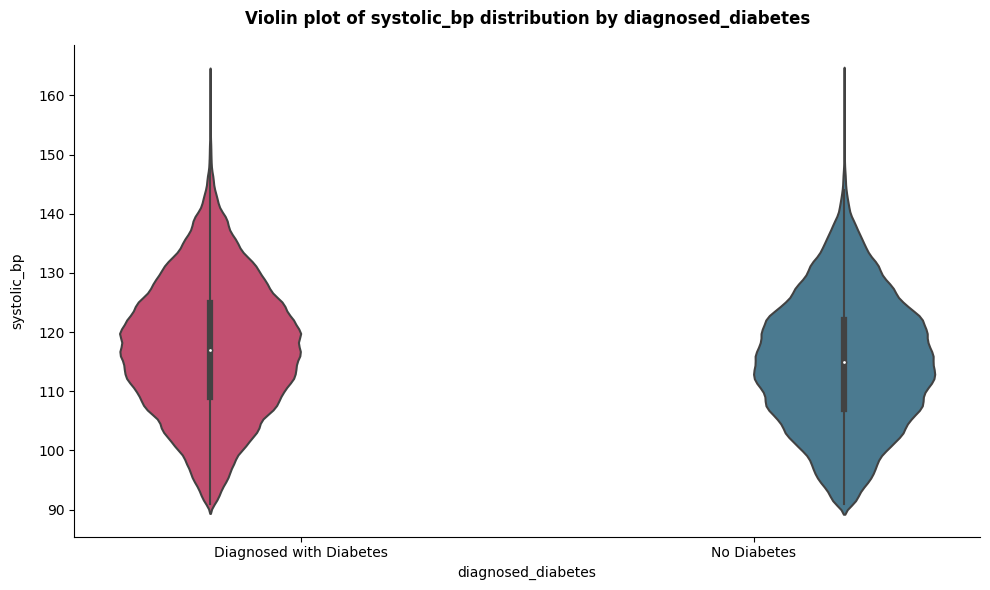

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,75.633393,76.000000,6.820969
1,No Diabetes,263693,75.122464,75.000000,6.821817



[i] Checking normality of feature 'diastolic_bp' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


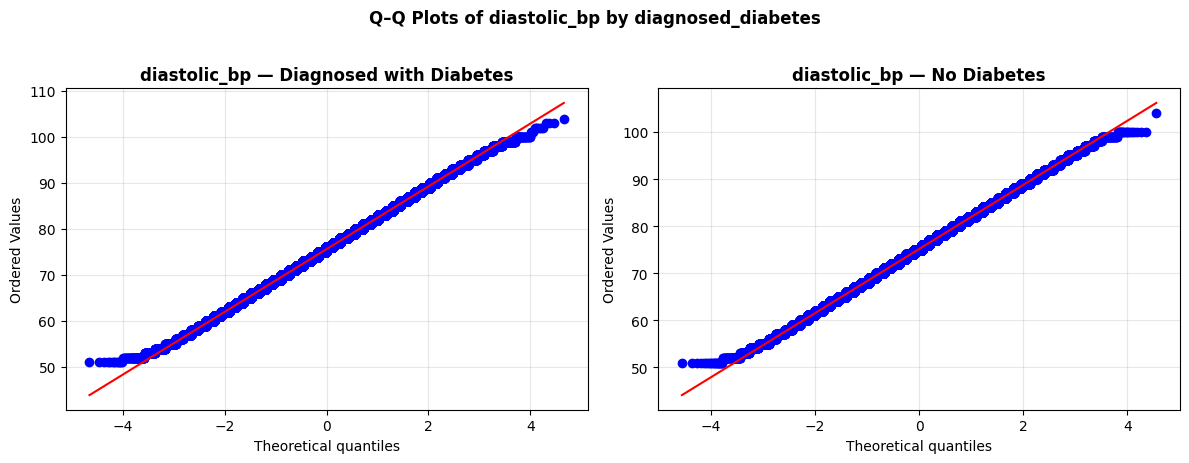

,Feature,Group,Skewness,Kurtosis,Remark
0,diastolic_bp,Diagnosed with Diabetes,0.0025,-0.0343,"Approximately symmetric, Normal tails"
1,diastolic_bp,No Diabetes,-0.0077,-0.0444,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,0.3793
1,p-value,0.537955
2,Max/Min Variance Ratio,1.00



[i] Interpretation:
   [✓] Variances are statistically and practically homogeneous.
   Recommendation → Use One-Way ANOVA or Independent Two-Sample T-Test.

[i] Running Independent Two-Sample T-Test: 'diastolic_bp' ~ 'diagnosed_diabetes'
[i] Test Type: Student’s T-Test (equal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 30.366
[i] p-value: 0.000000
[i] Cohen's d: 0.075
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.075)


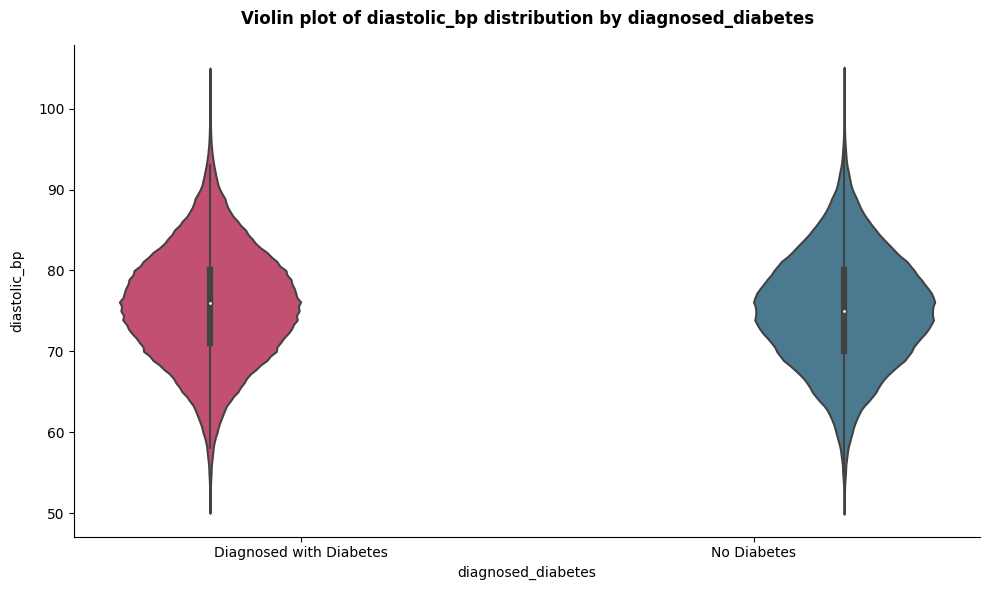

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,70.296482,70.000000,6.917040
1,No Diabetes,263693,69.954747,70.000000,6.969243



[i] Checking normality of feature 'heart_rate' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


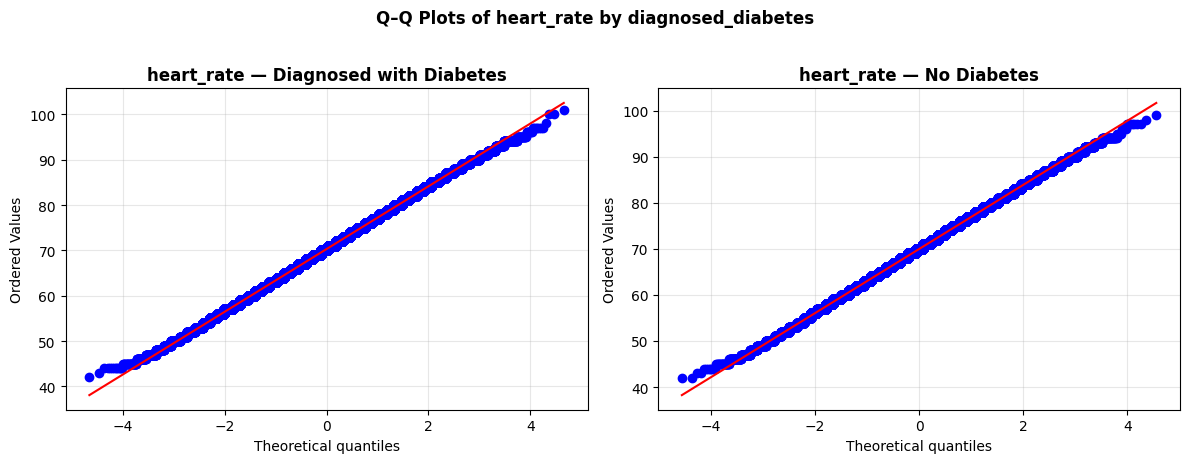

,Feature,Group,Skewness,Kurtosis,Remark
0,heart_rate,Diagnosed with Diabetes,-0.0057,-0.0572,"Approximately symmetric, Normal tails"
1,heart_rate,No Diabetes,-0.0222,-0.0700,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,13.9183
1,p-value,0.000191
2,Max/Min Variance Ratio,1.02



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'heart_rate' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 19.935
[i] p-value: 0.000000
[i] Cohen's d: 0.049
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.049)


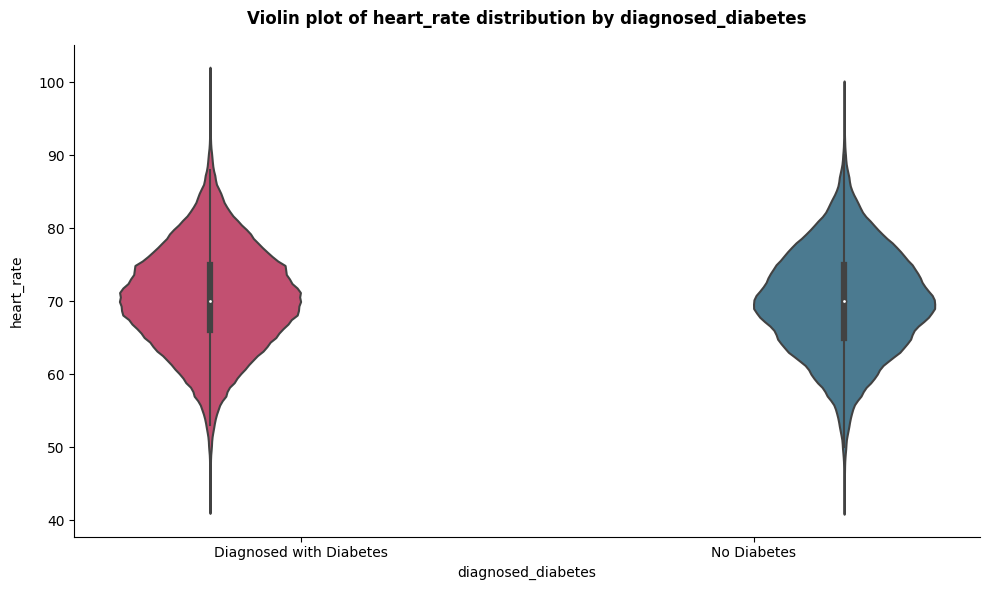

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,187.964860,188.000000,16.749371
1,No Diabetes,263693,184.922531,185.000000,16.526515



[i] Checking normality of feature 'cholesterol_total' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


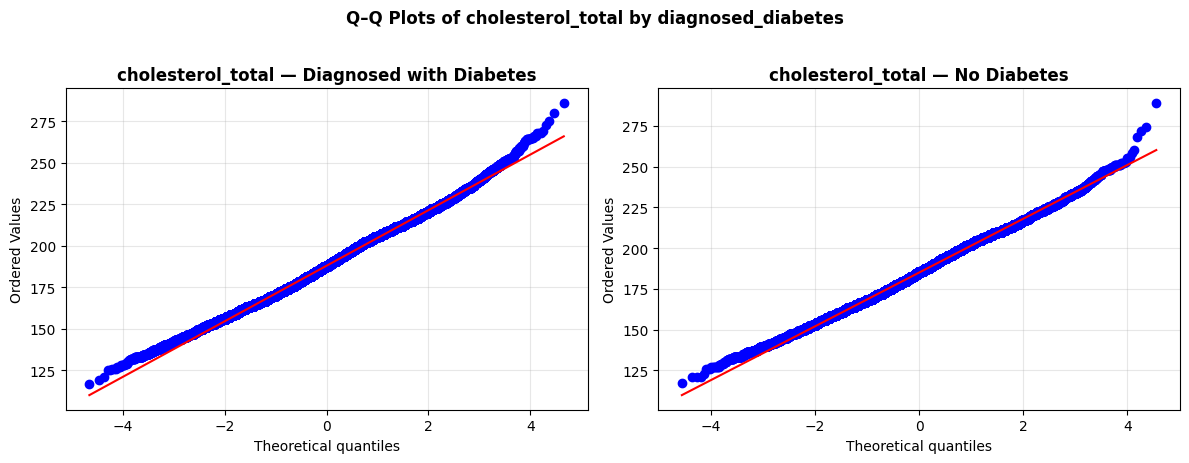

,Feature,Group,Skewness,Kurtosis,Remark
0,cholesterol_total,Diagnosed with Diabetes,0.0674,-0.2681,"Approximately symmetric, Normal tails"
1,cholesterol_total,No Diabetes,0.0438,-0.2869,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,68.6496
1,p-value,0.000000
2,Max/Min Variance Ratio,1.03



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'cholesterol_total' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 74.253
[i] p-value: 0.000000
[i] Cohen's d: 0.183
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.183)


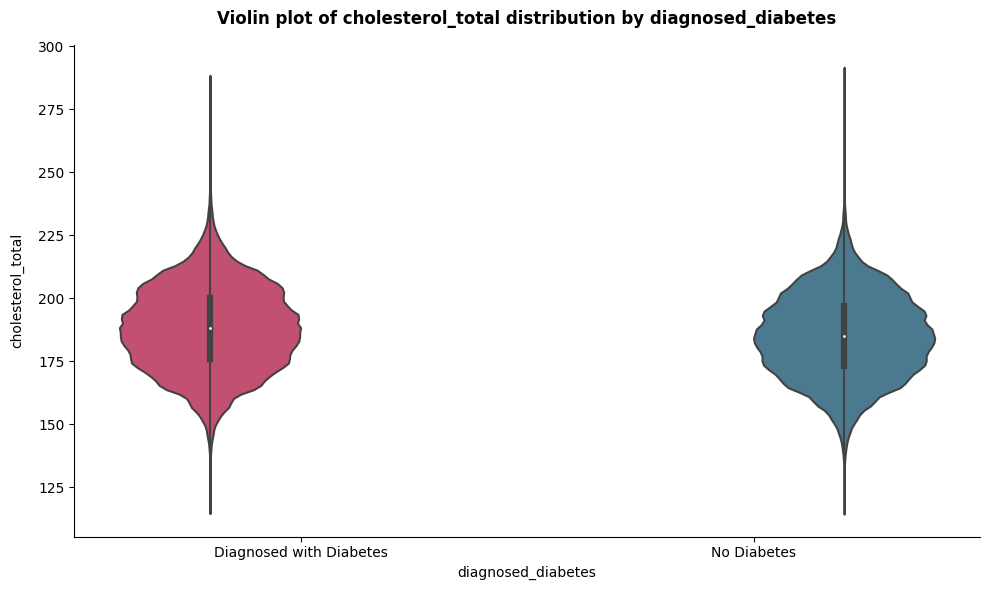

,diagnosed_diabetes,Count,Mean,Median,Std
0,No Diabetes,263693,54.389237,54.000000,8.162087
1,Diagnosed with Diabetes,436307,53.481125,54.000000,8.310381



[i] Checking normality of feature 'hdl_cholesterol' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


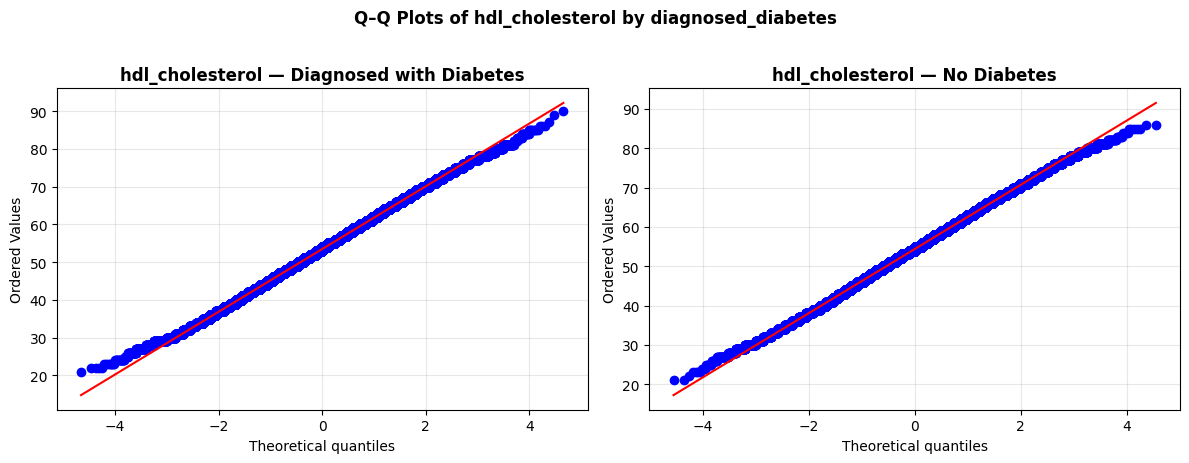

,Feature,Group,Skewness,Kurtosis,Remark
0,hdl_cholesterol,Diagnosed with Diabetes,-0.0118,-0.1151,"Approximately symmetric, Normal tails"
1,hdl_cholesterol,No Diabetes,-0.0305,-0.0917,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,121.7914
1,p-value,0.000000
2,Max/Min Variance Ratio,1.04



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'hdl_cholesterol' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: -44.798
[i] p-value: 0.000000
[i] Cohen's d: -0.110
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.110)


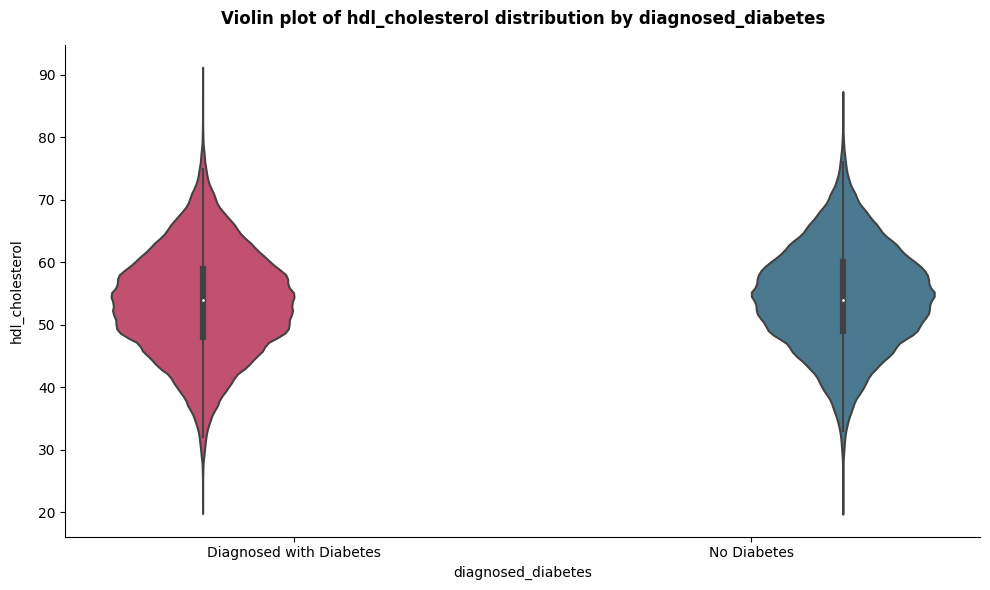

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,104.425668,104.000000,18.994343
1,No Diabetes,263693,100.391167,100.000000,18.800903



[i] Checking normality of feature 'ldl_cholesterol' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


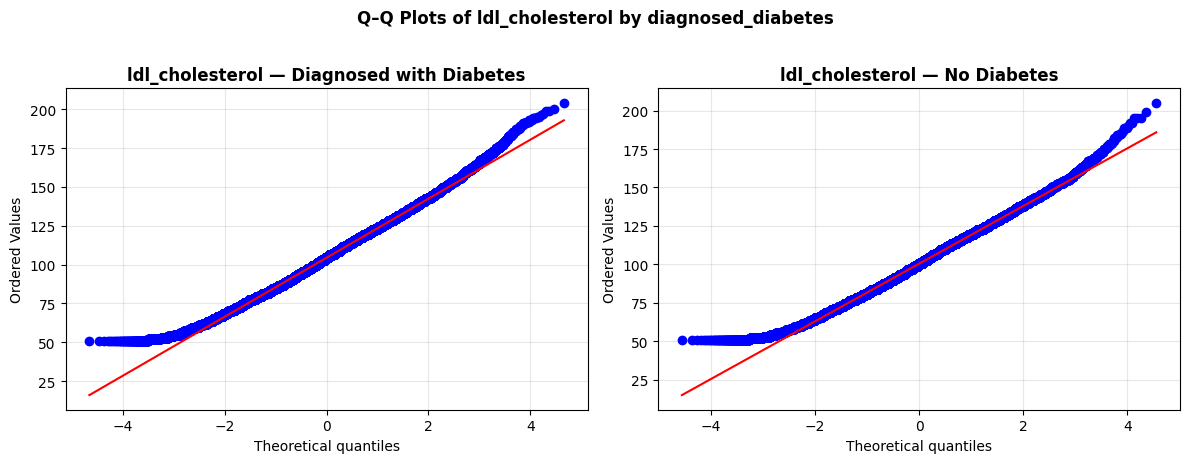

,Feature,Group,Skewness,Kurtosis,Remark
0,ldl_cholesterol,Diagnosed with Diabetes,0.1350,-0.1118,"Approximately symmetric, Normal tails"
1,ldl_cholesterol,No Diabetes,0.1266,-0.1810,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,13.6511
1,p-value,0.000220
2,Max/Min Variance Ratio,1.02



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'ldl_cholesterol' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 86.661
[i] p-value: 0.000000
[i] Cohen's d: 0.213
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: medium effect (|d| = 0.213)


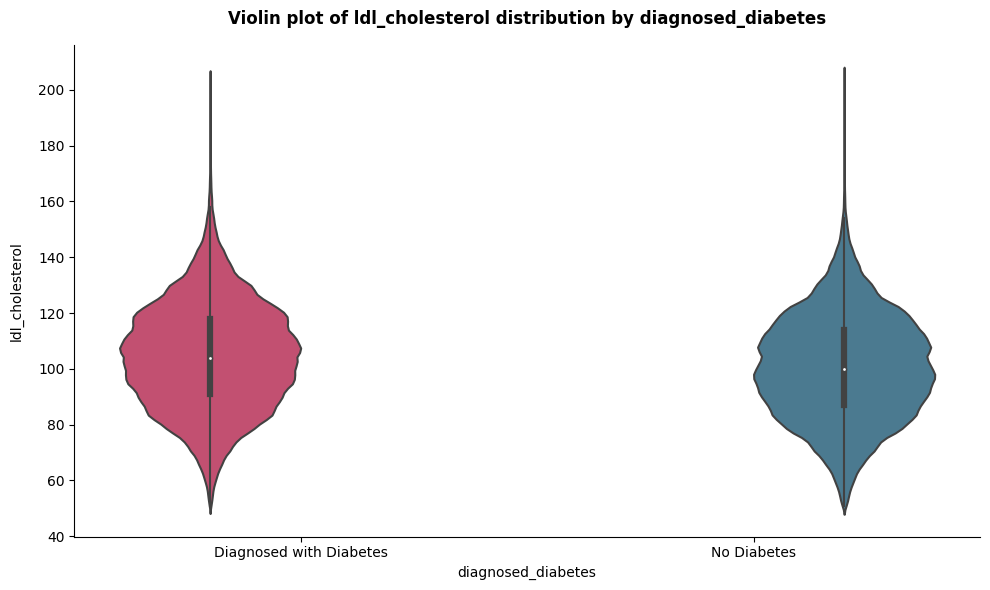

,diagnosed_diabetes,Count,Mean,Median,Std
0,Diagnosed with Diabetes,436307,124.825022,124.000000,24.852648
1,No Diabetes,263693,120.197593,120.000000,24.277571



[i] Checking normality of feature 'triglycerides' by groups of 'diagnosed_diabetes'...
[i] Evaluating distribution characteristics...
[i] Generating Q–Q plots for visual assessment...


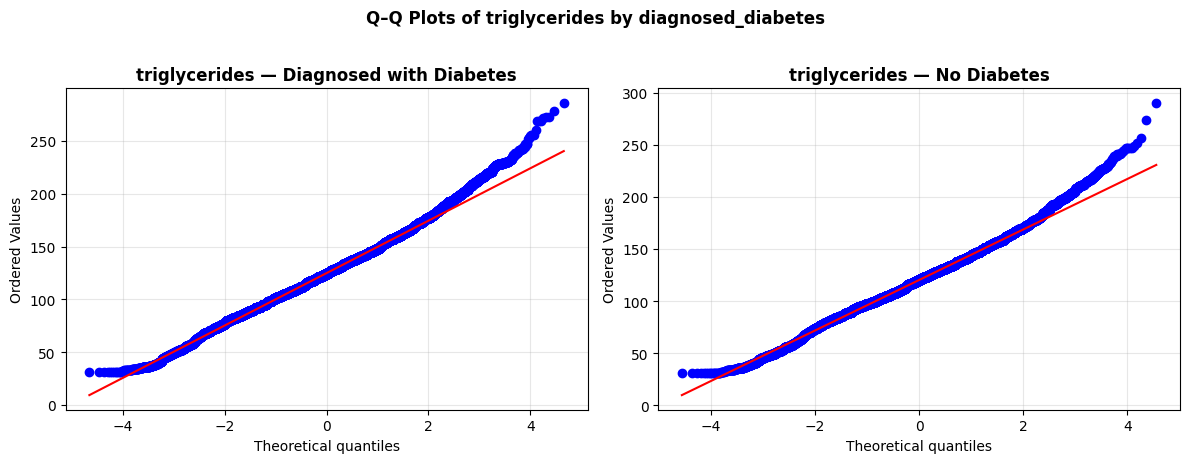

,Feature,Group,Skewness,Kurtosis,Remark
0,triglycerides,Diagnosed with Diabetes,0.2034,0.4605,"Approximately symmetric, Normal tails"
1,triglycerides,No Diabetes,0.1633,0.5039,"Approximately symmetric, Normal tails"


[✓] All groups approximately follow a normal distribution.


,Metric,Value
0,Levene’s Statistic,126.1807
1,p-value,0.000000
2,Max/Min Variance Ratio,1.05



[i] Interpretation:
   [!] Statistically different variances, but practical difference is small.
   Recommendation → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.

[i] Running Independent Two-Sample T-Test: 'triglycerides' ~ 'diagnosed_diabetes'
[i] Test Type: Welch’s T-Test (unequal variances)

[i] Comparing groups: 'Diagnosed with Diabetes' vs 'No Diabetes'
[i] t-statistic: 76.585
[i] p-value: 0.000000
[i] Cohen's d: 0.188
[✓] Significant difference detected (p < 0.05).
[i] Effect size interpretation: small effect (|d| = 0.188)


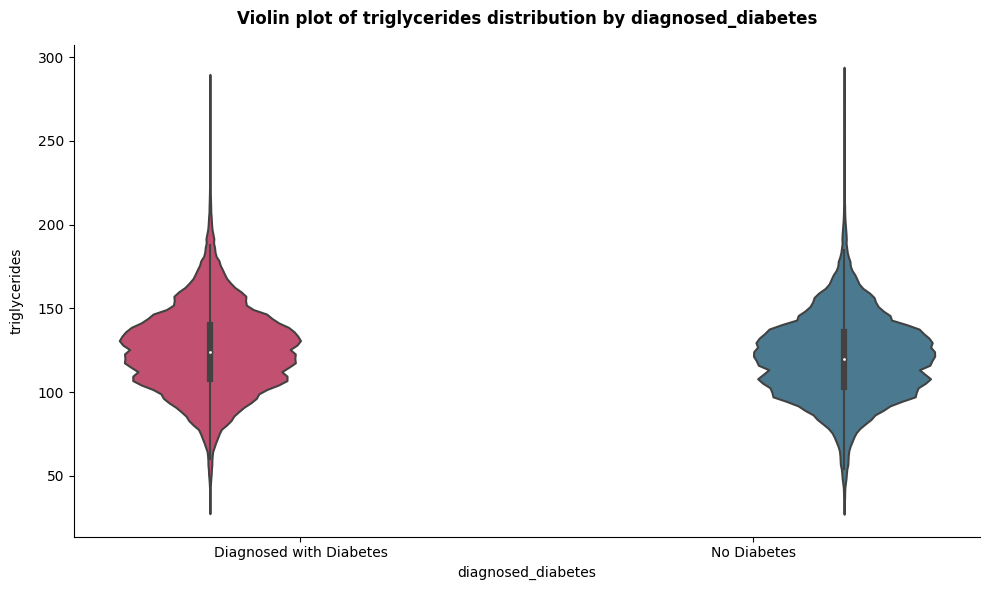

In [23]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df_plot,  target_feature: str = "diagnosed_diabetes") -> None:
    """
    Perform statistical tests (normality and Kruskal-Wallis) 
    to evaluate whether there are significant differences 
    in the distribution of a numerical feature across categories 
    of the target variable.

    Args:
        feature (str): Name of the numerical feature to be tested.
        df (pd.DataFrame): Dataset containing both numerical and target columns.
        target_feature (str): Name of the target categorical feature.

    Returns:
        None: Prints or displays statistical test results.
    """
    # Perform normality test (e.g., Shapiro-Wilk or D’Agostino test) for feature distribution
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    total_categories = df[target_feature].nunique()
    if total_categories > 2:
        if non_normal_detected == True:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    else:
        if non_normal_detected == True:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(feature: str, df: pd.DataFrame = df_plot,
                                target_feature: str = "diagnosed_diabetes", order: list = None) -> None:
    """
    Perform statistical testing and visualize the distribution of a numerical feature 
    across different classes of the target variable using violin plots and summary statistics.

    The function executes:
      1. Statistical tests.
      2. Summary table with mean, median, std per category.
      3. Violin plot for visualizing feature distributions across classes.

    Args:
        feature (str): The name of the numerical feature to analyze.
        df (pd.DataFrame): Input dataframe containing numerical & target features.
        target_feature (str): Target variable name (categorical feature).
        order (list, optional): Custom ordering for category display in the plot.

    Returns:
        None: Displays statistical summaries and plots directly.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique(), tone="diverging"))
    
    plt.title(f"Violin plot of {feature} distribution by {target_feature}", pad=15, weight="bold")
    # plt.xlabel(target_feature, labelpad=10)
    plt.ylabel(feature, labelpad=10)
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature} by Diagnosed Diabetes</b></h2>"))
    plot_numerical_distribution(feature=feature, df = df_plot)

### Insight Numerical Features vs Diagnosed Diabetes

**age**

* Individuals diagnosed with diabetes tend to be **older** on average.
* The difference shows a **moderate effect size**, indicating that age is a **strong distinguishing feature** for diabetes classification.

**physical_activity_minutes_per_week**

* Individuals **without diabetes** engage in **more physical activity** on average.
* The noticeable shift in median suggests that **lower physical activity** is associated with **higher diabetes prevalence**.
* This makes physical activity a **meaningful behavioural predictor** of diabetes.

**diet_score**

* Although statistically significant, the **effect size is small**, meaning diet_score differs only **slightly** between groups.
* Diet quality may contribute to diabetes status, but it is **not a strong standalone discriminator** in this dataset.

**sleep_hours_per_day**

* The difference is statistically significant but **not practically meaningful**.
* Both groups exhibit **nearly identical sleep duration** patterns.
* Sleep hours are **unlikely to be a strong predictor** of diabetes.

**screen_time_hours_per_day**

* Despite significance, the **effect size is extremely small**, indicating very **similar screen-time behavior** between groups.
* Screen time is **not a meaningful differentiator** for diabetes prediction.

**bmi**

* Individuals with diabetes tend to have **higher BMI**.
* The medium effect size indicates BMI is a **notable differentiator**.
* This aligns with established medical evidence: **higher BMI increases diabetes risk**.

**waist_to_hip_ratio**

* People with diabetes show **higher central obesity**, reflected in elevated waist-to-hip ratios.
* Although the effect size is small, the trend supports known evidence: **central fat distribution increases diabetes risk**.
* Waist-to-hip ratio is a **useful but mild predictor**.

**systolic_bp**

* Individuals with diabetes have **higher systolic blood pressure**, consistent with common cardiometabolic patterns.
* The moderate effect size indicates systolic BP is a **useful predictor** of diabetes risk.
* Highlights the need for closer cardiovascular monitoring.

**diastolic_bp**

* The difference is statistically significant but **small in magnitude**.
* Diastolic BP alone is **not a strong differentiator**, but it may add value when combined with other cardiovascular indicators.

**heart_rate**

* Although statistically significant, the **effect size is minimal**, indicating little practical difference.
* Heart rate alone is **not a strong predictor**, but may contribute to broader **cardiometabolic profiling**.

**cholesterol_total**

* The effect size is small, meaning total cholesterol is **not a strong standalone discriminator**.
* However, it remains a key cardiovascular risk factor and may provide value when combined with LDL, triglycerides, BMI, etc.

**hdl_cholesterol**

* Statistically significant but **small effect size**, indicating HDL alone is **not a strong differentiator**.
* Still important as part of cardiovascular risk analysis.

**ldl_cholesterol**

* The difference is meaningful, with a **moderate effect size**.
* Higher LDL levels in diabetic individuals indicate **increased cardiovascular risk**, reinforcing the importance of LDL monitoring.

**triglycerides**

* Individuals with diabetes tend to have **higher triglyceride levels**.
* The difference is small but **consistent and clinically relevant**, indicating triglycerides contribute to **metabolic and cardiovascular risk**.

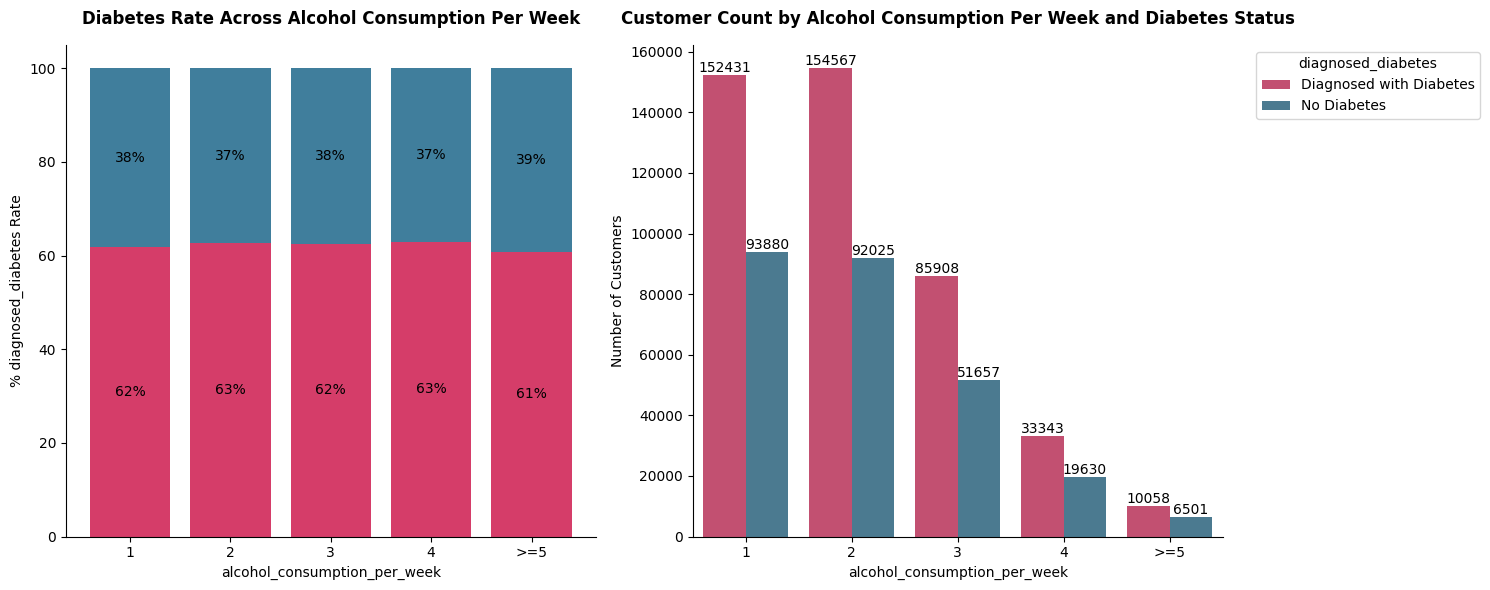


[i] Chi-Square Test of Independence: 'alcohol_consumption_per_week' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 60.817
[i] Degrees of freedom: 4
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'alcohol_consumption_per_week' and 'diagnosed_diabetes' are statistically associated.

[i] Standardized Residuals:
diagnosed_diabetes            Diagnosed with Diabetes  No Diabetes
alcohol_consumption_per_week                                      
1                                               -2.79         3.59
2                                                2.21        -2.85
3                                                0.56        -0.72
4                                                1.79        -2.30
>=5                                             -2.59         3.33


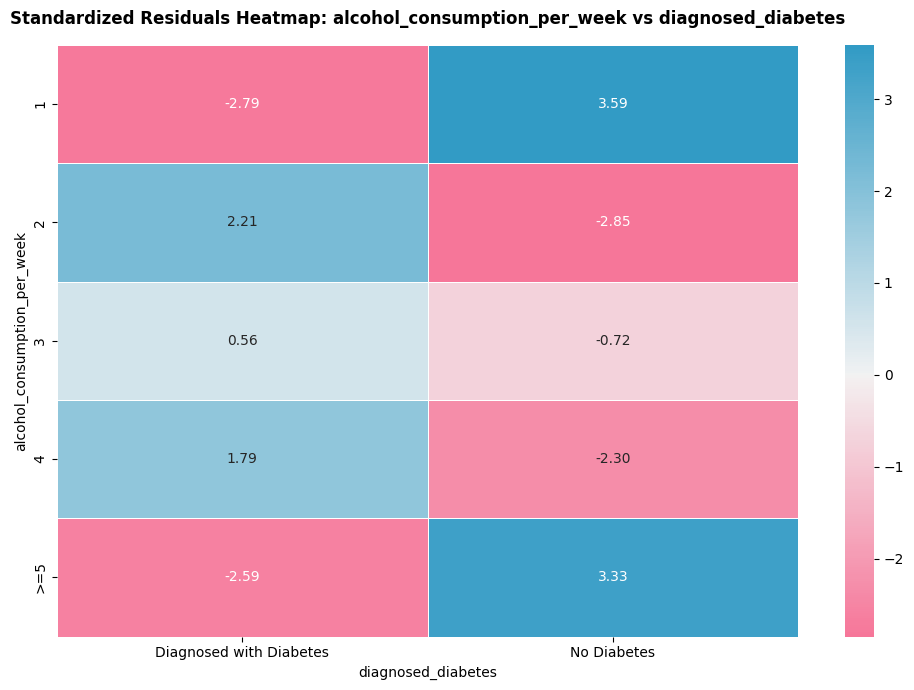

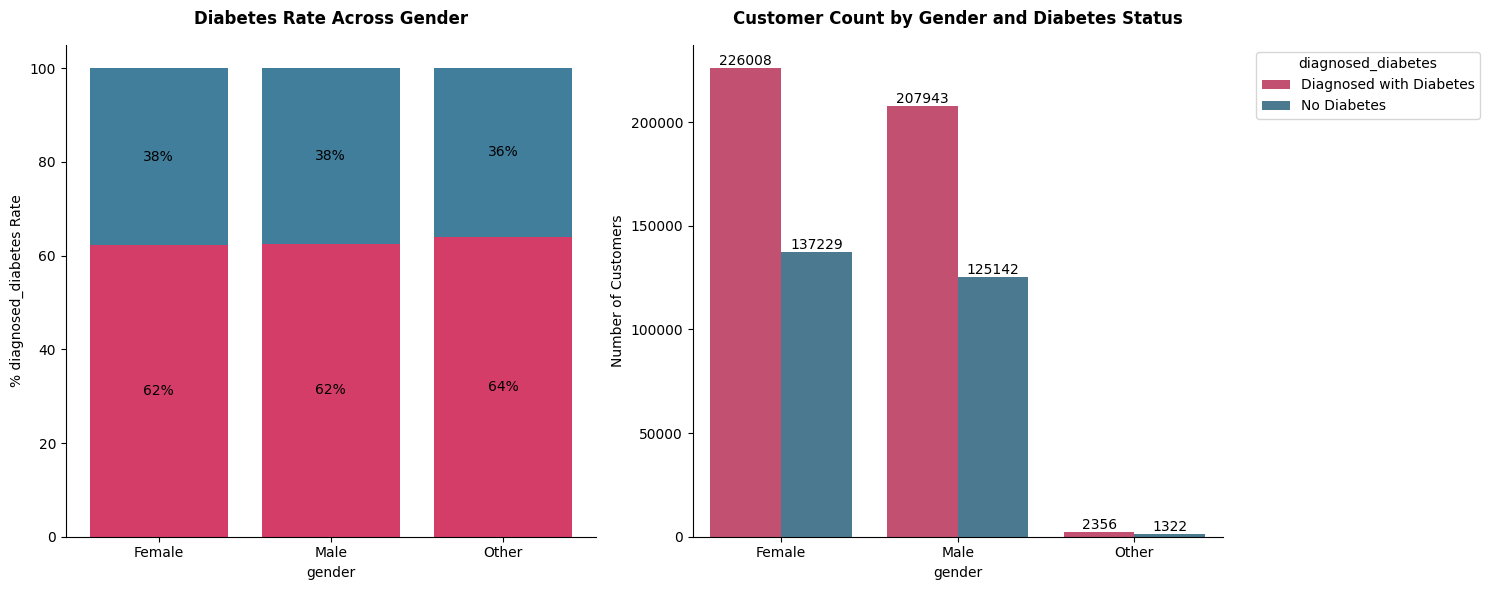


[i] Chi-Square Test of Independence: 'gender' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 7.925
[i] Degrees of freedom: 2
[i] p-value: 0.019014
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'gender' and 'diagnosed_diabetes' are statistically associated.

[i] Standardized Residuals:
diagnosed_diabetes  Diagnosed with Diabetes  No Diabetes
gender                                                  
Female                                -0.83         1.07
Male                                   0.73        -0.94
Other                                  1.33        -1.71


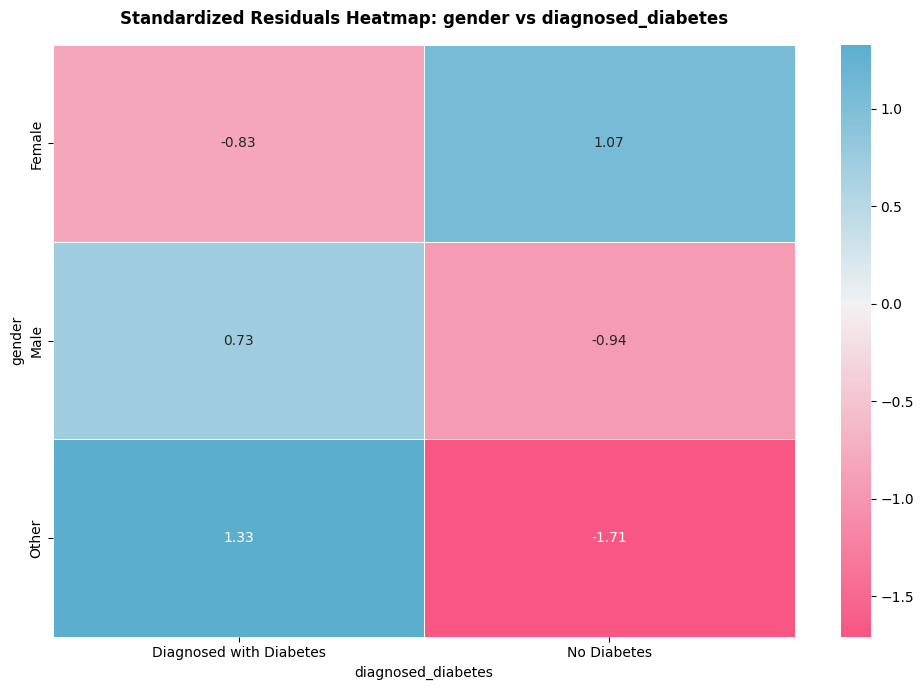

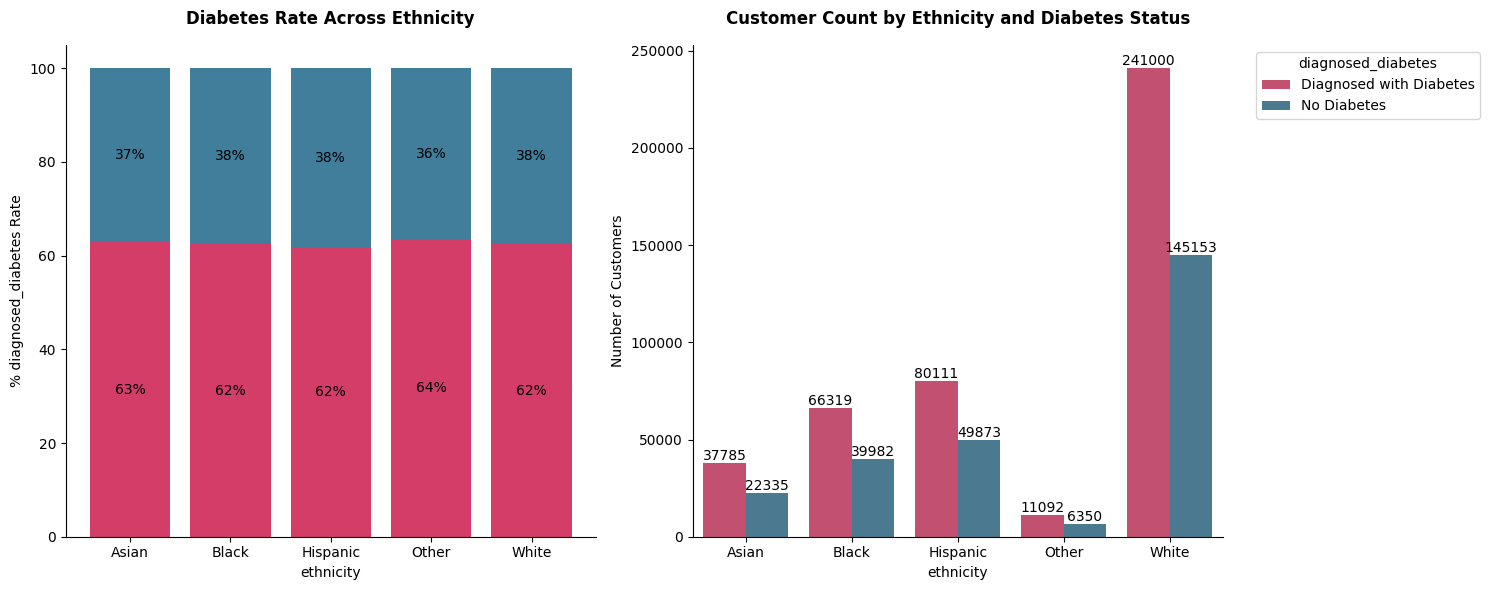


[i] Chi-Square Test of Independence: 'ethnicity' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 46.999
[i] Degrees of freedom: 4
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'ethnicity' and 'diagnosed_diabetes' are statistically associated.

[i] Standardized Residuals:
diagnosed_diabetes  Diagnosed with Diabetes  No Diabetes
ethnicity                                               
Asian                                  1.61        -2.08
Black                                  0.24        -0.31
Hispanic                              -3.19         4.10
Other                                  2.11        -2.72
White                                  0.64        -0.82


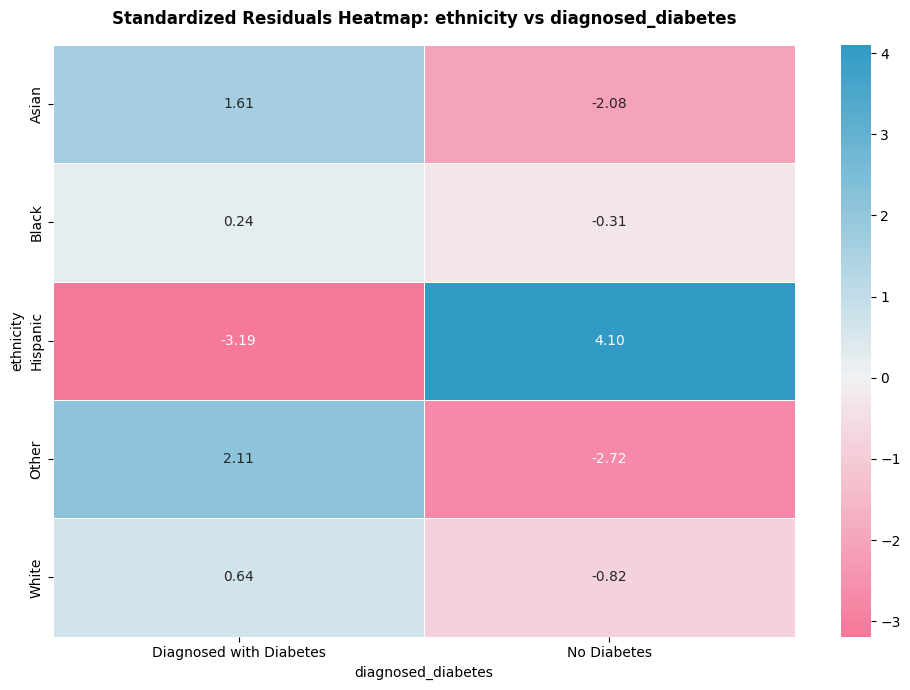

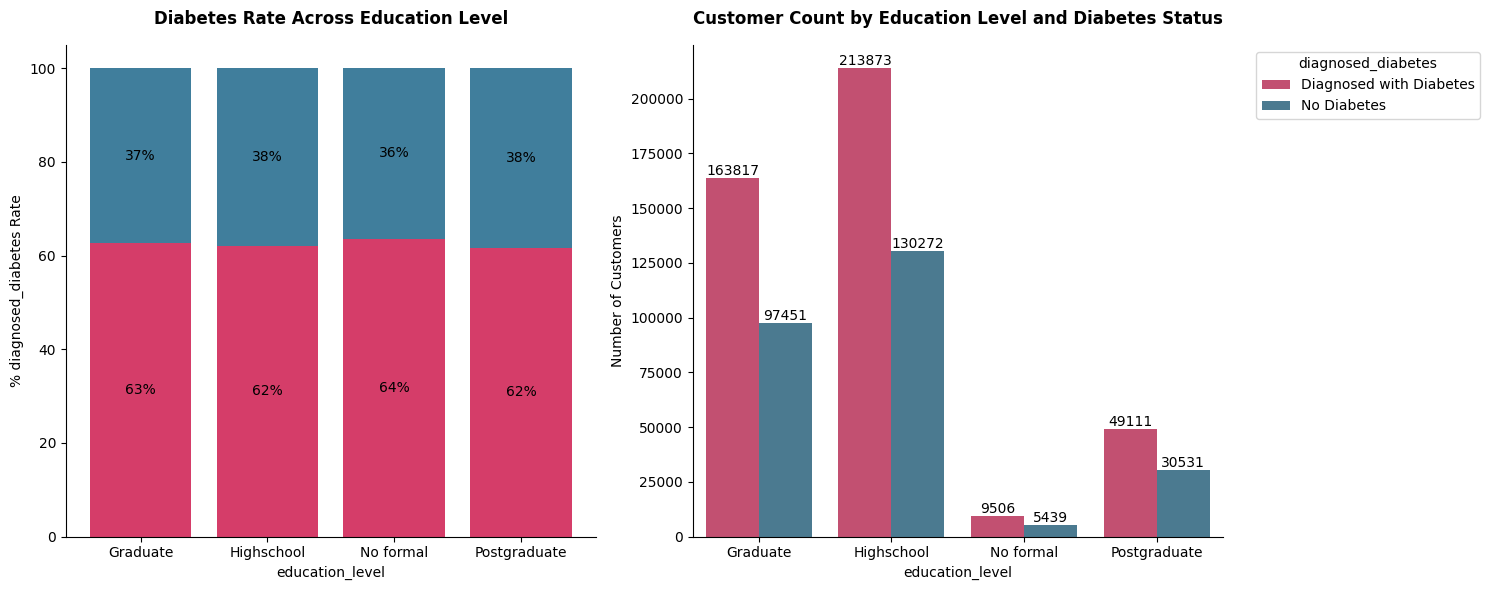


[i] Chi-Square Test of Independence: 'education_level' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 45.633
[i] Degrees of freedom: 3
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'education_level' and 'diagnosed_diabetes' are statistically associated.

[i] Standardized Residuals:
diagnosed_diabetes  Diagnosed with Diabetes  No Diabetes
education_level                                         
Graduate                               2.40        -3.09
Highschool                            -1.36         1.75
No formal                              1.98        -2.54
Postgraduate                          -2.38         3.06


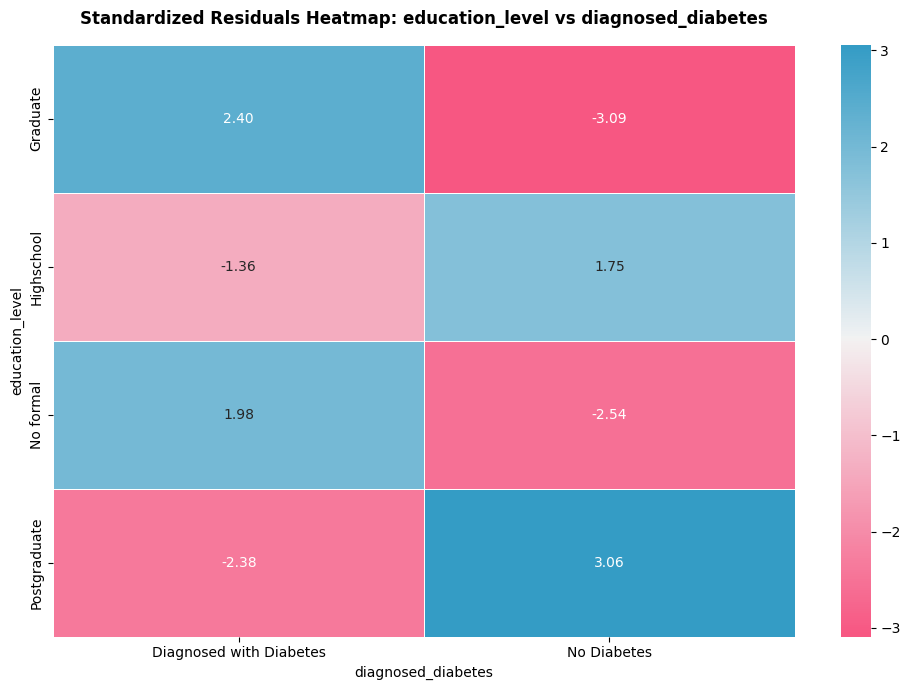

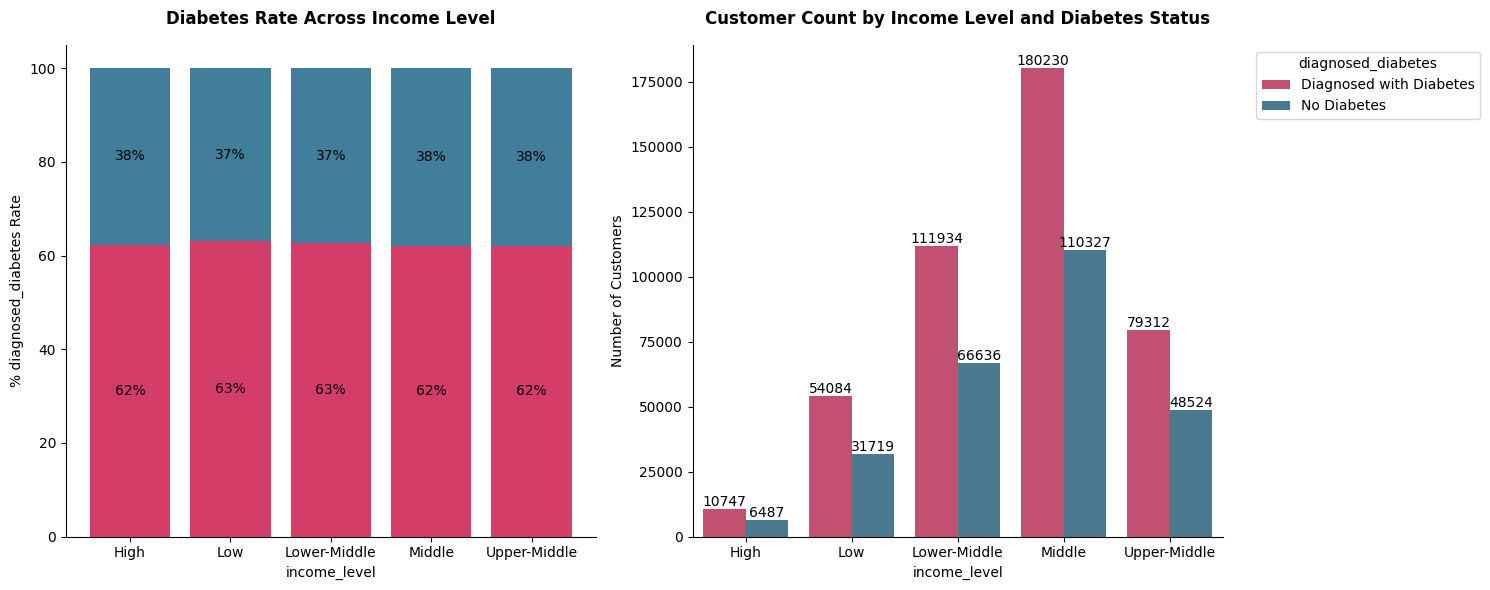


[i] Chi-Square Test of Independence: 'income_level' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 43.278
[i] Degrees of freedom: 4
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'income_level' and 'diagnosed_diabetes' are statistically associated.

[i] Standardized Residuals:
diagnosed_diabetes  Diagnosed with Diabetes  No Diabetes
income_level                                            
High                                   0.05        -0.06
Low                                    2.61        -3.36
Lower-Middle                           1.89        -2.44
Middle                                -2.05         2.64
Upper-Middle                          -1.30         1.68


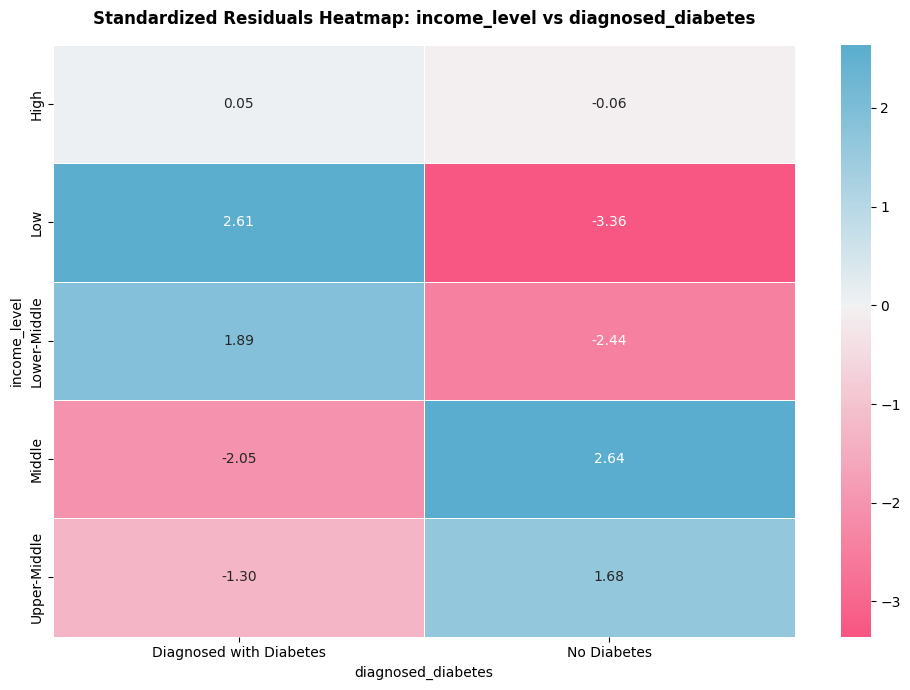

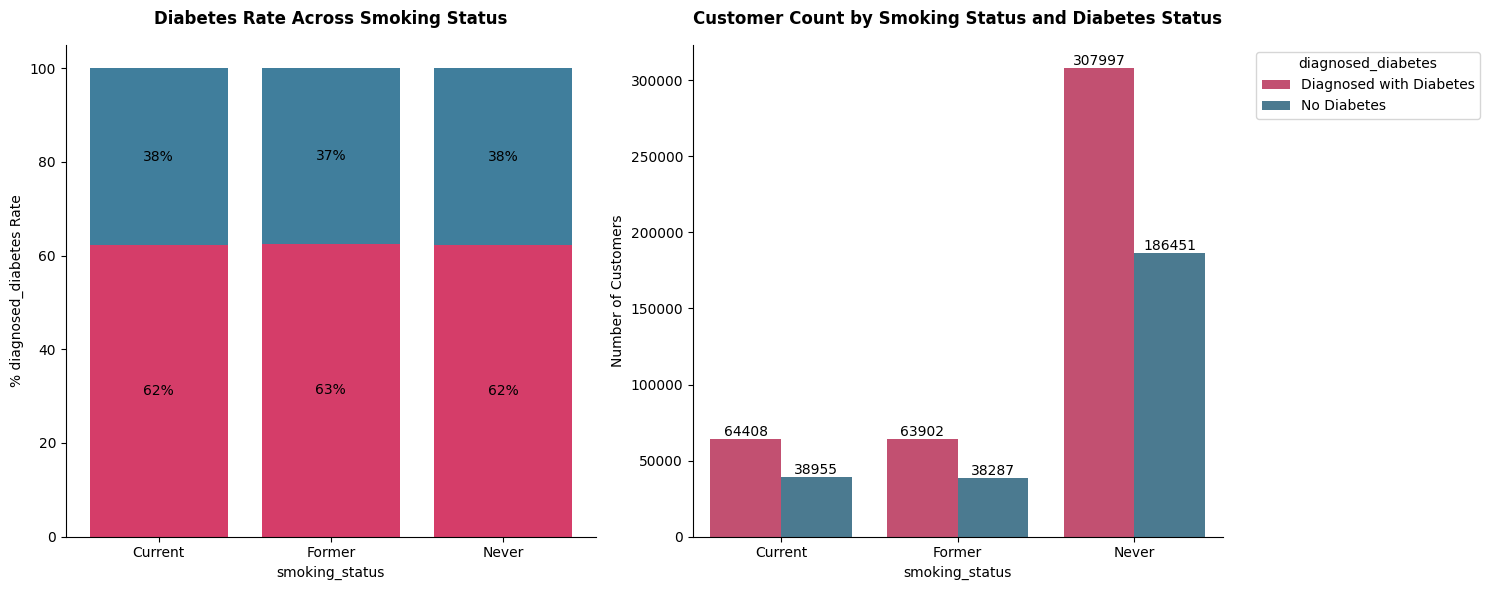


[i] Chi-Square Test of Independence: 'smoking_status' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 2.129
[i] Degrees of freedom: 2
[i] p-value: 0.344960
[!] Result: p-value ≥ 0.05 → Fail to reject H0
[!] No statistically significant association detected between 'smoking_status' and 'diagnosed_diabetes'.

[i] Standardized Residuals:
diagnosed_diabetes  Diagnosed with Diabetes  No Diabetes
smoking_status                                          
Current                               -0.07         0.09
Former                                 0.82        -1.06
Never                                 -0.34         0.44


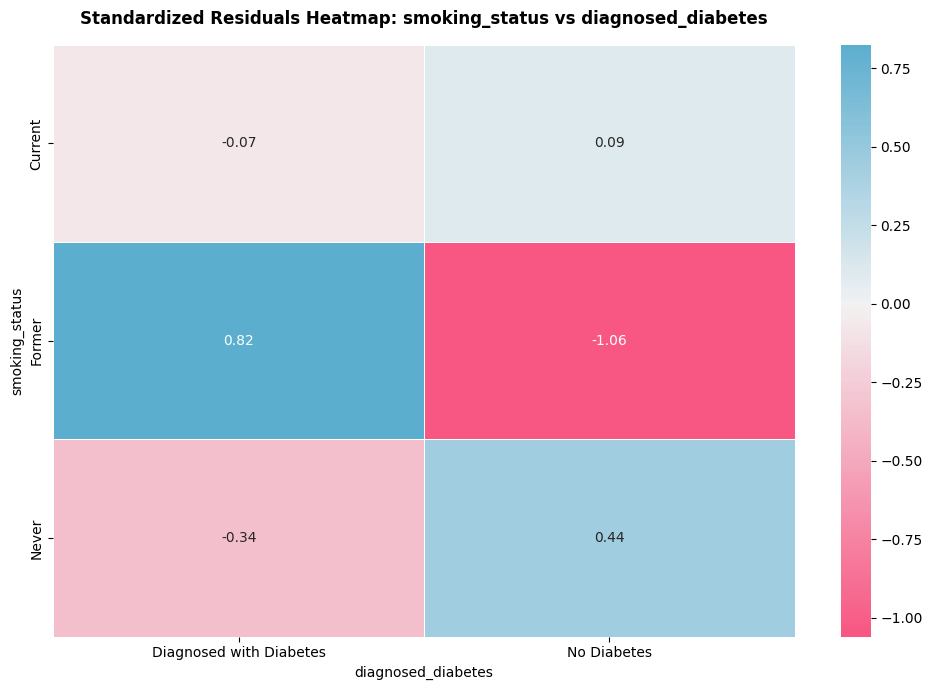

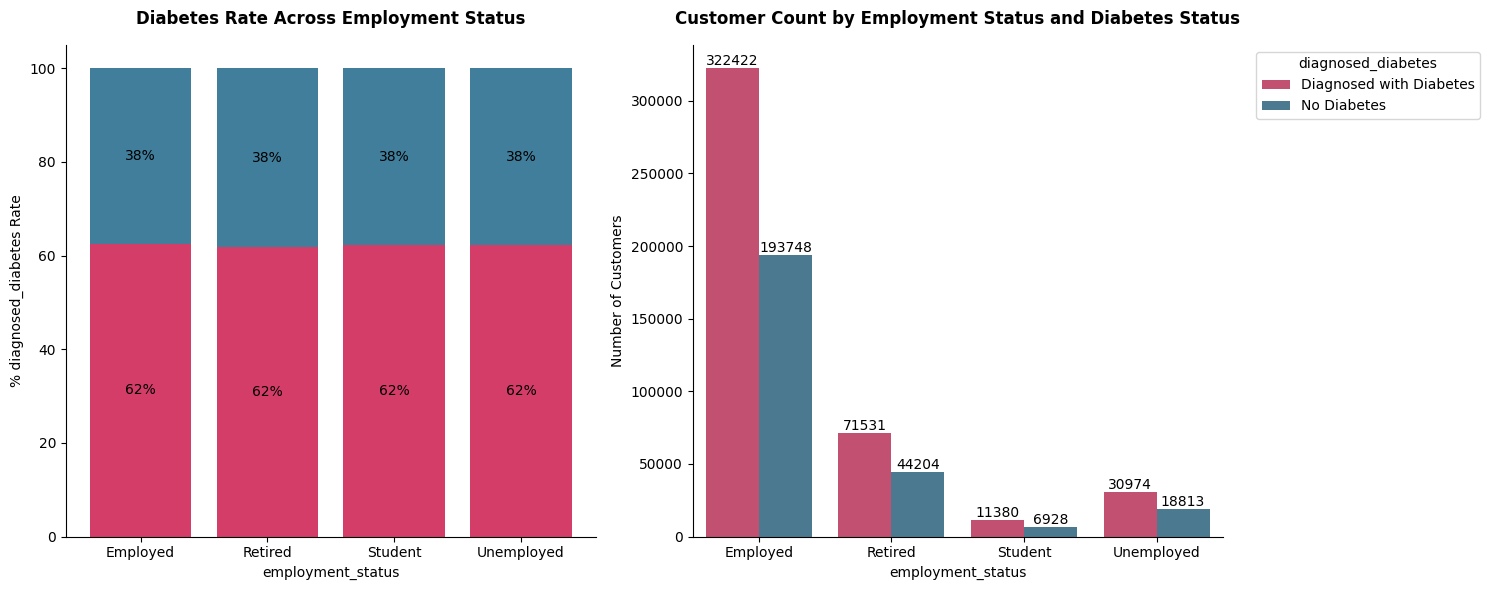


[i] Chi-Square Test of Independence: 'employment_status' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 18.026
[i] Degrees of freedom: 3
[i] p-value: 0.000434
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'employment_status' and 'diagnosed_diabetes' are statistically associated.

[i] Standardized Residuals:
diagnosed_diabetes  Diagnosed with Diabetes  No Diabetes
employment_status                                       
Employed                               1.23        -1.58
Retired                               -2.26         2.90
Student                               -0.29         0.38
Unemployed                            -0.33         0.42


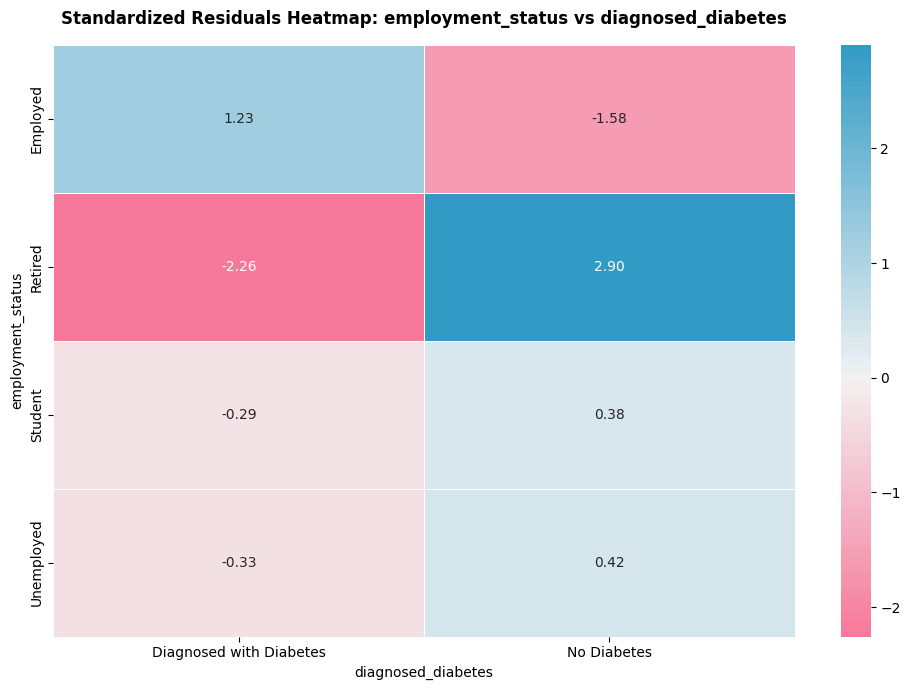

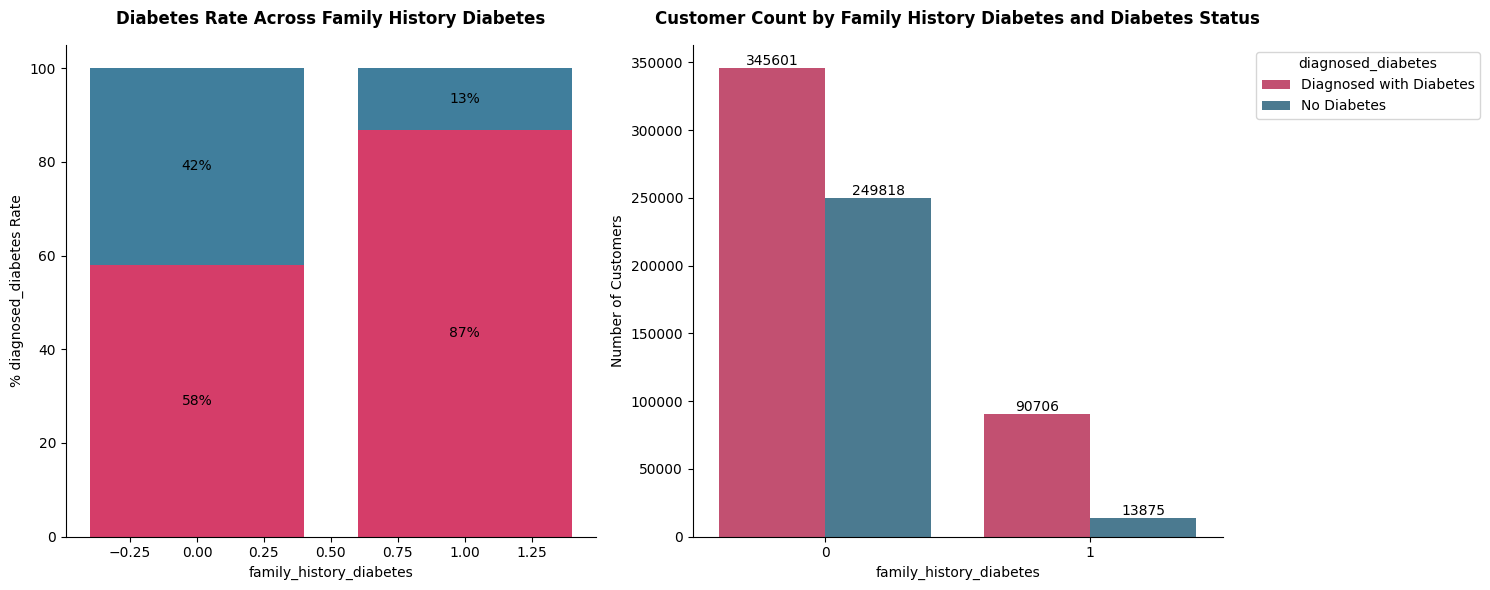


[i] Chi-Square Test of Independence: 'family_history_diabetes' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 31182.433
[i] Degrees of freedom: 1
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'family_history_diabetes' and 'diagnosed_diabetes' are statistically associated.

[i] Standardized Residuals:
diagnosed_diabetes       Diagnosed with Diabetes  No Diabetes
family_history_diabetes                                      
0                                         -41.89        53.89
1                                          99.96      -128.58


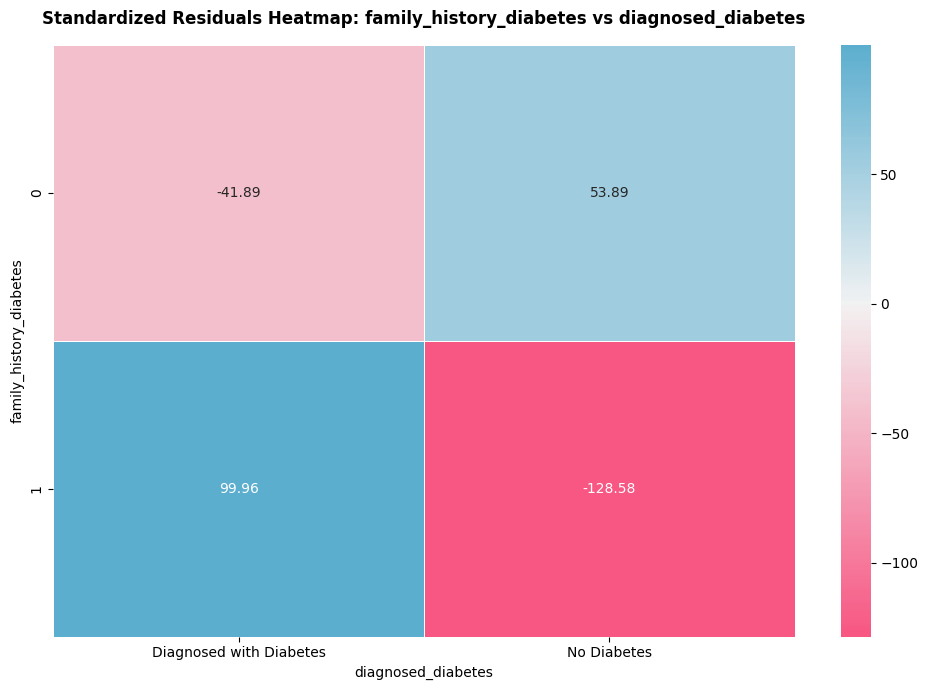

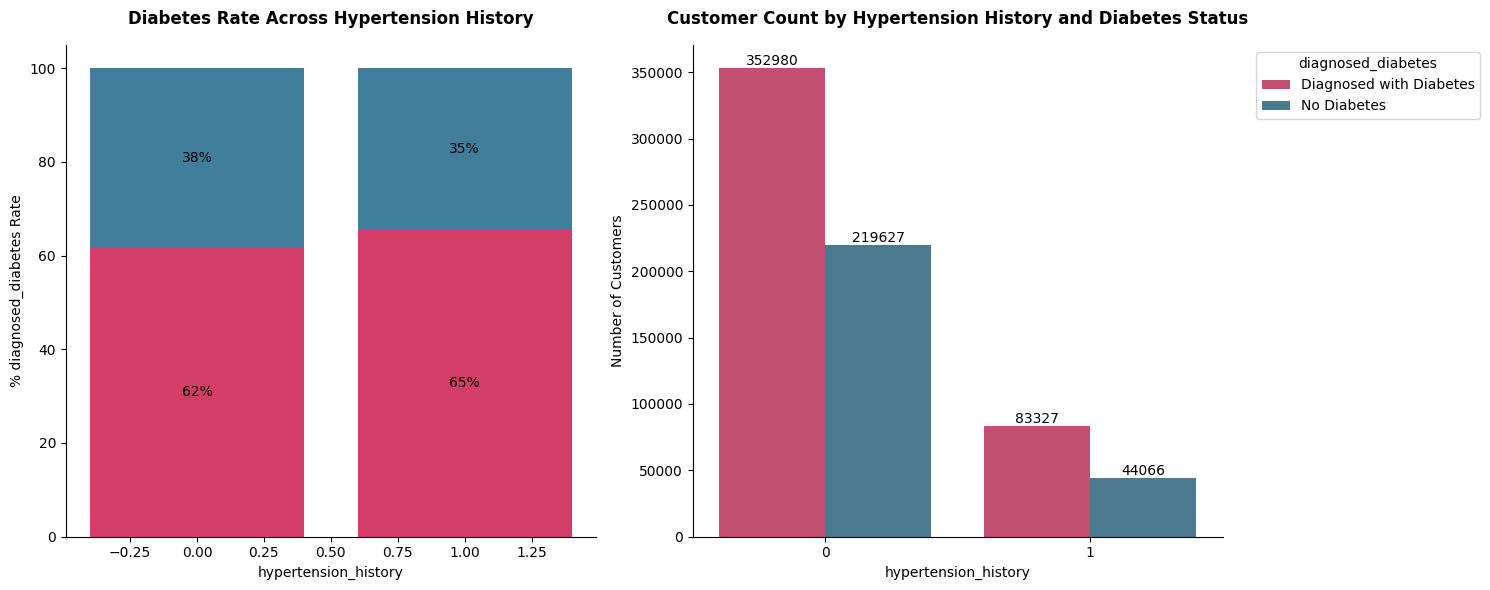


[i] Chi-Square Test of Independence: 'hypertension_history' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 628.978
[i] Degrees of freedom: 1
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'hypertension_history' and 'diagnosed_diabetes' are statistically associated.

[i] Standardized Residuals:
diagnosed_diabetes    Diagnosed with Diabetes  No Diabetes
hypertension_history                                      
0                                       -6.57         8.45
1                                       13.92       -17.91


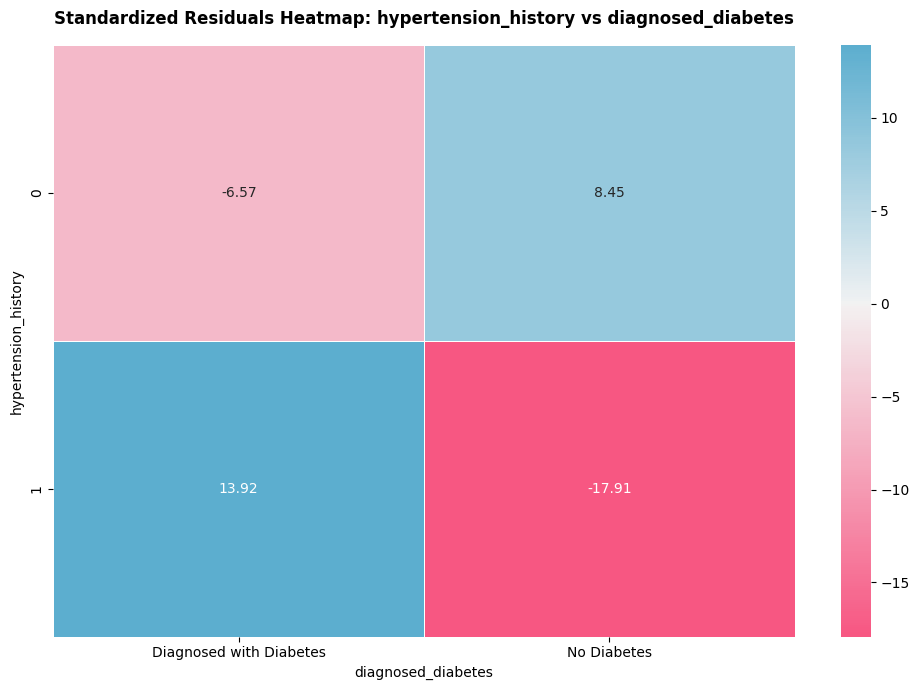

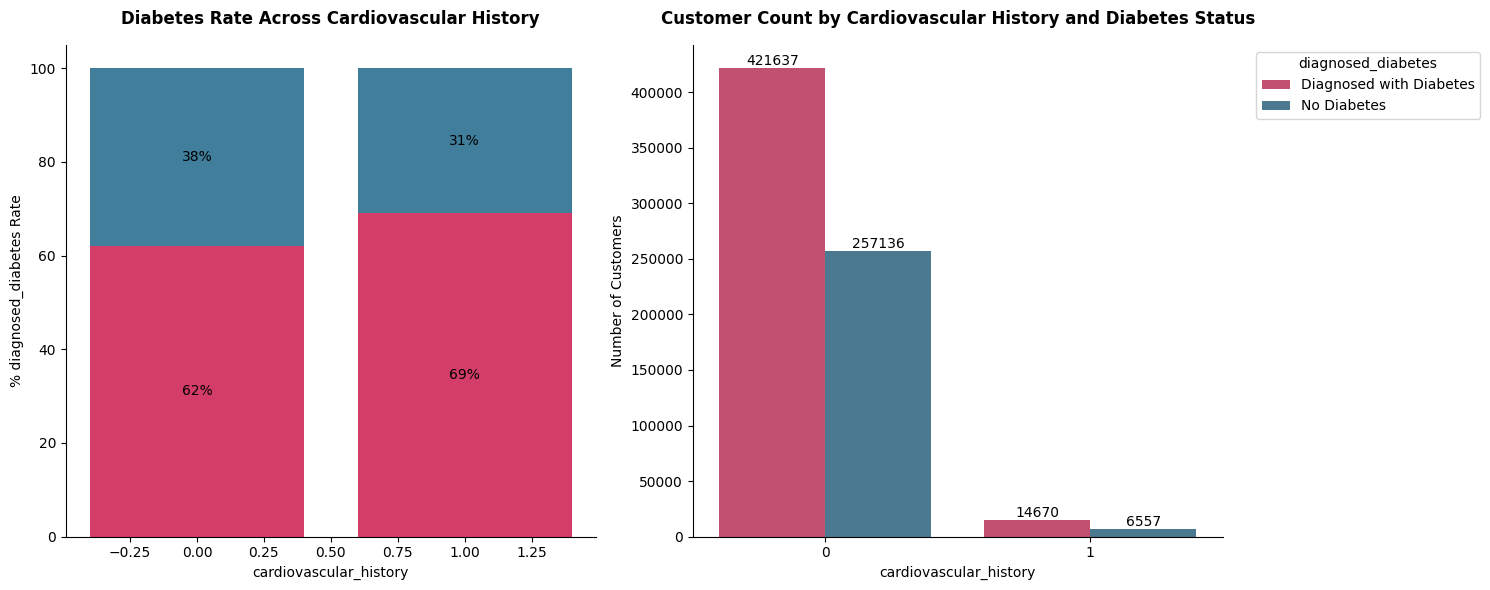


[i] Chi-Square Test of Independence: 'cardiovascular_history' vs. 'diagnosed_diabetes'...
[i] Chi-squared statistic: 428.343
[i] Degrees of freedom: 1
[i] p-value: 0.000000
[✓] Result: p-value < 0.05 → Reject H₀
[✓] Variables 'cardiovascular_history' and 'diagnosed_diabetes' are statistically associated.

[i] Standardized Residuals:
diagnosed_diabetes      Diagnosed with Diabetes  No Diabetes
cardiovascular_history                                      
0                                         -2.21         2.85
1                                         12.51       -16.10


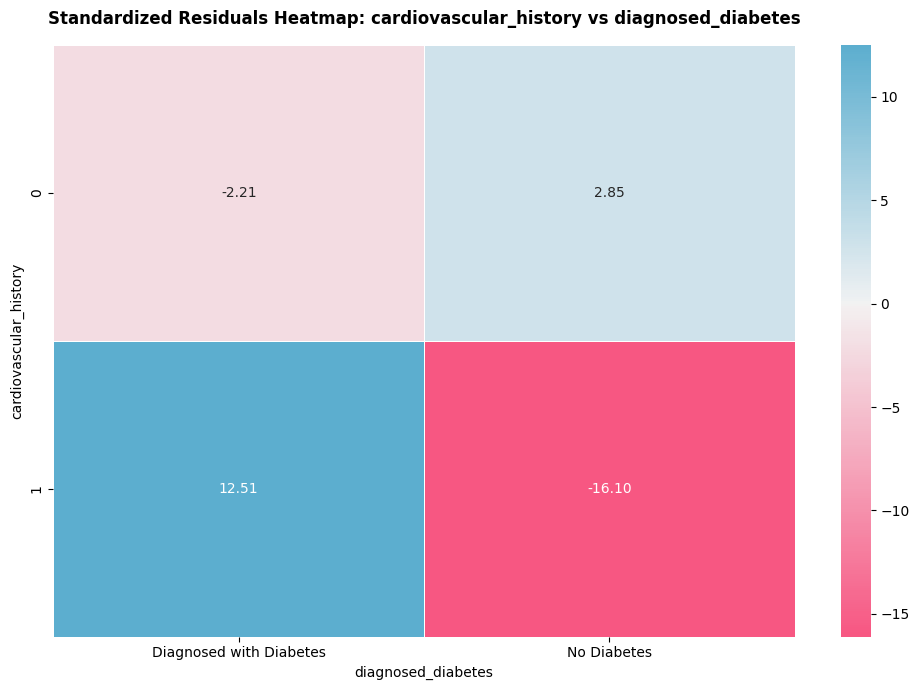

In [24]:
def alcohol_bin(x):
    if x == 0:
        return "0"
    if x == 1:
        return "1"
    elif x == 2:
        return "2"
    elif x == 3:
        return "3"
    elif x == 4:
        return "4"
    else:
        return ">=5"
        
df_train["alcohol_consumption_per_week"] = df_train["alcohol_consumption_per_week"].apply(alcohol_bin)
df_test["alcohol_consumption_per_week"] = df_test["alcohol_consumption_per_week"].apply(alcohol_bin)
df_plot["alcohol_consumption_per_week"] = df_plot["alcohol_consumption_per_week"].apply(alcohol_bin)

def bivariate_percent_plot(cat, target_feature, df, figsize=(15, 6), order=None):
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {cat} by {target_feature}</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize)

    # Data processing
    grouped = df.groupby([cat, target_feature]).size().unstack(fill_value=0)

    # Define a fixed hue order (adjust if needed)
    target_order = [c for c in ["Diagnosed with Diabetes", "No Diabetes"] if c in grouped.columns]

    # Fallback if the labels are 0/1 or have different names
    if not target_order:
        target_order = list(grouped.columns)

    # Calculate percentages row-wise and reorder columns by target_order
    percentages = grouped.div(grouped.sum(axis=1), axis=0)[target_order] * 100

    # Define X-axis category order
    if order is not None:
        percentages = percentages.loc[order]
        labels = order
    else:
        labels = percentages.index.tolist()

    # Consistent color palette for both charts
    base_colors = color(n_colors=len(target_order), tone="diverging")
    color_map = dict(zip(target_order, base_colors))

    # Plot 1: Stacked bar chart (percentage)
    bottom = np.zeros(len(percentages))
    for cls in target_order:
        ax[0].bar(percentages.index, percentages[cls].values, bottom=bottom,
                  label=cls, color=color_map[cls])
        bottom += percentages[cls].values

    # Add percentage labels
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt="%1.0f%%", label_type="center",
                        fontsize=10, color="black")

    ax[0].set_title(f"Diabetes Rate Across {cat.replace('_', ' ').title()}", fontsize=12, weight="bold", pad=15)
    ax[0].set_xlabel(f"{cat}", fontsize=10)
    ax[0].set_ylabel(f"% {target_feature} Rate", fontsize=10)
    sns.despine(left=False, bottom=False, ax=ax[0])
    ax[0].legend().remove()

    # Plot 2: Count plot (using same color_map + hue_order)
    sns.countplot(data=df, hue=target_feature, x=cat,
                  order=labels, hue_order=target_order,
                  palette=color_map, ax=ax[1])

    for container in ax[1].containers:
        ax[1].bar_label(container, fmt="%d", label_type="edge",
                        fontsize=10, color="black")

    ax[1].set_title(f"Customer Count by {cat.replace('_', ' ').title()} and Diabetes Status", fontsize=12, weight="bold", pad=15)
    ax[1].set_xlabel(f"{cat}", fontsize=10)
    ax[1].set_ylabel("Number of Customers", fontsize=10)
    ax[1].legend(title=target_feature, bbox_to_anchor=(1.05, 1), loc="upper left")
    sns.despine(left=False, bottom=False, ax=ax[1])

    plt.tight_layout()
    plt.show()

    # Chi-Square Test
    cal_ChiSquare(cat_feature=cat, target_feature=target_feature, df=df, show_residuals=True)

# Run for all categorical features
for feature in cat_features:
    bivariate_percent_plot(cat=feature, target_feature="diagnosed_diabetes", df=df_plot)

### Insight Categorical Features vs Diagnosed Diabetes

**alcohol_consumption_per_week** <br>
Alcohol consumption has a mild association with diabetes. Moderate drinking levels (2–4 times/week) show slightly higher diabetes prevalence.

**gender** <br>
Gender shows a mild statistical association with diabetes, but no group exhibits a strong or practically meaningful deviation from expected patterns.

**ethnicity** <br>
Ethnicity is statistically associated with diabetes status, with Hispanic and some Asian/Other subgroups showing the most notable deviations from expected distributions.

**education_level** <br>
Education level is meaningfully linked to diabetes risk. Graduate and No-formal groups show elevated diabetes prevalence, while Postgraduates demonstrate a lower-than-expected rate.

**income_level** <br>
Income level is associated with diabetes status. Lower-income groups have higher diabetes prevalence, whereas middle-income individuals show lower-than-expected rates.

**smoking_status** <br>
Smoking status does not meaningfully differentiate between diabetic and non-diabetic individuals.

**employment_status** <br>
Employment status shows a mild association with diabetes, with the Retired group contributing the most to observed deviations.

**family_history_diabetes** <br>
Family history is the strongest categorical predictor — individuals with diabetic family members are far more likely to be diagnosed themselves.

**hypertension_history** <br>
Hypertension history is a strong indicator associated with diabetes — individuals with hypertension are significantly more likely to have diabetes.

**cardiovascular_history** <br>
Cardiovascular history is a significant risk marker — individuals with heart-related conditions have a substantially higher likelihood of being diagnosed with diabetes.

### Overall Picture

| **Feature**                            | **Summary**                                                                                                                                              |
| -------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **age**                                | Individuals with diabetes are generally **older**, and age shows a **moderate practical impact**, making it a strong distinguishing feature.             |
| **physical_activity_minutes_per_week** | Non-diabetic individuals engage in **more physical activity**. Lower activity levels are **meaningfully linked** to higher diabetes prevalence.          |
| **diet_score**                         | Differences are statistically significant but **very small in effect**, meaning diet score alone is **not a strong discriminator**.                      |
| **sleep_hours_per_day**                | Sleep duration is nearly identical between groups → **not a meaningful predictor** despite statistical significance.                                     |
| **screen_time_hours_per_day**          | Extremely small effect size; screen time is **not a practical differentiator** between diabetic and non-diabetic individuals.                            |
| **bmi**                                | Individuals with diabetes have **higher BMI**. Medium effect size → BMI is a **notable and relevant predictor** of diabetes risk.                        |
| **waist_to_hip_ratio**                 | Diabetic individuals show **higher central obesity**. A small but meaningful trend aligned with medical evidence.                                        |
| **systolic_bp**                        | Higher systolic BP is more common in diabetes; **moderate effect size** → a useful cardiometabolic indicator.                                            |
| **diastolic_bp**                       | Small effect size → diastolic BP alone is **not a strong differentiator**, though it contributes when combined with systolic BP.                         |
| **heart_rate**                         | Very small effect size → heart rate is **not a strong standalone predictor**, but supports broader cardiometabolic profiling.                            |
| **cholesterol_total**                  | Small effect size, but total cholesterol remains a **supporting cardiovascular risk marker** when combined with other lipid indicators.                  |
| **hdl_cholesterol**                    | Small effect → HDL alone is **not a strong discriminator**, though clinically relevant as part of lipid profile.                                         |
| **ldl_cholesterol**                    | Statistically and practically meaningful; diabetic individuals have **higher LDL**, indicating increased cardiovascular risk.                            |
| **triglycerides**                      | Diabetic individuals show **elevated triglycerides**; small-to-moderate effect and clinically relevant.                                                  |
| **alcohol_consumption_per_week**       | Mild association; moderate consumption levels (2–4×/week) show **slightly higher diabetes prevalence**.                                                  |
| **gender**                             | Mild association but **no group deviates strongly** from expected patterns.                                                                              |
| **ethnicity**                          | Statistically associated; Hispanic and some Asian/Other subgroups show the **most notable deviations**.                                                  |
| **education_level**                    | Meaningful association; *Graduate* and *No-formal* groups show **higher diabetes rates**, while *Postgraduates* show **lower-than-expected** prevalence. |
| **income_level**                       | Lower-income groups show **higher diabetes prevalence**, whereas middle-income individuals are **below expectation**.                                    |
| **smoking_status**                     | **No meaningful difference** between diabetic and non-diabetic individuals.                                                                              |
| **employment_status**                  | Mild association; the **Retired** group contributes the most to deviation, while other groups show small differences.                                    |
| **family_history_diabetes**            | **Strongest categorical predictor** — individuals with family history are **significantly more likely** to have diabetes.                                |
| **hypertension_history**               | Strong indicator — those with hypertension are **much more likely** to be diabetic.                                                                      |
| **cardiovascular_history**             | Significant risk marker — history of cardiovascular disease is **strongly linked** to diabetes diagnosis.                                                |


## Some Questions

### Risk & Metabolic Health Interaction

#### Does the combination of high BMI + family history amplify diabetes risk more than each factor alone?

In [25]:
df_plot["diagnosed_diabetes_binary"] = df_plot["diagnosed_diabetes"].map({
    "No Diabetes": 0,
    "Diagnosed with Diabetes": 1
})

def bmi_bin(x):
    if x < 18.5:
        return "Underweight"
    if x >= 18.5 and x < 25:
        return "Normal"
    elif x >= 25 and x < 30:
        return "Overweight"
    else:
        return "Obese"
df_plot["bmi_group"] = df_plot["bmi"].apply(bmi_bin)

print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula="diagnosed_diabetes_binary ~ bmi_group + family_history_diabetes",
    data=df_plot
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.632536
         Iterations 6
                               Logit Regression Results                              
Dep. Variable:     diagnosed_diabetes_binary   No. Observations:               700000
Model:                                 Logit   Df Residuals:                   699995
Method:                                  MLE   Df Model:                            4
Date:                       Wed, 03 Dec 2025   Pseudo R-squ.:                 0.04513
Time:                               11:43:29   Log-Likelihood:            -4.4277e+05
converged:                              True   LL-Null:                   -4.6370e+05
Covariance Type:                   nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

[i] Computing percentage table by BMI Group × Family History Diabetes...


diagnosed_diabetes                   Diagnosed with Diabetes  No Diabetes
bmi_group   family_history_diabetes                                      
Normal      0                                      52.744004    47.255996
            1                                      83.961159    16.038841
Obese       0                                      68.940182    31.059818
            1                                      91.073352     8.926648
Overweight  0                                      60.234900    39.765100
            1                                      88.042417    11.957583
Underweight 0                                      42.455340    57.544660
            1                                      76.421053    23.578947

[i] Running Chi-Square Test for combined factors (BMI Group × Family History Diabetes) vs Diagnosed Diabetes...
[i] Chi2: 37360.5163
[i] dof: 7
[i] p-value: 0.000000


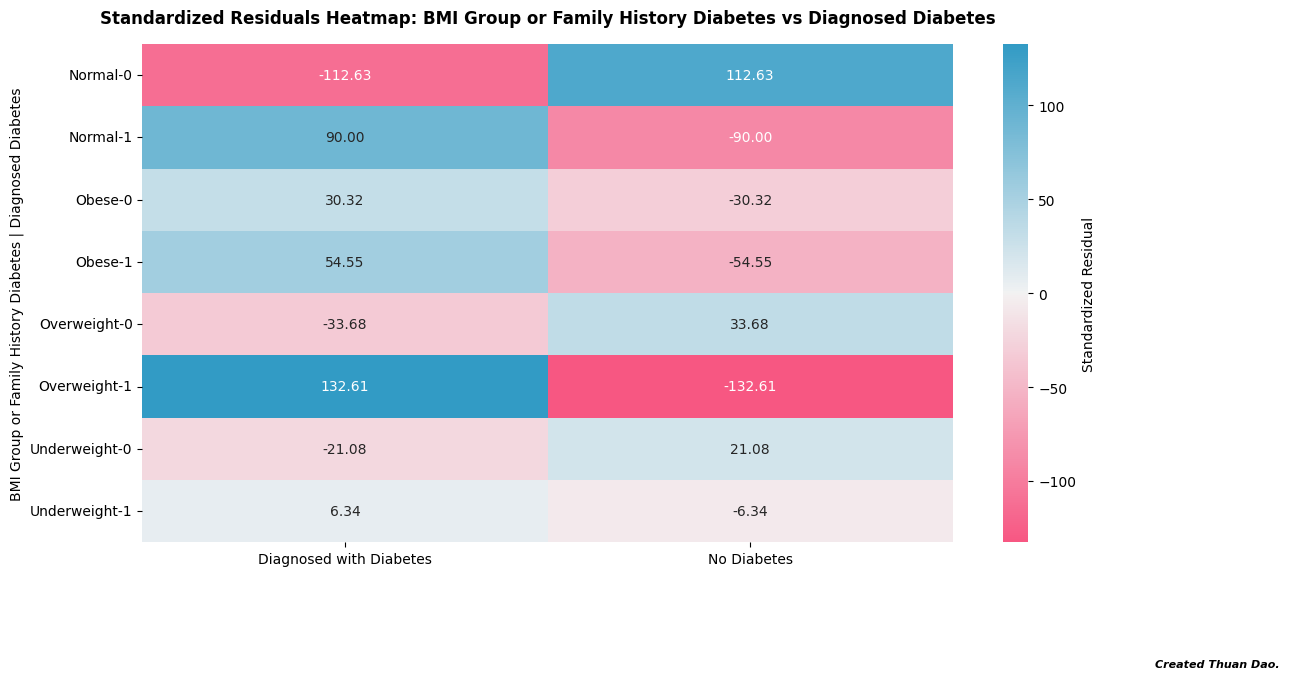

In [26]:
print("[i] Computing percentage table by BMI Group × Family History Diabetes...")
df_group = pd.crosstab(
    [df_plot["bmi_group"], df_plot["family_history_diabetes"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (BMI Group × Family History Diabetes) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["bmi_group"], df_plot["family_history_diabetes"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(13,7))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: BMI Group or Family History Diabetes vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("BMI Group or Family History Diabetes | Diagnosed Diabetes")
plt.xlabel("")
plt.text(2.5, 10, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

**High BMI and family history both elevate diabetes risk, and family history is the dominant driver (OR ≈ 4.8).
Obesity carries the highest *true* individual risk (OR ≈ 1.99), but in the heatmap, the Overweight + FH group shows the largest standardized residual.**

**Why?**
Because this subgroup is much larger, causing its observed diabetes count to exceed statistical expectations more dramatically.

#### How do waist-to-hip ratio, systolic BP, and triglycerides interact in predicting diabetes likelihood?

In [27]:
def whr_group(row):
    whr = row["waist_to_hip_ratio"]
    sex = row["gender"]  # 'Male' or 'Female'

    if sex == "Female":
        if whr < 0.80:
            return "Low Risk"
        elif whr < 0.85:
            return "Moderate Risk"
        else:
            return "High Risk"

    else:  # Male
        if whr < 0.90:
            return "Low Risk"
        elif whr < 1.00:
            return "Moderate Risk"
        else:
            return "High Risk"

df_plot["whr_group"] = df_plot.apply(whr_group, axis=1)

def sbp_group(x):
    if x < 120:
        return "Normal"
    elif x < 130:
        return "Elevated"
    elif x < 140:
        return "Hypertension Stage 1"
    else:
        return "Hypertension Stage 2"

df_plot["sbp_group"] = df_plot["systolic_bp"].apply(sbp_group)

def tg_group(x):
    if x < 150:
        return "Normal"
    elif x < 200:
        return "Borderline High"
    elif x < 500:
        return "High"
    else:
        return "Very High"

df_plot["tg_group"] = df_plot["triglycerides"].apply(tg_group)

print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula="diagnosed_diabetes_binary ~ whr_group + sbp_group + tg_group",
    data=df_plot
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.656722
         Iterations 5
                               Logit Regression Results                              
Dep. Variable:     diagnosed_diabetes_binary   No. Observations:               700000
Model:                                 Logit   Df Residuals:                   699992
Method:                                  MLE   Df Model:                            7
Date:                       Wed, 03 Dec 2025   Pseudo R-squ.:                0.008613
Time:                               11:43:40   Log-Likelihood:            -4.5971e+05
converged:                              True   LL-Null:                   -4.6370e+05
Covariance Type:                   nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

[i] Computing percentage table by WHR Group × Systolic BP Group × Triglycerides Group...


diagnosed_diabetes                                  Diagnosed with Diabetes  \
whr_group     sbp_group            tg_group                                   
High Risk     Elevated             Borderline High                71.683734   
                                   High                           73.951435   
                                   Normal                         66.177238   
              Hypertension Stage 1 Borderline High                75.379038   
                                   High                           83.856502   
                                   Normal                         70.165671   
              Hypertension Stage 2 Borderline High                82.434515   
                                   High                           82.608696   
                                   Normal                         78.197183   
              Normal               Borderline High                65.987711   
                                   High                           69.128788   
                                   Normal                         60.852692   
Low Risk      Elevated             Borderline High                69.688517   
                                   High                           75.438596   
                                   Normal                         63.725166   
              Hypertension Stage 1 Borderline High                74.153592   
                                   High                           73.170732   
                                   Normal                         67.724635   
              Hypertension Stage 2 Borderline High                82.210708   
                                   High                           77.777778   
                                   Normal                         77.577320   
              Normal               Borderline High                63.702491   
                                   High                           69.503546   
                                   Normal                         57.628251   
Moderate Risk Elevated             Borderline High                71.132472   
                                   High                           77.551020   
                                   Normal                         63.217813   
              Hypertension Stage 1 Borderline High                74.101412   
                                   High                           80.405405   
                                   Normal                         68.141531   
              Hypertension Stage 2 Borderline High                83.448276   
                                   High                           78.723404   
                                   Normal                         79.971388   
              Normal               Borderline High                64.812620   
                                   High                           70.294118   
                                   Normal                         57.104714   

diagnosed_diabetes                                  No Diabetes  
whr_group     sbp_group            tg_group                      
High Risk     Elevated             Borderline High    28.316266  
                                   High               26.048565  
                                   Normal             33.822762  
              Hypertension Stage 1 Borderline High    24.620962  
                                   High               16.143498  
                                   Normal             29.834329  
              Hypertension Stage 2 Borderline High    17.565485  
                                   High               17.391304  
                                   Normal             21.802817  
              Normal               Borderline High    34.012289  
                                   High               30.871212  
                                   Normal             39.147308  
Low Risk      Elevated             Borderline High    30.311483  
       

[i] Running Chi-Square Test for combined factors (WHR Group × Systolic BP Group × Triglycerides Group) vs Diagnosed Diabetes...
[i] Chi2: 7813.9636
[i] dof: 35
[i] p-value: 0.000000


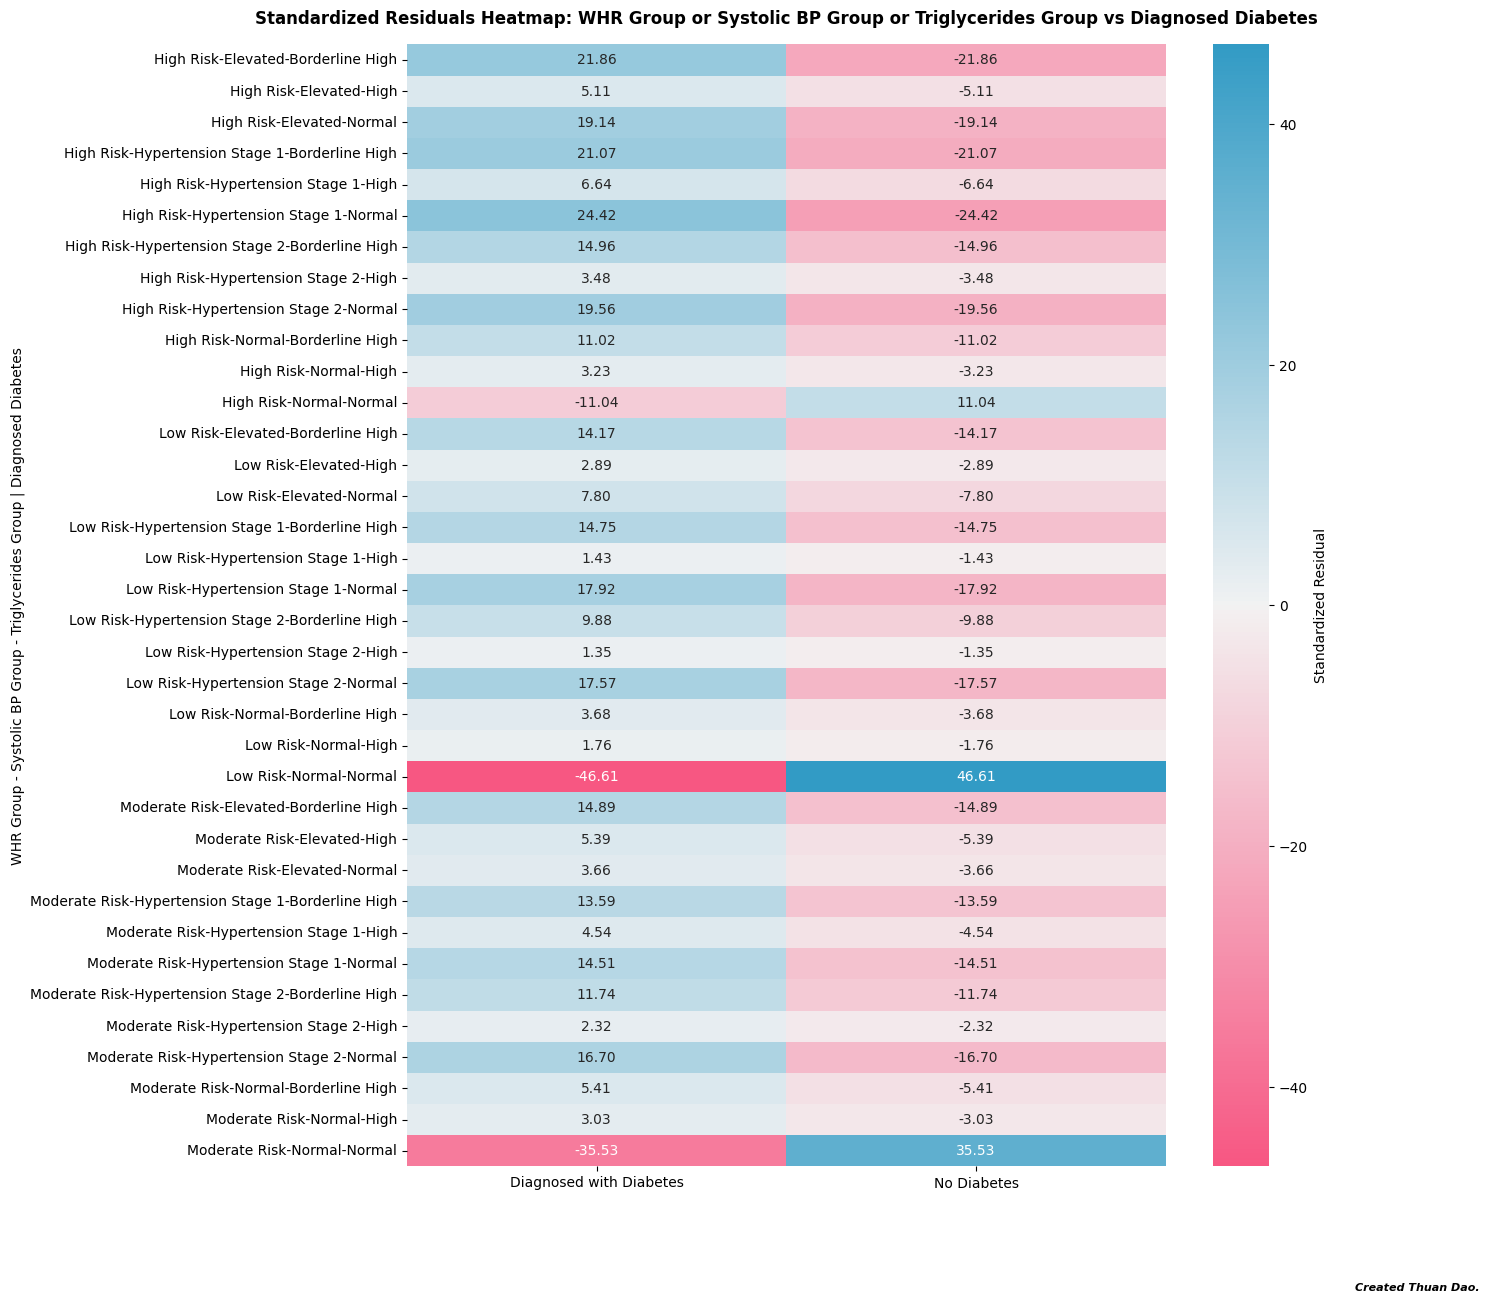

In [28]:
print("[i] Computing percentage table by WHR Group × Systolic BP Group × Triglycerides Group...")
df_group = pd.crosstab(
    [df_plot["whr_group"], df_plot["sbp_group"], df_plot["tg_group"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (WHR Group × Systolic BP Group × Triglycerides Group) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["whr_group"], df_plot["sbp_group"], df_plot["tg_group"]],
    df_plot["diagnosed_diabetes"],
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,13))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: WHR Group or Systolic BP Group or Triglycerides Group vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("WHR Group - Systolic BP Group - Triglycerides Group | Diagnosed Diabetes")
plt.xlabel("")
plt.text(2.5,40, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

**Systolic BP is the dominant predictor of diabetes.** <br>
**Triglycerides and waist-to-hip ratio add additional risk, but their effects become much stronger when BP** is elevated. <br>
**The highest diabetes likelihood occurs in groups with combined high BP, high triglycerides, and high WHR, as shown consistently in both heatmap residuals and logistic ORs.**

#### Is the relationship between age and diabetes stronger among individuals with hypertension or cardiovascular history?

[i] Computing percentage table by Age Group × Hypertension History × Cardiovascular History...


diagnosed_diabetes                                        Diagnosed with Diabetes  \
age_group    hypertension_history cardiovascular_history                            
Middle Adult 0                    0                                     57.476499   
                                  1                                     61.966988   
             1                    0                                     58.077921   
                                  1                                     61.619190   
Older Adult  0                    0                                     65.360265   
                                  1                                     68.702474   
             1                    0                                     66.417163   
                                  1                                     68.152275   
Senior       0                    0                                     76.199191   
                                  1                                     77.844311   
             1                    0                                     76.151601   
                                  1                                     77.861635   
Young Adult  0                    0                                     48.437766   
                                  1                                     52.272727   
             1                    0                                     49.351221   
                                  1                                     35.000000   

diagnosed_diabetes                                        No Diabetes  
age_group    hypertension_history cardiovascular_history               
Middle Adult 0                    0                         42.523501  
                                  1                         38.033012  
             1                    0                         41.922079  
                                  1                         38.380810  
Older Adult  0                    0                         34.639735  
                                  1                         31.297526  
             1                    0                         33.582837  
                                  1                         31.847725  
Senior       0                    0                         23.800809  
                                  1                         22.155689  
             1                    0                         23.848399  
                                  1                         22.138365  
Young Adult  0                    0                         51.562234  
                                  1                         47.727273  
             1                    0                         50.648779  
                                  1                         65.000000

[i] Running Chi-Square Test for combined factors (Age Group × Hypertension History × Cardiovascular History) vs Diagnosed Diabetes...
[i] Chi2: 16121.2398
[i] dof: 15
[i] p-value: 0.000000


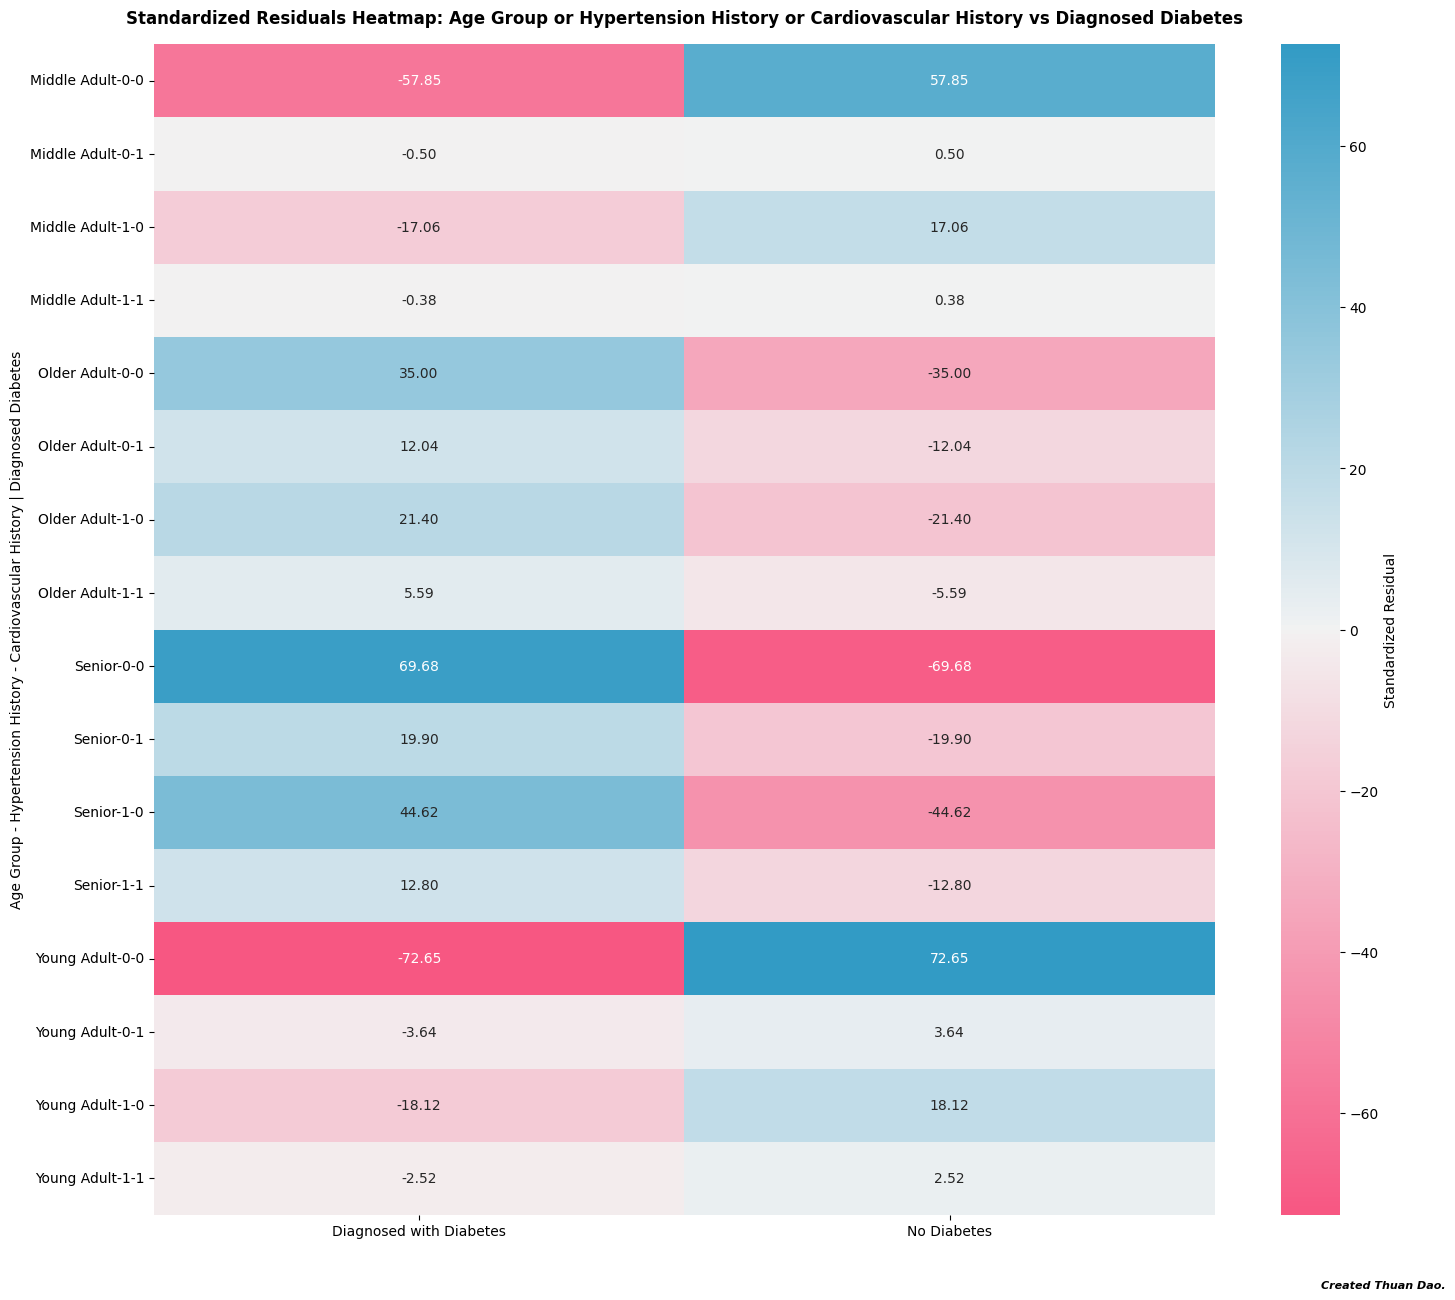

In [29]:
def age_group(x):
    if x < 35:
        return "Young Adult"
    elif x < 50:
        return "Middle Adult"
    elif x < 65:
        return "Older Adult"
    else:
        return "Senior"

df_plot["age_group"] = df_plot["age"].apply(age_group)

print("[i] Computing percentage table by Age Group × Hypertension History × Cardiovascular History...")
df_group = pd.crosstab(
    [df_plot["age_group"], df_plot["hypertension_history"], df_plot["cardiovascular_history"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Age Group × Hypertension History × Cardiovascular History) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["age_group"], df_plot["hypertension_history"], df_plot["cardiovascular_history"]],
    df_plot["diagnosed_diabetes"],
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,13))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Age Group or Hypertension History or Cardiovascular History vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Age Group - Hypertension History - Cardiovascular History | Diagnosed Diabetes")
plt.xlabel("")
plt.text(2.2,17, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Answer:**

Analysis of the standardized residual heatmap shows that **age is a significantly stronger predictor of diabetes among individuals with hypertension or cardiovascular history** compared with those without these conditions.

* **Older Adult (50–64)** and **Senior (65+)** groups with a history of hypertension and/or cardiovascular disease display **large positive residuals**, indicating that diabetes occurs **far more frequently than statistically expected** in these populations.
* Individuals in the same age groups **without** hypertension or cardiovascular disease show **much smaller or even negative residuals**, suggesting a substantially weaker relationship between age and diabetes when no comorbidities are present.
* Among the two comorbidity types, **hypertension amplifies the age–diabetes association more strongly** than cardiovascular history alone, although both contribute to elevated risk.
* In contrast, **younger adults (19–49) without comorbidities** show markedly negative residuals, confirming that diabetes is **far less common than expected** in these groups and highlighting how comorbidities magnify the effect of age.

**Overall, the findings indicate a clear interaction effect: Age-related risk of diabetes rises sharply when hypertension or cardiovascular disease is present, making comorbidities key amplifiers of the age–diabetes relationship.**

#### Does elevated LDL strengthen the risk effect of high BMI or high waist-to-hip ratio?

In [30]:
def ldl_group(x):
    if x < 100:
        return "Optimal"
    elif x < 130:
        return "Near Optimal"
    elif x < 160:
        return "Borderline High"
    elif x < 190:
        return "High"
    else:
        return "Very High"

df_plot["ldl_group"] = df_plot["ldl_cholesterol"].apply(ldl_group)

print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula="diagnosed_diabetes_binary ~ ldl_group + whr_group",
    data=df_plot
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.658085
         Iterations 5
                               Logit Regression Results                              
Dep. Variable:     diagnosed_diabetes_binary   No. Observations:               700000
Model:                                 Logit   Df Residuals:                   699993
Method:                                  MLE   Df Model:                            6
Date:                       Wed, 03 Dec 2025   Pseudo R-squ.:                0.006555
Time:                               11:43:47   Log-Likelihood:            -4.6066e+05
converged:                              True   LL-Null:                   -4.6370e+05
Covariance Type:                   nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

[i] Computing percentage table by BMI Group × WHR Group...


ldl_group                  Borderline High      High  Near Optimal    Optimal  \
bmi_group   whr_group                                                           
Normal      High Risk             4.842386  0.065470     44.789040  50.303104   
            Low Risk              4.061517  0.044640     42.396446  53.495957   
            Moderate Risk         3.962033  0.045080     42.713316  53.278319   
Obese       High Risk            17.061711  1.332398     55.206872  26.349930   
            Low Risk             17.150396  0.967458     54.881266  26.986221   
            Moderate Risk        17.556774  1.383451     54.753328  26.249021   
Overweight  High Risk             9.306073  0.250631     51.291738  39.149089   
            Low Risk              8.542195  0.185482     50.319068  40.951915   
            Moderate Risk         9.004193  0.220884     50.417851  40.355666   
Underweight High Risk             0.000000  0.000000     50.000000  50.000000   
            Low Risk              2.119747  0.000000     33.023429  64.856824   
            Moderate Risk         2.444988  0.000000     33.496333  64.058680   

ldl_group                  Very High  
bmi_group   whr_group                 
Normal      High Risk       0.000000  
            Low Risk        0.001440  
            Moderate Risk   0.001252  
Obese       High Risk       0.049088  
            Low Risk        0.014658  
            Moderate Risk   0.057426  
Overweight  High Risk       0.002469  
            Low Risk        0.001339  
            Moderate Risk   0.001407  
Underweight High Risk       0.000000  
            Low Risk        0.000000  
            Moderate Risk   0.000000

[i] Running Chi-Square Test for combined factors (BMI Group × WHR Group) vs LDL...
[i] Chi2: 27950.0401
[i] dof: 44
[i] p-value: 0.000000


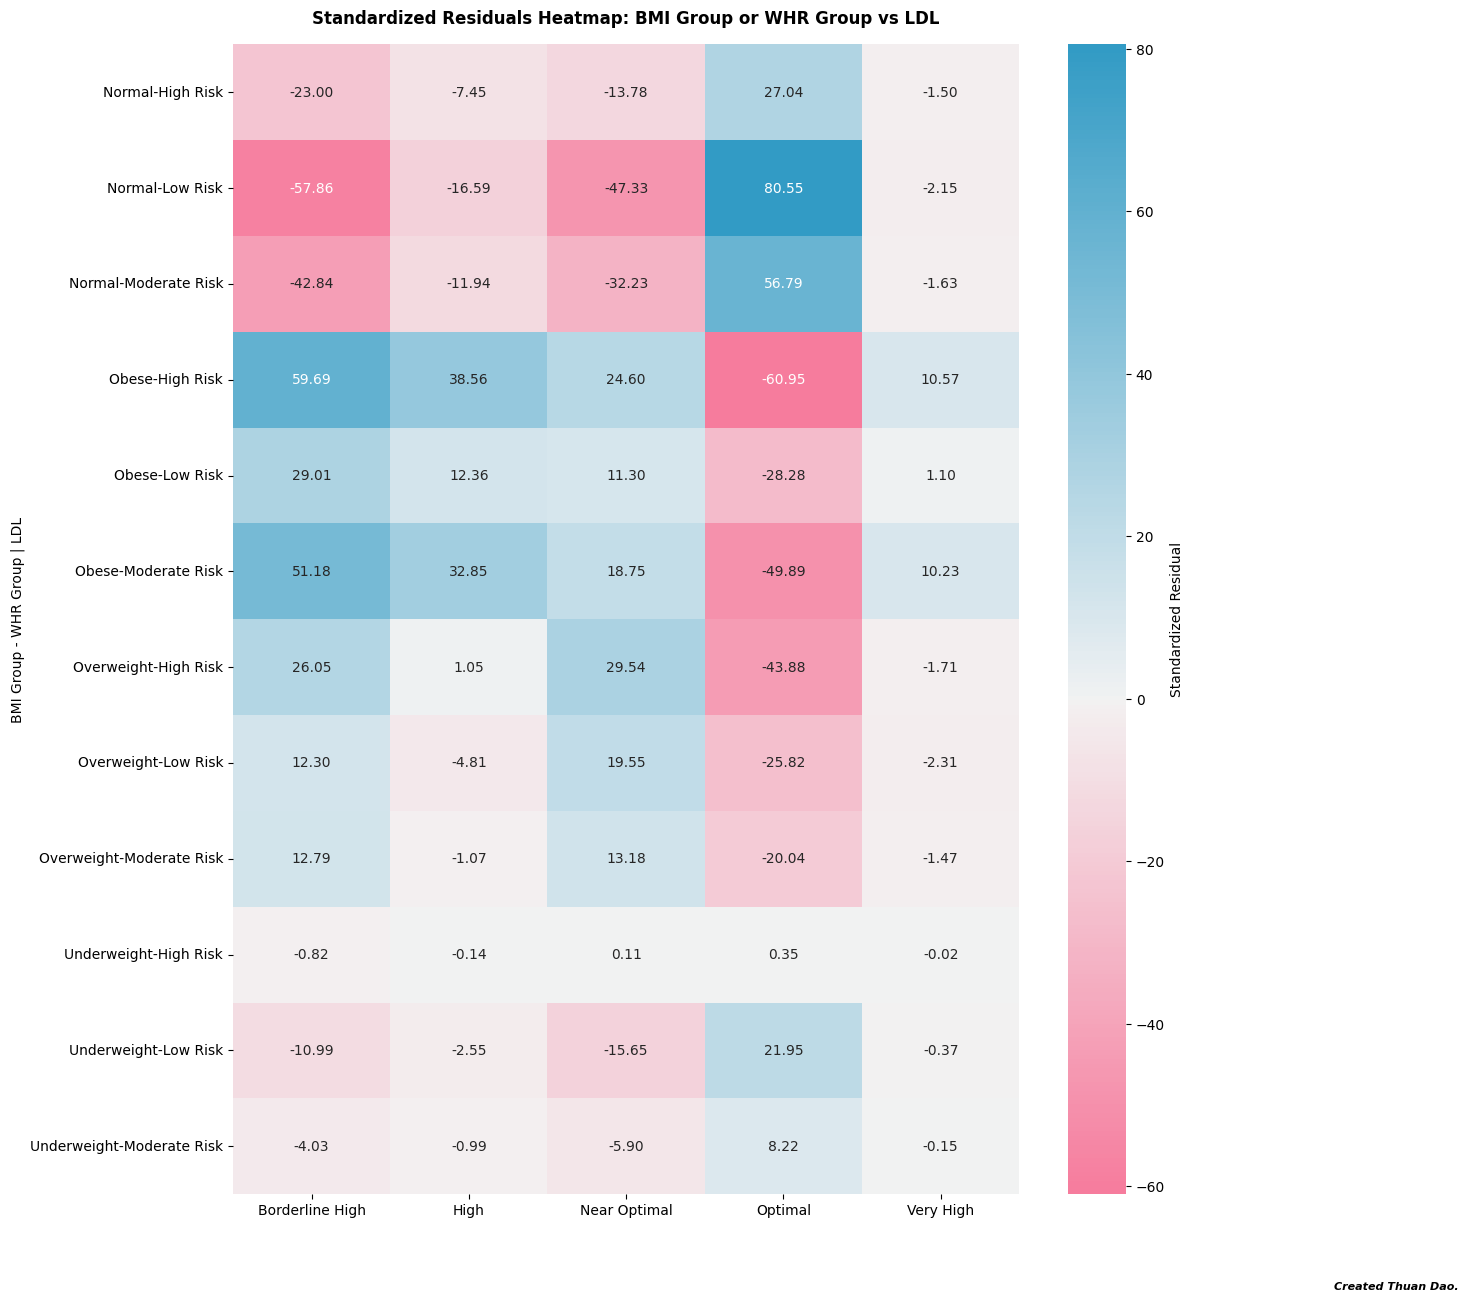

In [31]:
print("[i] Computing percentage table by BMI Group × WHR Group...")
df_group = pd.crosstab(
    [df_plot["bmi_group"], df_plot["whr_group"]],
    df_plot["ldl_group"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (BMI Group × WHR Group) vs LDL...")
contingency = pd.crosstab(
    [df_plot["bmi_group"], df_plot["whr_group"]],
    df_plot["ldl_group"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,13))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: BMI Group or WHR Group vs LDL", weight="bold", fontsize=12, pad=15)
plt.ylabel("BMI Group - WHR Group | LDL")
plt.xlabel("")
plt.text(7,13, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

* Elevated LDL substantially amplifies diabetes risk in individuals with high BMI.
* Obese and Overweight groups combined with High LDL show the strongest positive residuals and highest deviation from expected diabetes cases.
* WHR contributes modestly, but LDL–BMI interaction is the dominant high-risk pattern.**

### Lifestyle Patterns & Diabetes

#### Do people with low physical activity + high screen time show disproportionately higher diabetes prevalence?

[i] Computing percentage table by Physical Activity Group × Screen Time Group...


diagnosed_diabetes                       Diagnosed with Diabetes  No Diabetes
pa_group              screen_time_group                                      
Active                High                             40.608811    59.391189
                      Low                              39.484979    60.515021
                      Moderate                         38.485515    61.514485
                      Very High                        40.780347    59.219653
Highly Active         High                             34.494265    65.505735
                      Low                              32.824427    67.175573
                      Moderate                         32.132425    67.867575
                      Very High                        39.384846    60.615154
Inactive              High                             75.234209    24.765791
                      Low                              70.906801    29.093199
                      Moderate                         73.306910    26.693090
                      Very High                        76.742562    23.257438
Insufficiently Active High                             63.329145    36.670855
                      Low                              61.040694    38.959306
                      Moderate                         61.786793    38.213207
                      Very High                        64.072779    35.927221

[i] Running Chi-Square Test for combined factors (Physical Activity Group × Screen Time Group) vs Diagnosed Diabetes...
[i] Chi2: 13769.6576
[i] dof: 15
[i] p-value: 0.000000


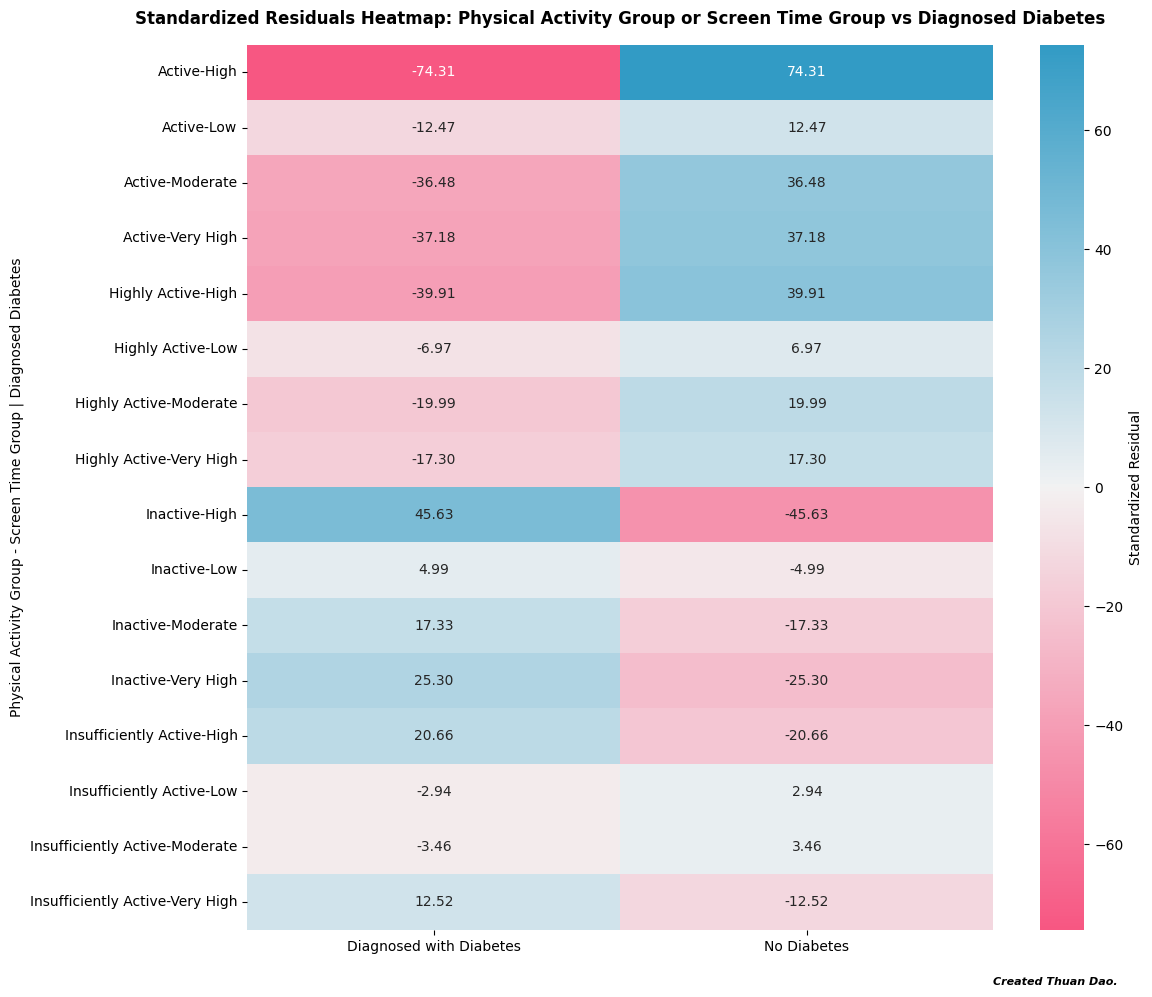

In [32]:
def pa_group(x):
    if x < 30:
        return "Inactive"
    elif x < 150:
        return "Insufficiently Active"
    elif x < 300:
        return "Active"
    else:
        return "Highly Active"

df_plot["pa_group"] = df_plot["physical_activity_minutes_per_week"].apply(pa_group)

def screen_time_group(x):
    if x < 2:
        return "Low"
    elif x < 4:
        return "Moderate"
    elif x < 8:
        return "High"
    else:
        return "Very High"

df_plot["screen_time_group"] = df_plot["screen_time_hours_per_day"].apply(screen_time_group)

print("[i] Computing percentage table by Physical Activity Group × Screen Time Group...")
df_group = pd.crosstab(
    [df_plot["pa_group"], df_plot["screen_time_group"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Physical Activity Group × Screen Time Group) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["pa_group"], df_plot["screen_time_group"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(12,10))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Physical Activity Group or Screen Time Group vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Physical Activity Group - Screen Time Group | Diagnosed Diabetes")
plt.xlabel("")
plt.text(2,17, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

* Individuals who are **inactive AND have high screen time** exhibit diabetes rates **far above expected levels** (residual ≈ +46).
* In contrast, highly active groups — even with high screen time — show **much lower-than-expected diabetes prevalence**.
* This indicates that **sedentary behaviour (low activity)** combined with **high screen exposure** creates a **synergistic risk pattern**, substantially magnifying diabetes likelihood.

#### Is diet score still insignificant when combined with physical activity and BMI?

In [33]:
def diet_group(x):
    if x < 3:
        return "Poor Diet"
    elif x < 6:
        return "Fair Diet"
    elif x < 8:
        return "Good Diet"
    else:
        return "Excellent Diet"

df_plot["diet_group"] = df_plot["diet_score"].apply(diet_group)

print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula="diagnosed_diabetes_binary ~ diet_group + pa_group + bmi_group",
    data=df_plot
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.648647
         Iterations 5
                               Logit Regression Results                              
Dep. Variable:     diagnosed_diabetes_binary   No. Observations:               700000
Model:                                 Logit   Df Residuals:                   699990
Method:                                  MLE   Df Model:                            9
Date:                       Wed, 03 Dec 2025   Pseudo R-squ.:                 0.02080
Time:                               11:43:57   Log-Likelihood:            -4.5405e+05
converged:                              True   LL-Null:                   -4.6370e+05
Covariance Type:                   nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

[i] Computing percentage table by Diet Group × Physical Activity Group × BMI Group...


diagnosed_diabetes                                Diagnosed with Diabetes  \
diet_group     pa_group              bmi_group                              
Excellent Diet Active                Normal                     34.295416   
                                     Obese                      38.738739   
                                     Overweight                 35.873472   
                                     Underweight                28.703704   
               Highly Active         Normal                     30.585683   
...                                                                   ...   
Poor Diet      Inactive              Overweight                 77.927928   
               Insufficiently Active Normal                     61.761252   
                                     Obese                      75.930851   
                                     Overweight                 67.990358   
                                     Underweight                53.846154   

diagnosed_diabetes                                No Diabetes  
diet_group     pa_group              bmi_group                 
Excellent Diet Active                Normal         65.704584  
                                     Obese          61.261261  
                                     Overweight     64.126528  
                                     Underweight    71.296296  
               Highly Active         Normal         69.414317  
...                                                       ...  
Poor Diet      Inactive              Overweight     22.072072  
               Insufficiently Active Normal         38.238748  
                                     Obese          24.069149  
                                     Overweight     32.009642  
                                     Underweight    46.153846  

[62 rows x 2 columns]

[i] Running Chi-Square Test for combined factors (Diet Group × Physical Activity Group × BMI Group) vs Diagnosed Diabetes...
[i] Chi2: 19513.9305
[i] dof: 61
[i] p-value: 0.000000


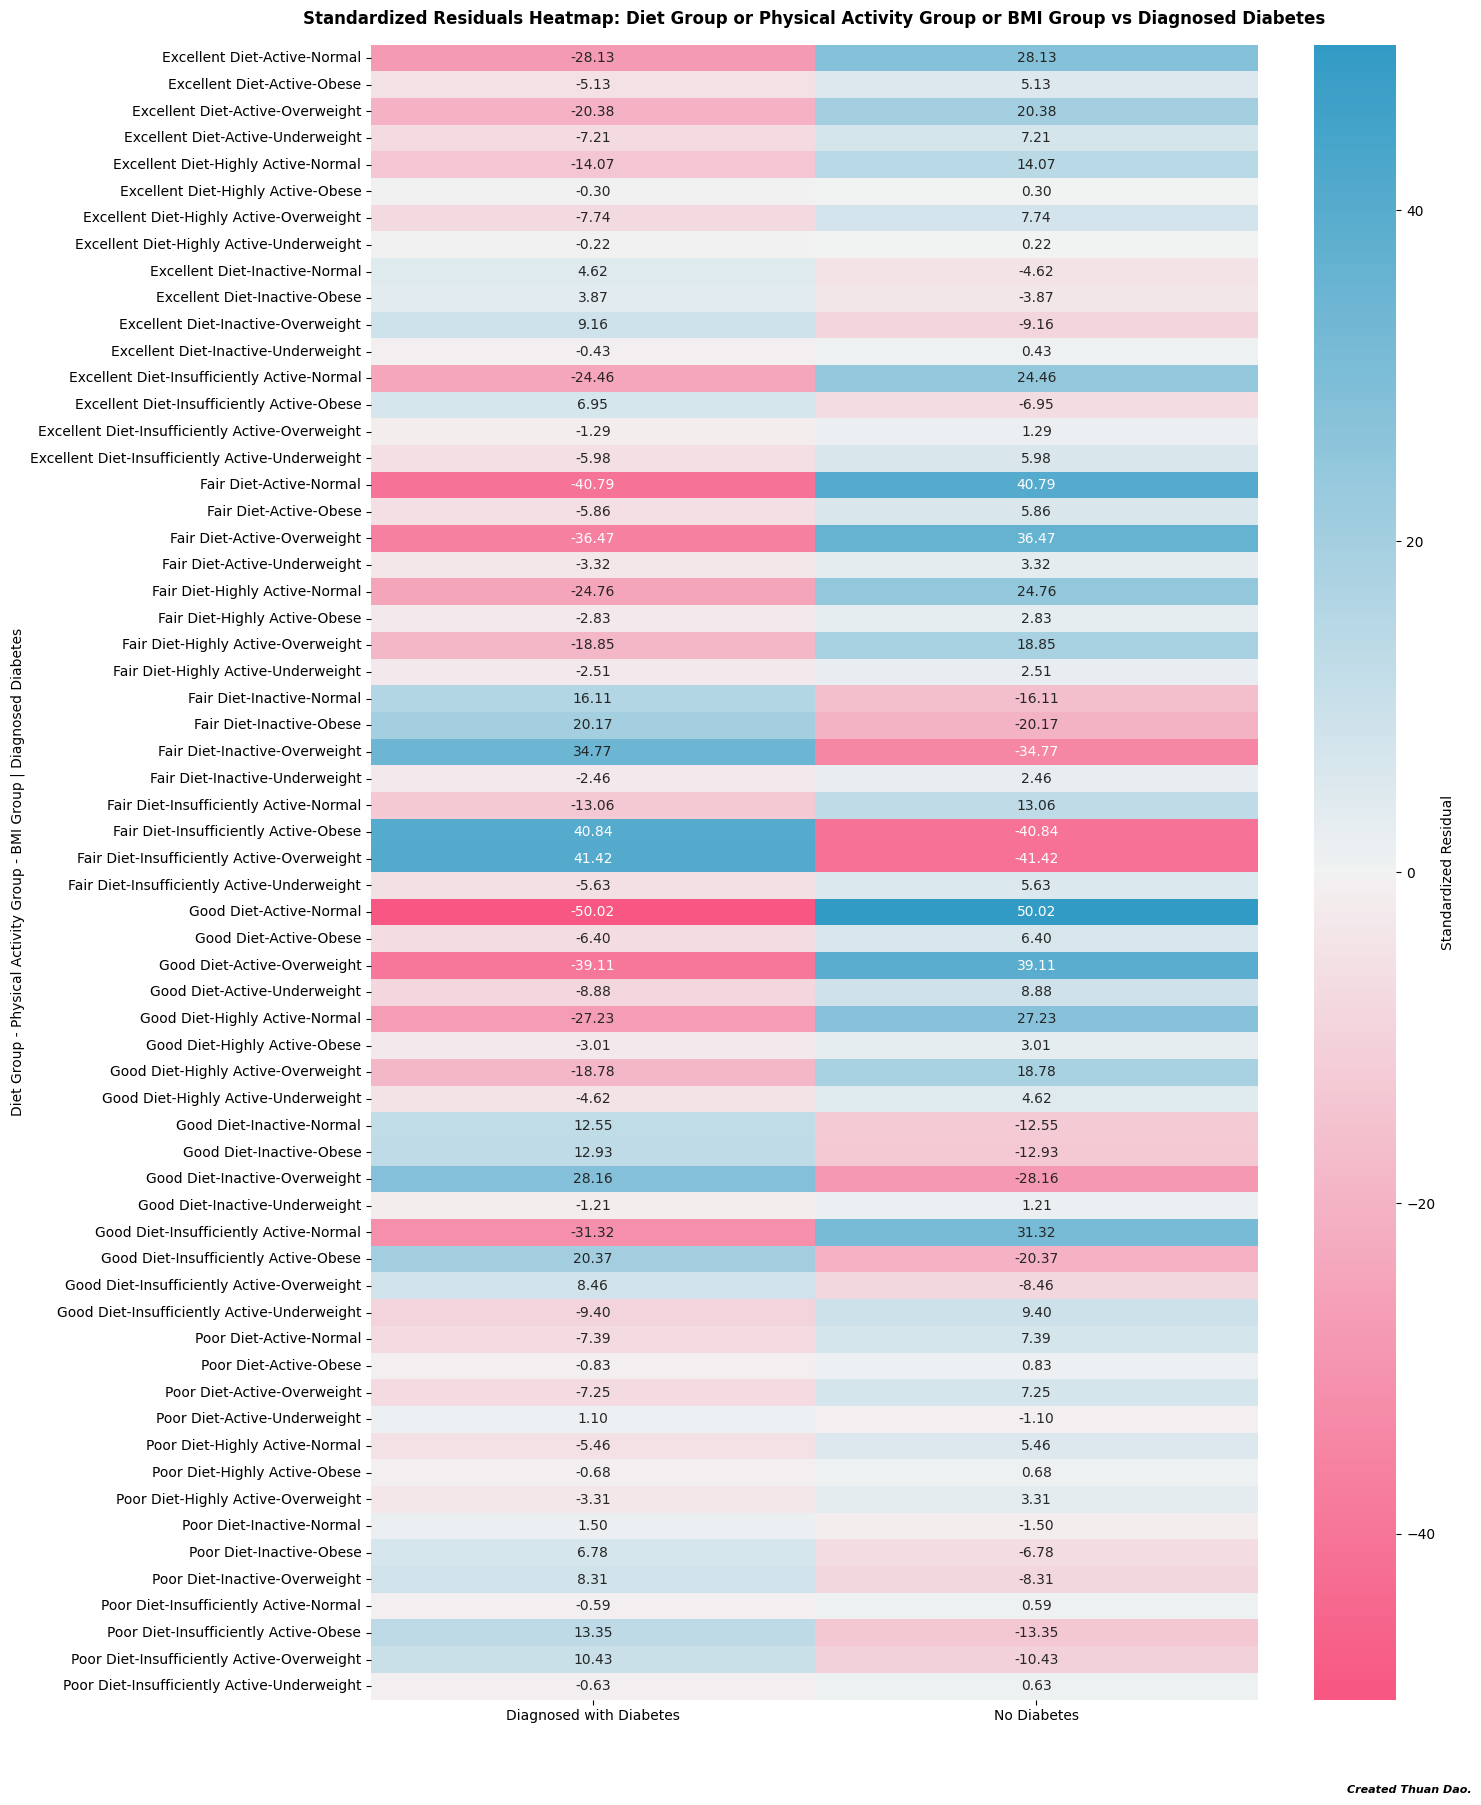

In [34]:
print("[i] Computing percentage table by Diet Group × Physical Activity Group × BMI Group...")
df_group = pd.crosstab(
    [df_plot["diet_group"], df_plot["pa_group"], df_plot["bmi_group"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Diet Group × Physical Activity Group × BMI Group) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["diet_group"], df_plot["pa_group"], df_plot["bmi_group"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,18))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Diet Group or Physical Activity Group or BMI Group vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Diet Group - Physical Activity Group - BMI Group | Diagnosed Diabetes")
plt.xlabel("")
plt.text(2.2,65.5, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

**Diet score is no longer “insignificant” once combined with physical activity and BMI, but it remains a secondary predictor.**

* Poor and Fair diet are associated with **20–30% higher diabetes odds** compared with Excellent diet.
* However, **inactivity (OR ≈ 4.3)** and **obesity (OR ≈ 1.8)** have much stronger effects, and the heatmap shows that high-risk cells are dominated by low activity and high BMI, with diet only modestly modifying this risk.

#### Does alcohol consumption moderate the relationship between BMI and diabetes risk?

[i] Computing percentage table by Alcohol Consumption per Week × BMI Group...


diagnosed_diabetes                        Diagnosed with Diabetes  No Diabetes
alcohol_consumption_per_week bmi_group                                        
1                            Normal                     56.767422    43.232578
                             Obese                      72.211055    27.788945
                             Overweight                 63.856601    36.143399
                             Underweight                46.731707    53.268293
2                            Normal                     57.748187    42.251813
                             Obese                      72.679269    27.320731
                             Overweight                 64.750535    35.249465
                             Underweight                46.808511    53.191489
3                            Normal                     57.376001    42.623999
                             Obese                      71.733856    28.266144
                             Overweight                 64.729368    35.270632
                             Underweight                49.512987    50.487013
4                            Normal                     58.426361    41.573639
                             Obese                      73.755047    26.244953
                             Overweight                 64.904537    35.095463
                             Underweight                49.480969    50.519031
>=5                          Normal                     56.486797    43.513203
                             Obese                      69.951140    30.048860
                             Overweight                 63.086599    36.913401
                             Underweight                49.473684    50.526316

[i] Running Chi-Square Test for combined factors (Alcohol Consumption per Week × BMI Group) vs Diagnosed Diabetes...
[i] Chi2: 6127.1224
[i] dof: 19
[i] p-value: 0.000000


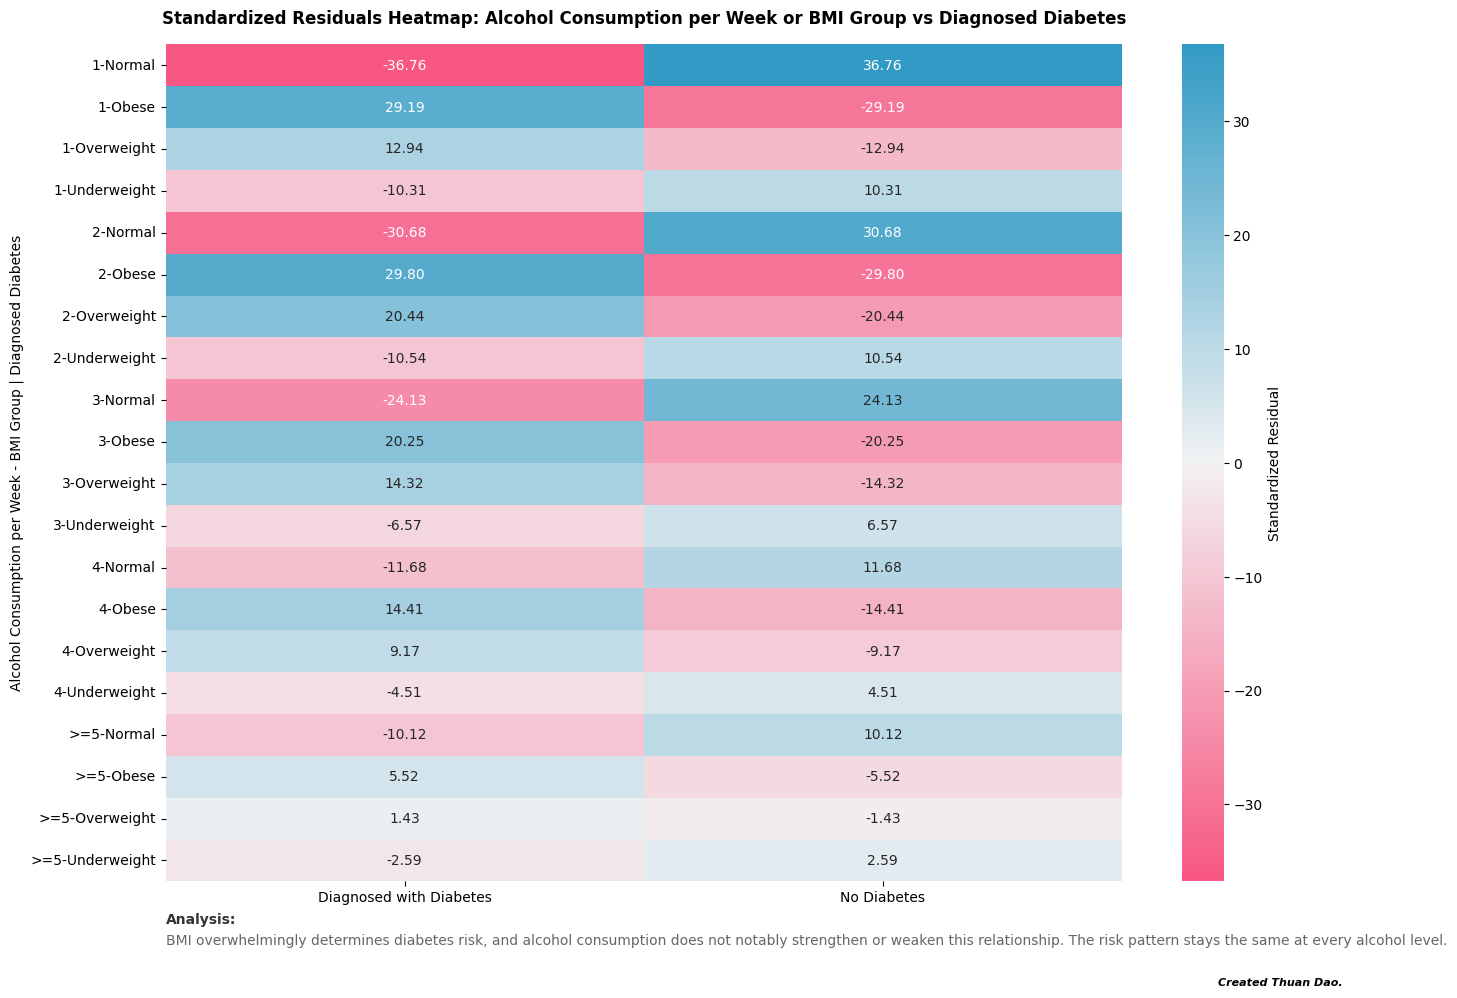

In [35]:
print("[i] Computing percentage table by Alcohol Consumption per Week × BMI Group...")
df_group = pd.crosstab(
    [df_plot["alcohol_consumption_per_week"], df_plot["bmi_group"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Alcohol Consumption per Week × BMI Group) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["alcohol_consumption_per_week"], df_plot["bmi_group"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,10))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Alcohol Consumption per Week or BMI Group vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Alcohol Consumption per Week - BMI Group | Diagnosed Diabetes")
plt.xlabel("")
plt.text(0, 21, "Analysis:", fontsize=10, fontweight="bold", color="#333")
plt.text(0, 21.5, "BMI overwhelmingly determines diabetes risk, and alcohol consumption does not notably strengthen or weaken this relationship. The risk pattern stays the same at every alcohol level.", 
         fontsize=10, color="#666", wrap=True)
plt.text(2.2,22.5, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

#### Are sleep hours meaningful only when viewed together with stress-related indicators such as work status or heart rate?

[i] Computing percentage table by Sleep Group × HR Group × Employment Status...


diagnosed_diabetes                               Diagnosed with Diabetes  \
sleep_group       hr_group    employment_status                            
Long Sleep        Bradycardia Employed                         61.108386   
                              Retired                          59.957173   
                              Student                          58.088235   
                              Unemployed                       53.826531   
                  Elevated    Employed                         65.280918   
                              Retired                          61.706629   
                              Student                          65.957447   
                              Unemployed                       68.296796   
                  Normal      Employed                         62.346314   
                              Retired                          62.044559   
                              Student                          62.959021   
                              Unemployed                       62.322275   
Recommended Sleep Bradycardia Employed                         59.369697   
                              Retired                          58.698617   
                              Student                          60.831510   
                              Unemployed                       59.230769   
                  Elevated    Employed                         64.633586   
                              Retired                          63.990657   
                              Student                          63.502455   
                              Unemployed                       62.794811   
                  Normal      Employed                         62.479766   
                              Retired                          61.937176   
                              Student                          62.307627   
                              Unemployed                       62.326975   
                  Tachycardia Employed                        100.000000   
Short Sleep       Bradycardia Employed                         60.106900   
                              Retired                          60.043197   
                              Student                          52.287582   
                              Unemployed                       56.334232   
                  Elevated    Employed                         63.841808   
                              Retired                          62.679788   
                              Student                          60.194175   
                              Unemployed                       63.565891   
                  Normal      Employed                         62.351188   
                              Retired                          60.782491   
                              Student                          61.114116   
                              Unemployed                       62.605379   

diagnosed_diabetes                               No Diabetes  
sleep_group       hr_group    employment_status               
Long Sleep        Bradycardia Employed             38.891614  
                              Retired              40.042827  
                              Student              41.911765  
                              Unemployed           46.173469  
                  Elevated    Employed             34.719082  
                              Retired              38.293371  
                              Student              34.042553  
                              Unemployed           31.703204  
                  Normal      Employed             37.653686  
                              Retired              37.955441  
                              Student              37.040979  
                              Unemployed           37.677725  
Recommended Sleep Bradycardia Employed             40.630303  
                              Retired              41.301383  
                           

[i] Running Chi-Square Test for combined factors (Sleep Group × HR Group × Employment Status) vs Diagnosed Diabetes...
[i] Chi2: 323.2417
[i] dof: 36
[i] p-value: 0.000000


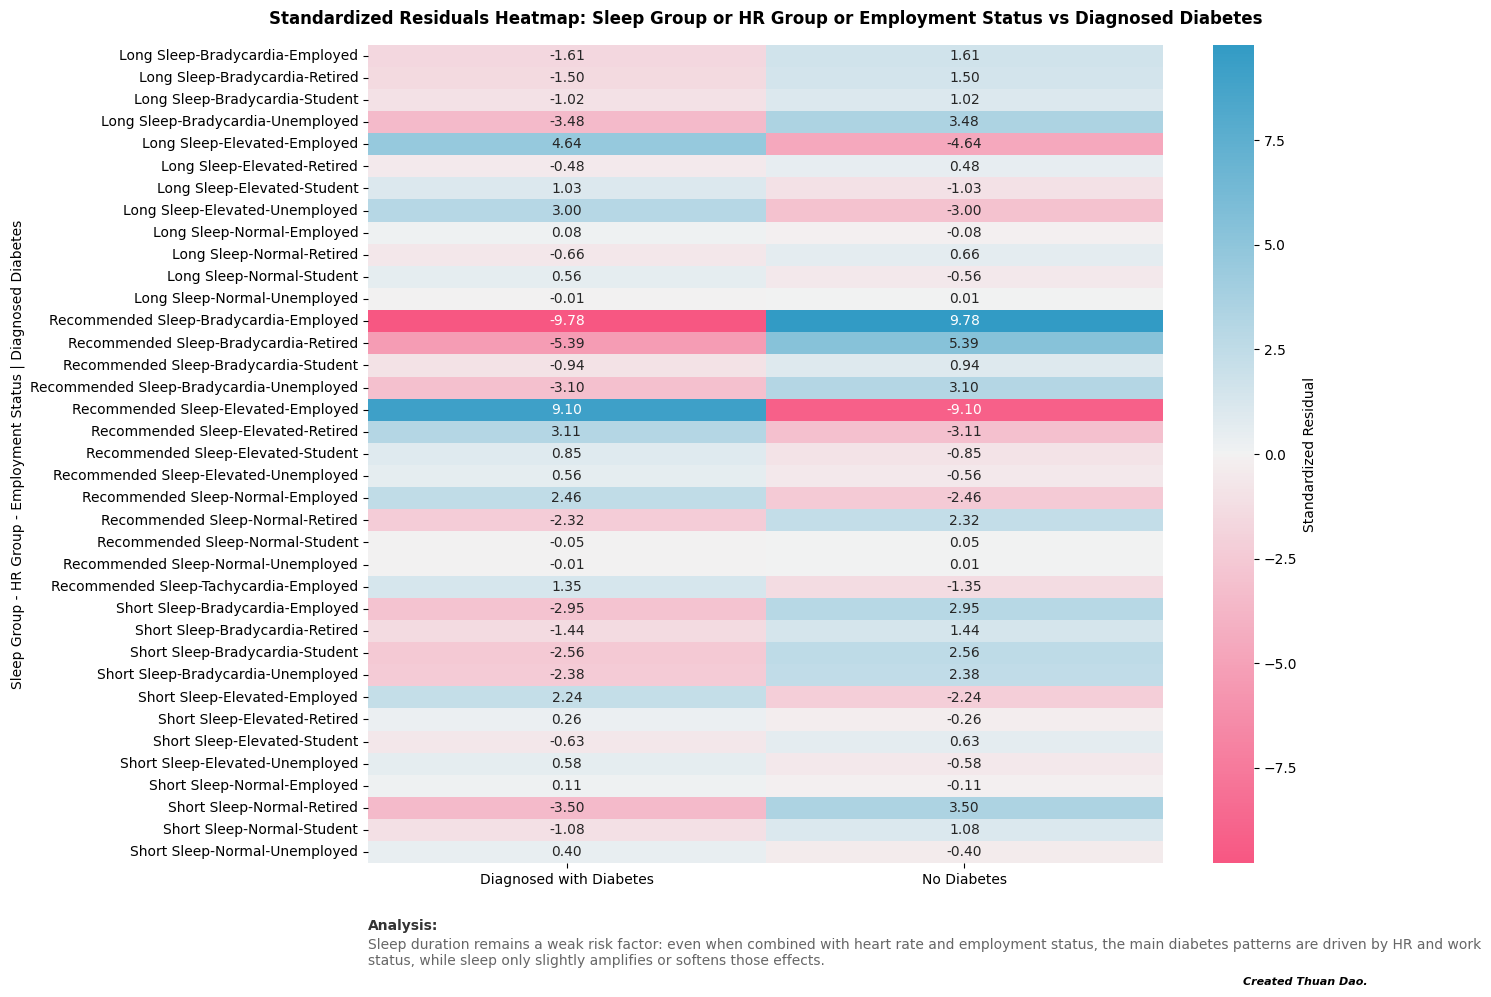

In [36]:
def hr_group(x):
    if x < 60:
        return "Bradycardia"
    elif x < 80:
        return "Normal"
    elif x < 100:
        return "Elevated"
    else:
        return "Tachycardia"

df_plot["hr_group"] = df_plot["heart_rate"].apply(hr_group)

def sleep_group(x):
    if x < 6:
        return "Short Sleep"
    elif x <= 8:
        return "Recommended Sleep"
    else:
        return "Long Sleep"

df_plot["sleep_group"] = df_plot["sleep_hours_per_day"].apply(sleep_group)


print("[i] Computing percentage table by Sleep Group × HR Group × Employment Status...")
df_group = pd.crosstab(
    [df_plot["sleep_group"], df_plot["hr_group"], df_plot["employment_status"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Sleep Group × HR Group × Employment Status) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["sleep_group"], df_plot["hr_group"], df_plot["employment_status"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,10))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Sleep Group or HR Group or Employment Status vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Sleep Group - HR Group - Employment Status | Diagnosed Diabetes")
plt.xlabel("")
plt.text(0, 40, "Analysis:", fontsize=10, fontweight="bold", color="#333")
plt.text(0, 41.5, "Sleep duration remains a weak risk factor: even when combined with heart rate and employment status, the main diabetes patterns are driven by HR and work status, while sleep only slightly amplifies or softens those effects.", 
         fontsize=10, color="#666", wrap=True)
plt.text(2.2,42.5, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

### Socioeconomic Factors Interaction

#### How does income level interact with ethnicity in shaping diabetes prevalence?

[i] Computing percentage table by Income Level × Ethnicity...


diagnosed_diabetes      Diagnosed with Diabetes  No Diabetes
income_level ethnicity                                      
High         Asian                    62.640264    37.359736
             Black                    63.233025    36.766975
             Hispanic                 60.997804    39.002196
             Other                    65.110565    34.889435
             White                    62.414770    37.585230
Low          Asian                    63.992307    36.007693
             Black                    62.639563    37.360437
             Hispanic                 62.032592    37.967408
             Other                    62.812927    37.187073
             White                    63.336701    36.663299
Lower-Middle Asian                    62.660060    37.339940
             Black                    62.992620    37.007380
             Hispanic                 62.349912    37.650088
             Other                    63.667118    36.332882
             White                    62.671002    37.328998
Middle       Asian                    63.188968    36.811032
             Black                    62.071706    37.928294
             Hispanic                 61.190383    38.809617
             Other                    63.657345    36.342655
             White                    62.044177    37.955823
Upper-Middle Asian                    61.631693    38.368307
             Black                    61.983555    38.016445
             Hispanic                 61.436026    38.563974
             Other                    63.693219    36.306781
             White                    62.258212    37.741788

[i] Running Chi-Square Test for combined factors (Income Level × Ethnicity) vs Diagnosed Diabetes...
[i] Chi2: 112.9946
[i] dof: 24
[i] p-value: 0.000000


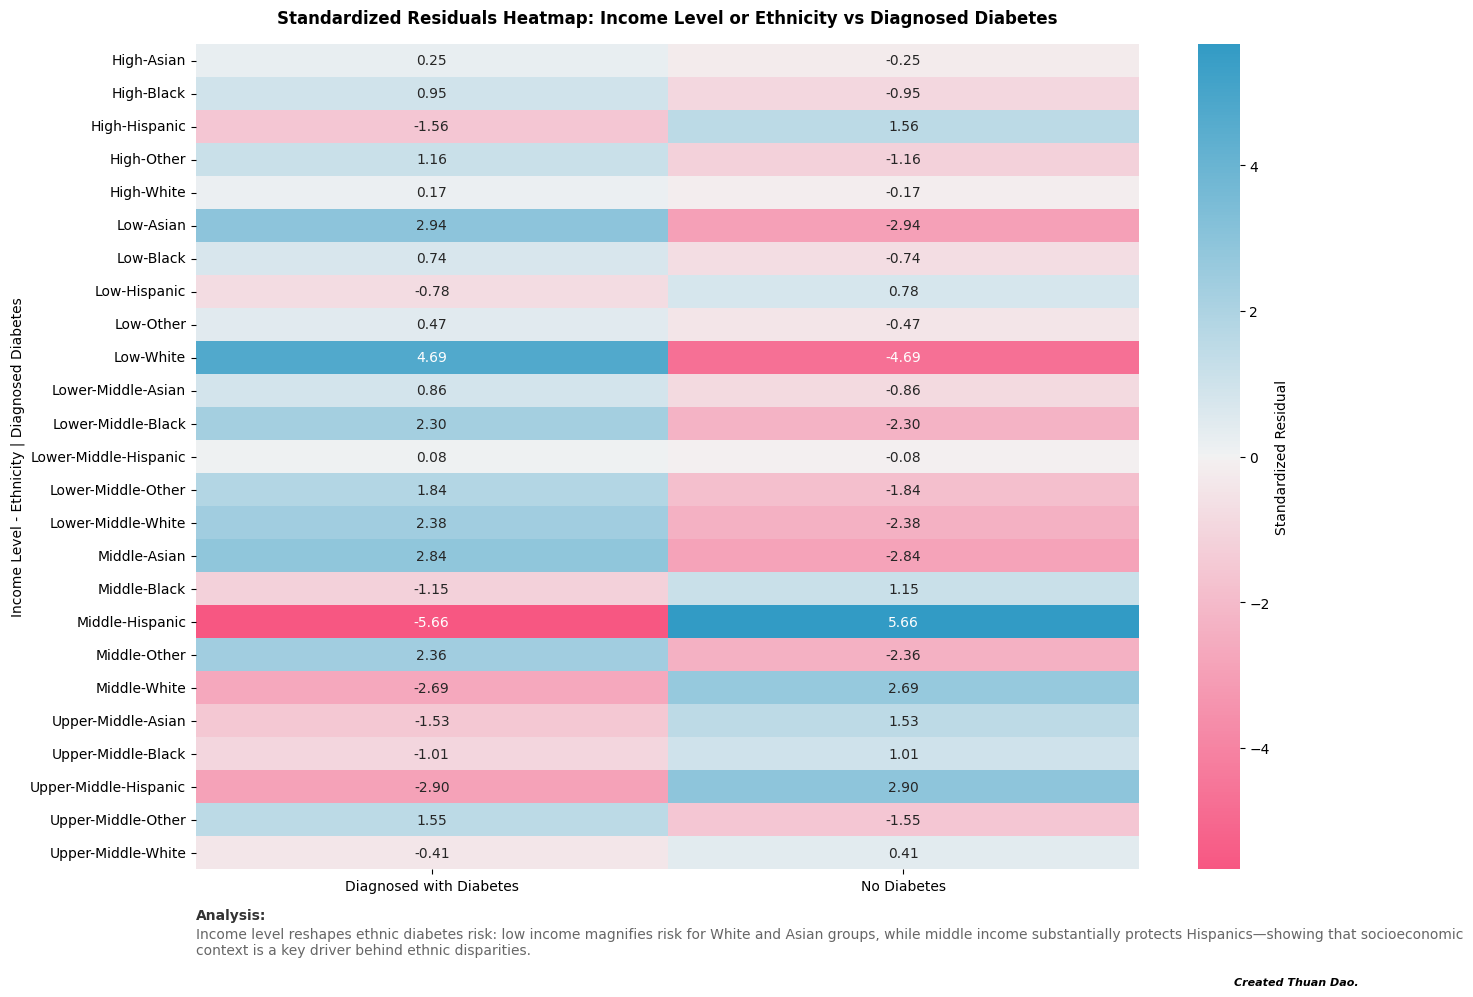

In [37]:
print("[i] Computing percentage table by Income Level × Ethnicity...")
df_group = pd.crosstab(
    [df_plot["income_level"], df_plot["ethnicity"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Income Level × Ethnicity) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["income_level"], df_plot["ethnicity"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,10))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Income Level or Ethnicity vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Income Level - Ethnicity | Diagnosed Diabetes")
plt.xlabel("")
plt.text(0, 26.5, "Analysis:", fontsize=10, fontweight="bold", color="#333")
plt.text(0, 27.5, "Income level reshapes ethnic diabetes risk: low income magnifies risk for White and Asian groups, while middle income substantially protects Hispanics—showing that socioeconomic context is a key driver behind ethnic disparities.", 
         fontsize=10, color="#666", wrap=True)
plt.text(2.2,28.5, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

#### Does education level influence diabetes risk differently across income groups?

In [38]:
print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula="diagnosed_diabetes_binary ~ education_level + income_level",
    data=df_plot
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.662364
         Iterations 4
                               Logit Regression Results                              
Dep. Variable:     diagnosed_diabetes_binary   No. Observations:               700000
Model:                                 Logit   Df Residuals:                   699992
Method:                                  MLE   Df Model:                            7
Date:                       Wed, 03 Dec 2025   Pseudo R-squ.:               9.626e-05
Time:                               11:44:06   Log-Likelihood:            -4.6365e+05
converged:                              True   LL-Null:                   -4.6370e+05
Covariance Type:                   nonrobust   LLR p-value:                 1.750e-16
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

[i] Computing percentage table by Education Level × Income Level...


diagnosed_diabetes            Diagnosed with Diabetes  No Diabetes
education_level income_level                                      
Graduate        High                        62.106918    37.893082
                Low                         63.097453    36.902547
                Lower-Middle                63.281413    36.718587
                Middle                      62.485087    37.514913
                Upper-Middle                62.197115    37.802885
Highschool      High                        62.417140    37.582860
                Low                         63.136879    36.863121
                Lower-Middle                62.291904    37.708096
                Middle                      61.794926    38.205074
                Upper-Middle                62.028132    37.971868
No formal       High                        62.849873    37.150127
                Low                         63.298168    36.701832
                Lower-Middle                64.966622    35.033378
                Middle                      63.262643    36.737357
                Upper-Middle                62.865090    37.134910
Postgraduate    High                        62.813576    37.186424
                Low                         62.337532    37.662468
                Lower-Middle                61.956357    38.043643
                Middle                      61.331866    38.668134
                Upper-Middle                61.405742    38.594258

[i] Running Chi-Square Test for combined factors (Education Level × Income Level) vs Diagnosed Diabetes...
[i] Chi2: 102.4113
[i] dof: 19
[i] p-value: 0.000000


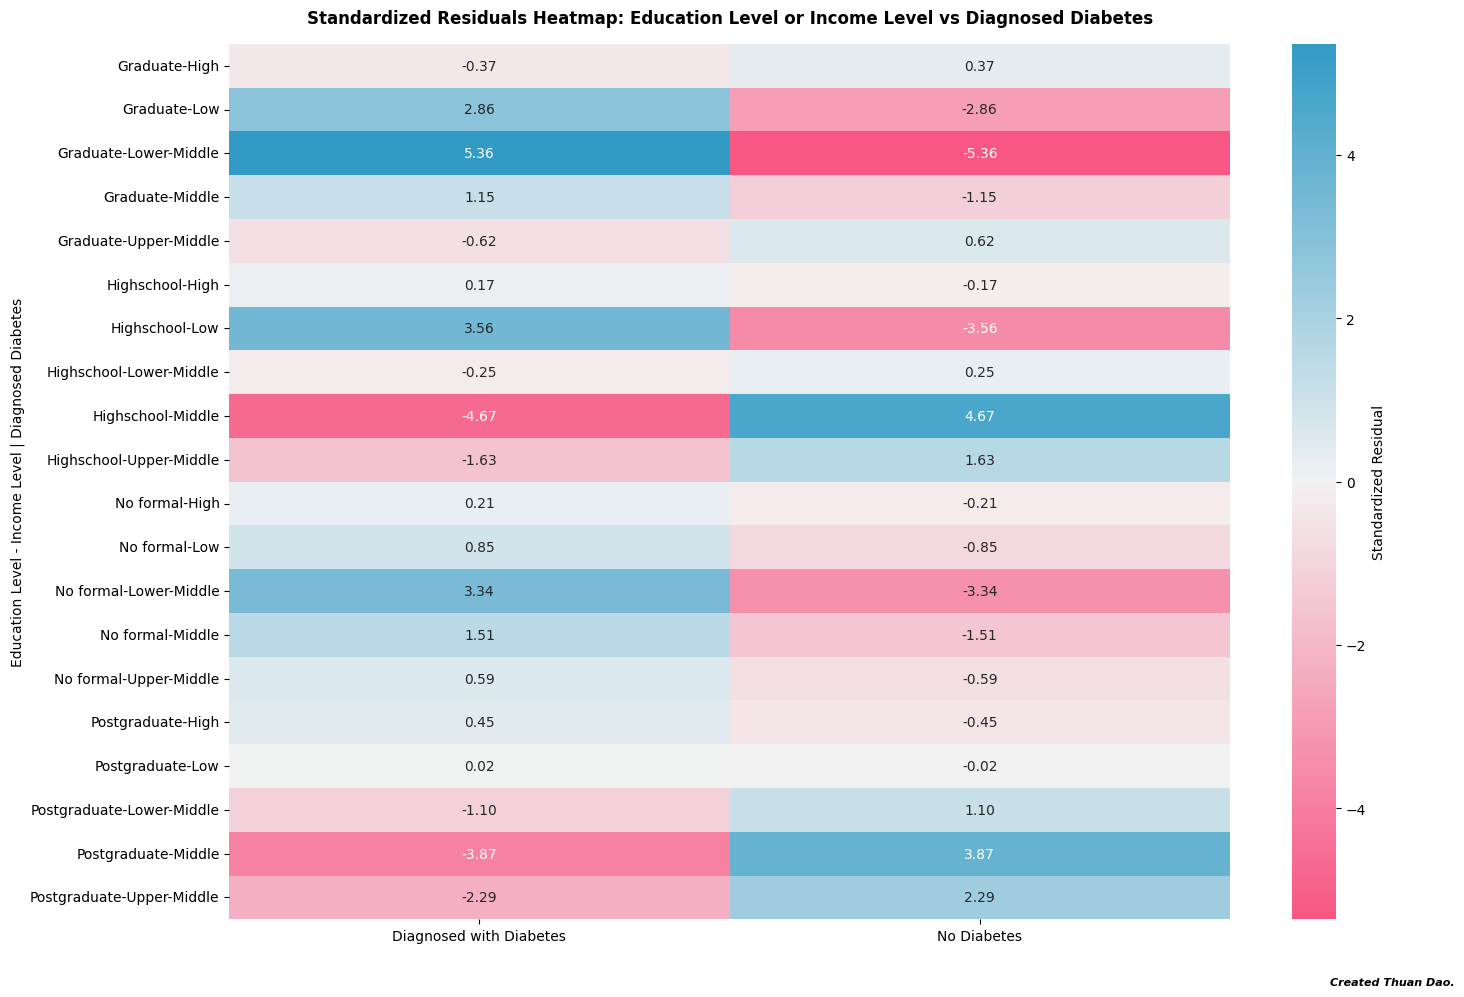

In [39]:
print("[i] Computing percentage table by Education Level × Income Level...")
df_group = pd.crosstab(
    [df_plot["education_level"], df_plot["income_level"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Education Level × Income Level) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["education_level"], df_plot["income_level"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,10))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Education Level or Income Level vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Education Level - Income Level | Diagnosed Diabetes")
plt.xlabel("")
plt.text(2.2,21.5, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

***Education shows slightly higher diabetes risk in low-income groups, but this pattern weakens at higher income levels. However, logistic regression indicates that both income and education have only minimal independent effects, suggesting that the interaction between them is weak.***

#### Are unemployed individuals at higher diabetes risk only within certain income tiers?

In [40]:
print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula="diagnosed_diabetes_binary ~ employment_status + income_level",
    data=df_plot
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.662384
         Iterations 4
                               Logit Regression Results                              
Dep. Variable:     diagnosed_diabetes_binary   No. Observations:               700000
Model:                                 Logit   Df Residuals:                   699992
Method:                                  MLE   Df Model:                            7
Date:                       Wed, 03 Dec 2025   Pseudo R-squ.:               6.617e-05
Time:                               11:44:09   Log-Likelihood:            -4.6367e+05
converged:                              True   LL-Null:                   -4.6370e+05
Covariance Type:                   nonrobust   LLR p-value:                 8.044e-11
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

[i] Computing percentage table by Employment Level × Income Level...


diagnosed_diabetes              Diagnosed with Diabetes  No Diabetes
employment_status income_level                                      
Employed          High                        62.630546    37.369454
                  Low                         63.096733    36.903267
                  Lower-Middle                62.906573    37.093427
                  Middle                      62.170890    37.829110
                  Upper-Middle                62.066909    37.933091
Retired           High                        61.753406    38.246594
                  Low                         62.597293    37.402707
                  Lower-Middle                61.766801    38.233199
                  Middle                      61.750184    38.249816
                  Upper-Middle                61.465249    38.534751
Student           High                        59.375000    40.625000
                  Low                         63.366788    36.633212
                  Lower-Middle                63.096523    36.903477
                  Middle                      61.760942    38.239058
                  Upper-Middle                61.321045    38.678955
Unemployed        High                        61.967213    38.032787
                  Low                         63.258340    36.741660
                  Lower-Middle                62.335262    37.664738
                  Middle                      61.297071    38.702929
                  Upper-Middle                63.404209    36.595791

[i] Running Chi-Square Test for combined factors (Employment Level × Income Level) vs Diagnosed Diabetes...
[i] Chi2: 80.9662
[i] dof: 19
[i] p-value: 0.000000


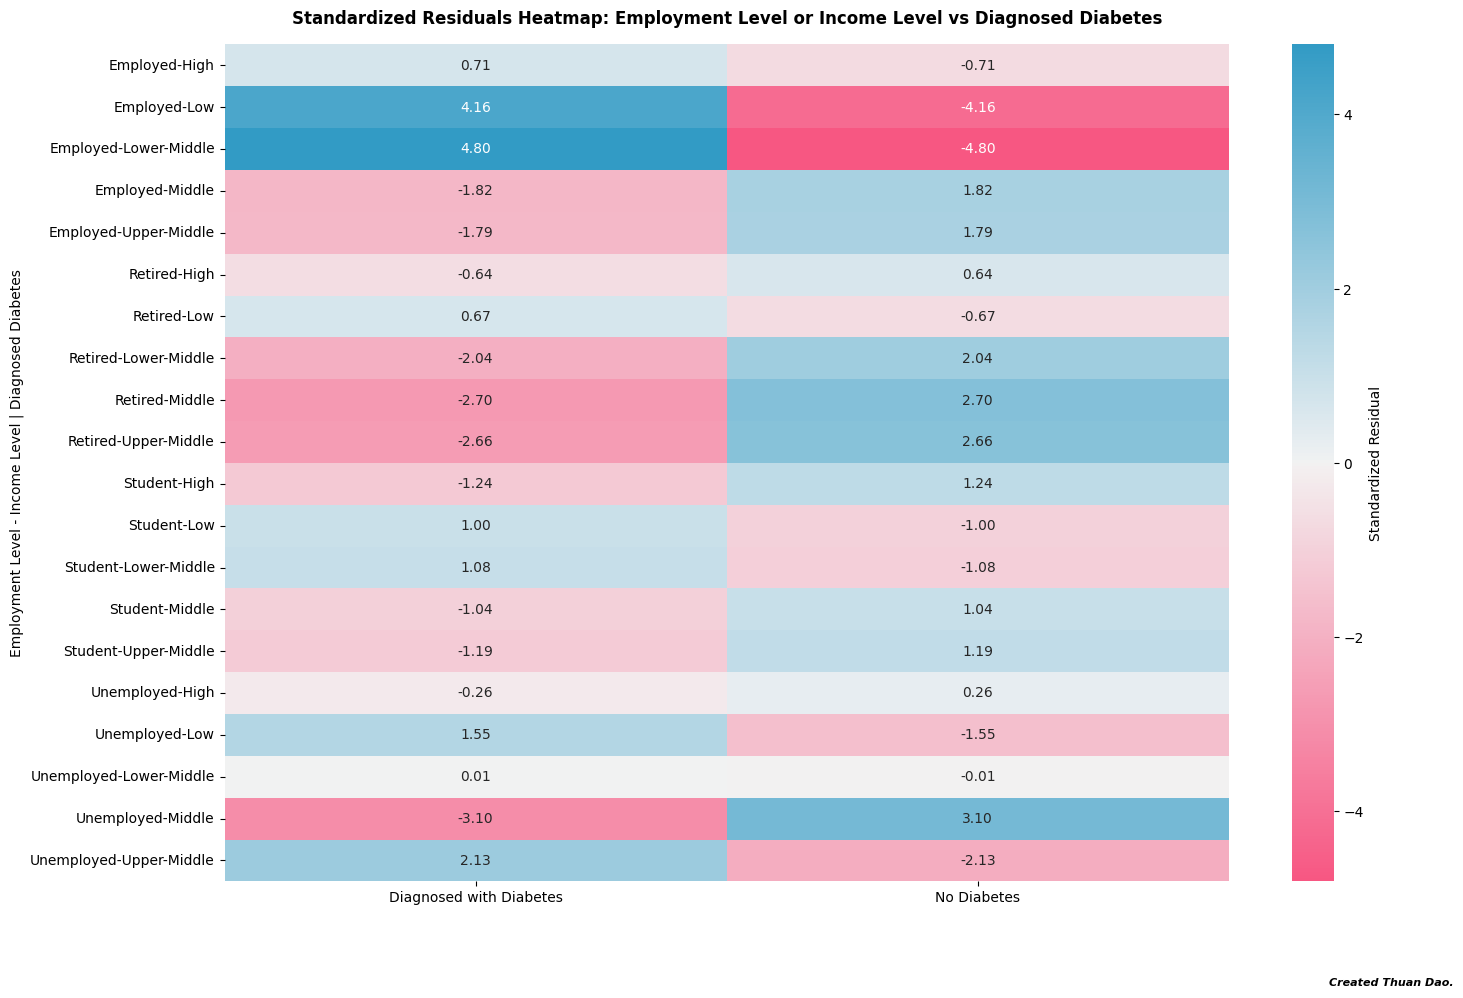

In [41]:
print("[i] Computing percentage table by Employment Level × Income Level...")
df_group = pd.crosstab(
    [df_plot["employment_status"], df_plot["income_level"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Employment Level × Income Level) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["employment_status"], df_plot["income_level"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,10))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Employment Level or Income Level vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Employment Level - Income Level | Diagnosed Diabetes")
plt.xlabel("")
plt.text(2.2,22.5, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

**No — unemployment is not universally associated with higher diabetes risk.** <br>
***Heatmap patterns show that elevated risk appears only among unemployed individuals in the low-income tier. In middle and higher income groups, unemployment does not increase diabetes prevalence, and regression confirms no significant independent effect overall.***

#### Does alcohol consumption vary systematically across education or income groups, and does this mediate diabetes?

[i] Computing percentage table by Alcohol Consumption per Week × Education Level × Income Level...


diagnosed_diabetes                                         Diagnosed with Diabetes  \
alcohol_consumption_per_week education_level income_level                            
1                            Graduate        High                        61.923937   
                                             Low                         62.894180   
                                             Lower-Middle                62.960771   
                                             Middle                      62.250053   
                                             Upper-Middle                61.560134   
...                                                                            ...   
>=5                          Postgraduate    High                        65.116279   
                                             Low                         60.784314   
                                             Lower-Middle                58.071749   
                                             Middle                      58.353511   
                                             Upper-Middle                59.932660   

diagnosed_diabetes                                         No Diabetes  
alcohol_consumption_per_week education_level income_level               
1                            Graduate        High            38.076063  
                                             Low             37.105820  
                                             Lower-Middle    37.039229  
                                             Middle          37.749947  
                                             Upper-Middle    38.439866  
...                                                                ...  
>=5                          Postgraduate    High            34.883721  
                                             Low             39.215686  
                                             Lower-Middle    41.928251  
                                             Middle          41.646489  
                                             Upper-Middle    40.067340  

[100 rows x 2 columns]

[i] Running Chi-Square Test for combined factors (Alcohol Consumption per Week × Education Level × Income Level) vs Diagnosed Diabetes...
[i] Chi2: 230.9831
[i] dof: 99
[i] p-value: 0.000000


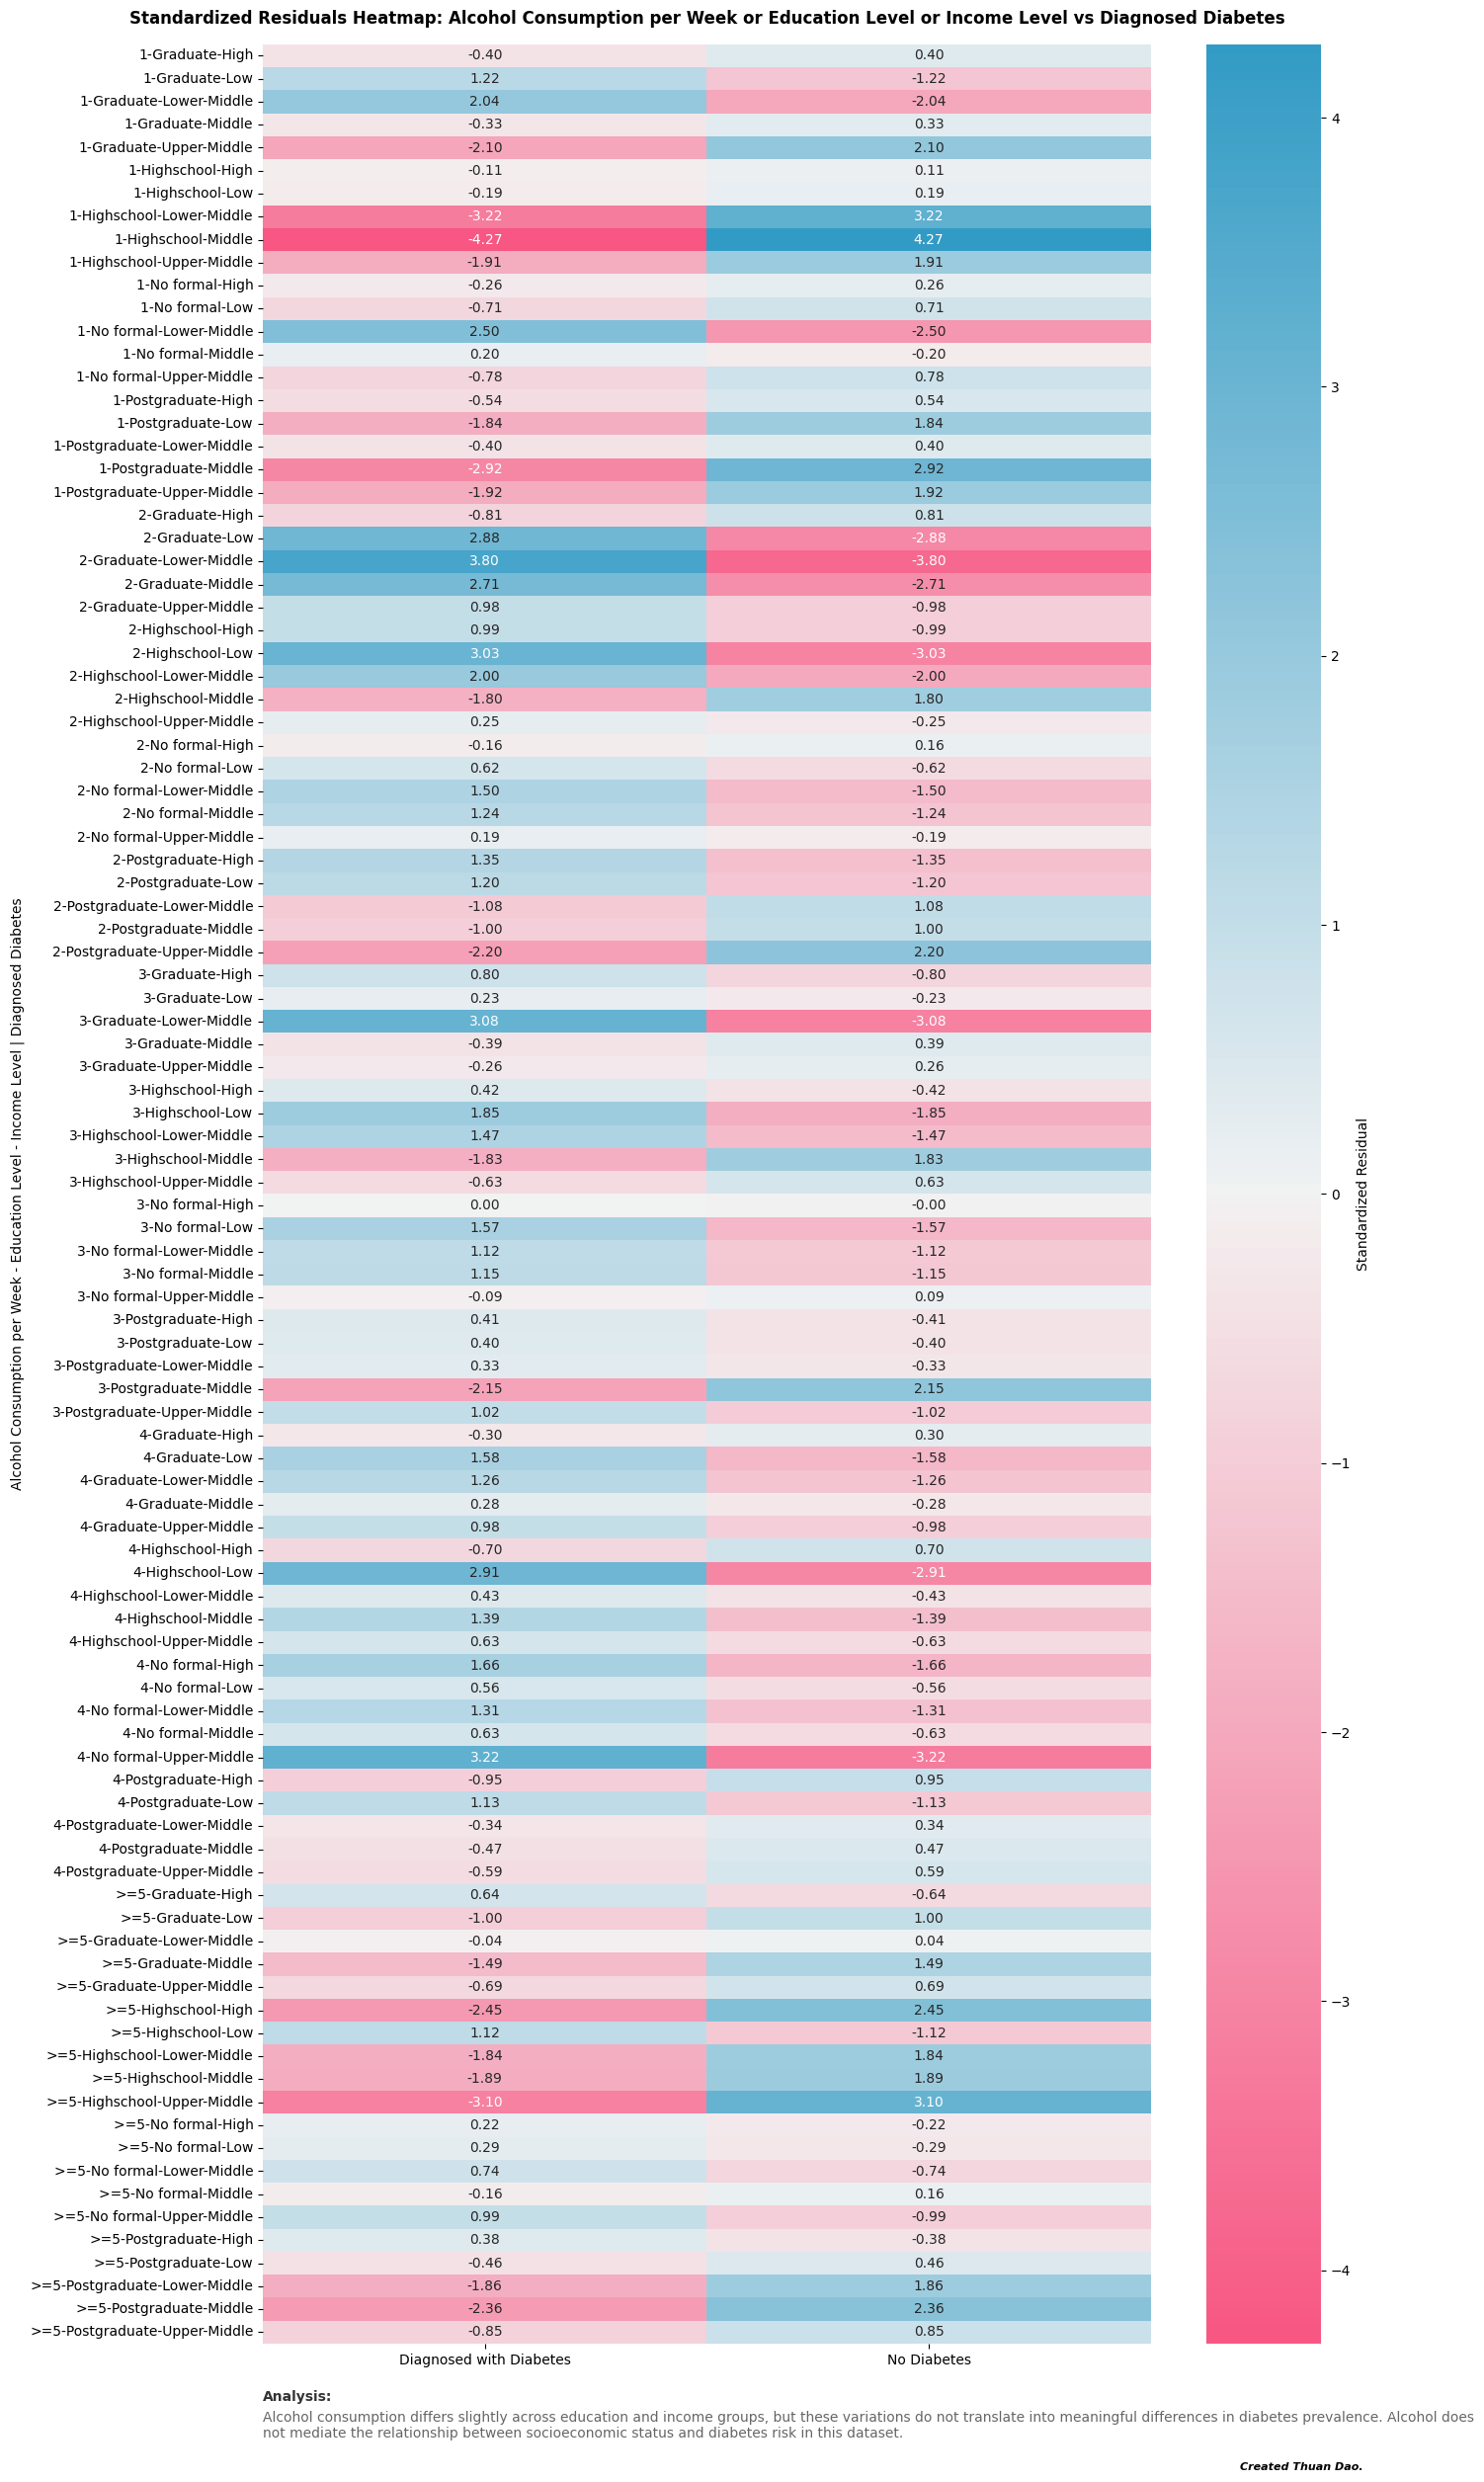

In [42]:
print("[i] Computing percentage table by Alcohol Consumption per Week × Education Level × Income Level...")
df_group = pd.crosstab(
    [df_plot["alcohol_consumption_per_week"], df_plot["education_level"], df_plot["income_level"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Alcohol Consumption per Week × Education Level × Income Level) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["alcohol_consumption_per_week"], df_plot["education_level"], df_plot["income_level"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(15,25))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Alcohol Consumption per Week or Education Level or Income Level vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Alcohol Consumption per Week - Education Level - Income Level | Diagnosed Diabetes")
plt.xlabel("")
plt.text(0, 102.5, "Analysis:", fontsize=10, fontweight="bold", color="#333")
plt.text(0, 104, "Alcohol consumption differs slightly across education and income groups, but these variations do not translate into meaningful differences in diabetes prevalence. Alcohol does not mediate the relationship between socioeconomic status and diabetes risk in this dataset.", 
         fontsize=10, color="#666", wrap=True)
plt.text(2.2,105.5, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

### Medical History Layering

#### Among individuals with hypertension, which numerical factors (BMI, LDL, triglycerides) are most predictive of diabetes?

In [43]:
df_hypertension = df_plot[df_plot["hypertension_history"] == 1]
print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula="diagnosed_diabetes_binary ~ bmi_group + ldl_group + tg_group",
    data=df_hypertension
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.637459
         Iterations 6
                               Logit Regression Results                              
Dep. Variable:     diagnosed_diabetes_binary   No. Observations:               127393
Model:                                 Logit   Df Residuals:                   127383
Method:                                  MLE   Df Model:                            9
Date:                       Wed, 03 Dec 2025   Pseudo R-squ.:                 0.01150
Time:                               11:44:15   Log-Likelihood:                -81208.
converged:                              True   LL-Null:                       -82153.
Covariance Type:                   nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

**Analysis:**

* Among hypertensive individuals, LDL levels and BMI are the strongest numerical predictors of diabetes.
* High LDL (OR ≈ 1.76) shows the highest risk increase, followed by obesity (OR ≈ 1.69).
* Triglycerides have only a weak and mostly non-significant contribution, indicating they are not major predictors within the hypertensive population.

#### Does cardiovascular history + high LDL produce a disproportionately higher diabetes rate?

[i] Computing percentage table by Cardiovascular History × High LDL...


diagnosed_diabetes                    Diagnosed with Diabetes  No Diabetes
hypertension_history ldl_group                                            
0                    Borderline High                70.288708    29.711292
                     High                           77.944664    22.055336
                     Very High                      78.571429    21.428571
1                    Borderline High                73.948052    26.051948
                     High                           84.914842    15.085158
                     Very High                      75.000000    25.000000

[i] Running Chi-Square Test for combined factors (Cardiovascular History × High LDL) vs Diagnosed Diabetes...
[i] Chi2: 126.3939
[i] dof: 5
[i] p-value: 0.000000


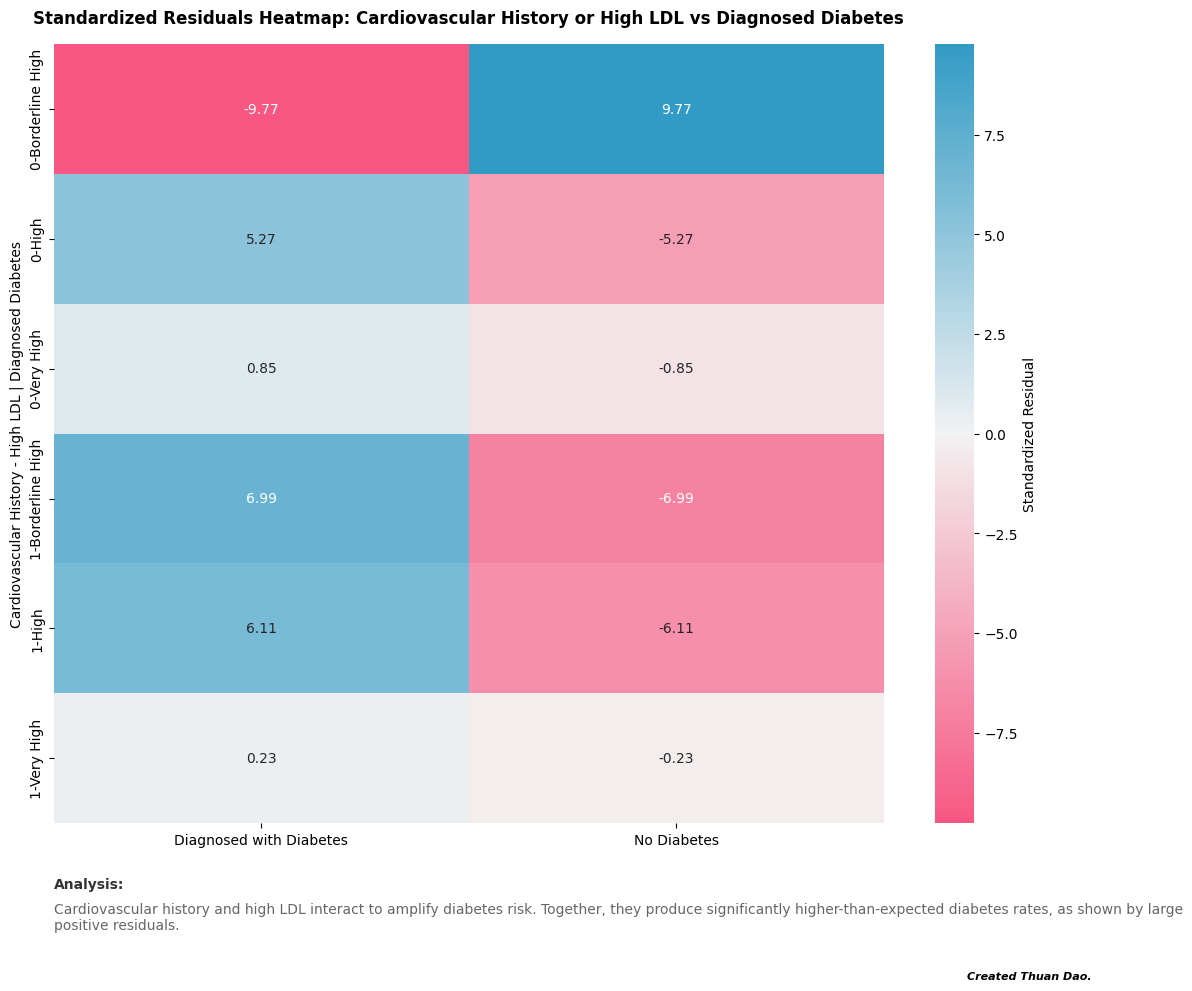

In [44]:
df_high_ldl = df_plot[df_plot["ldl_group"].isin(["Borderline High", "High", "Very High"])]
print("[i] Computing percentage table by Cardiovascular History × High LDL...")
df_group = pd.crosstab(
    [df_high_ldl["hypertension_history"], df_high_ldl["ldl_group"]],
    df_high_ldl["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Cardiovascular History × High LDL) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_high_ldl["hypertension_history"], df_high_ldl["ldl_group"]],
    df_high_ldl["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(12,10))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Cardiovascular History or High LDL vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Cardiovascular History - High LDL | Diagnosed Diabetes")
plt.xlabel("")
plt.text(0, 6.5, "Analysis:", fontsize=10, fontweight="bold", color="#333")
plt.text(0, 6.8, "Cardiovascular history and high LDL interact to amplify diabetes risk. Together, they produce significantly higher-than-expected diabetes rates, as shown by large positive residuals.", 
         fontsize=10, color="#666", wrap=True)
plt.text(2.2, 7.2, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

#### Is the impact of family history reduced or amplified among older individuals?

[i] Computing percentage table by Age Group × Family History Diabetes...


diagnosed_diabetes                   Diagnosed with Diabetes  No Diabetes
age_group   family_history_diabetes                                      
Older Adult 0                                      61.551781    38.448219
            1                                      88.606872    11.393128
Senior      0                                      73.141957    26.858043
            1                                      93.009943     6.990057

[i] Running Chi-Square Test for combined factors (Age Group × Family History Diabetes) vs Diagnosed Diabetes...
[i] Chi2: 17865.1068
[i] dof: 3
[i] p-value: 0.000000


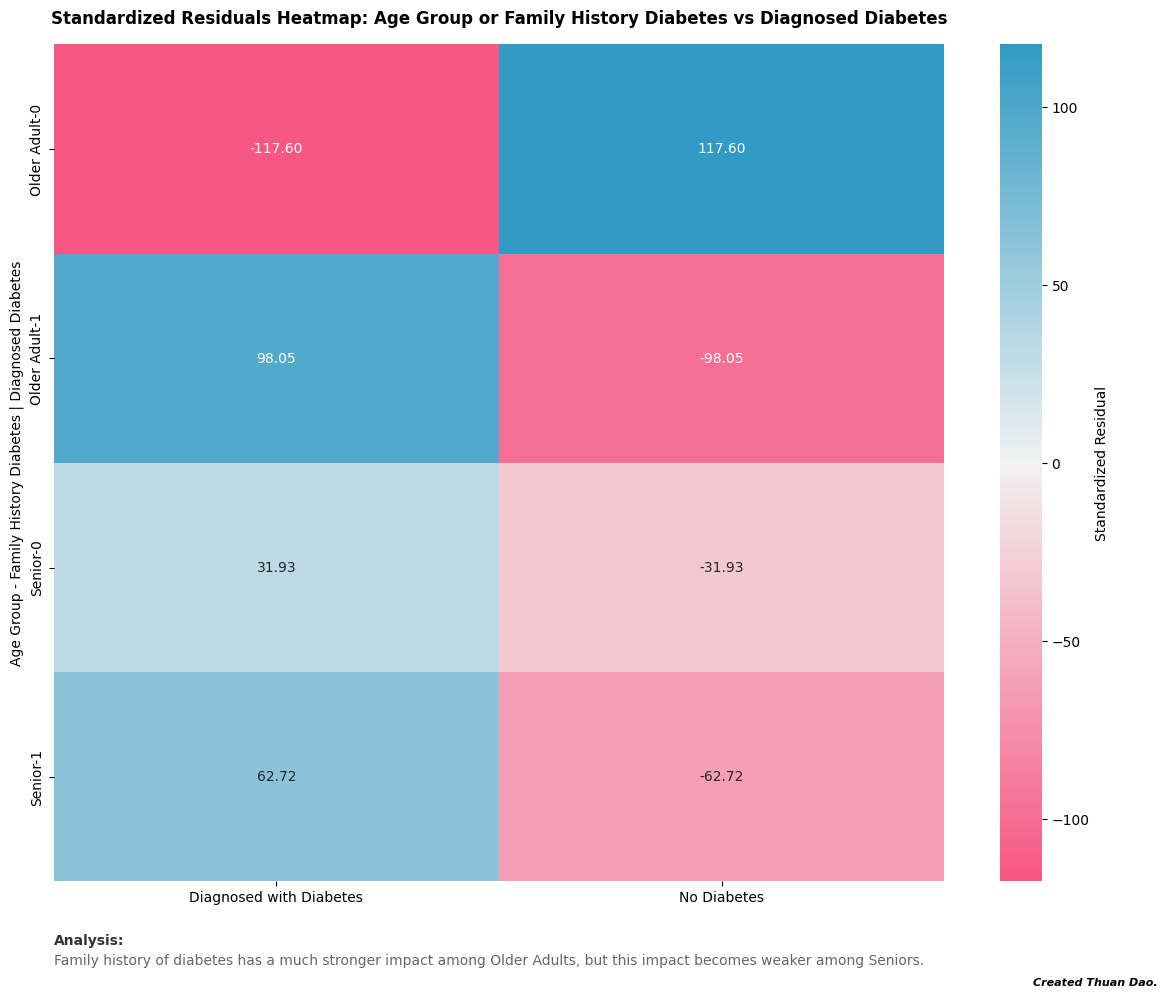

In [45]:
df_older = df_plot[df_plot["age_group"].isin(["Older Adult", "Senior"])]
print("[i] Computing percentage table by Age Group × Family History Diabetes...")
df_group = pd.crosstab(
    [df_older["age_group"], df_older["family_history_diabetes"]],
    df_older["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Age Group × Family History Diabetes) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_older["age_group"], df_older["family_history_diabetes"]],
    df_older["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)
# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(12,10))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Age Group or Family History Diabetes vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Age Group - Family History Diabetes | Diagnosed Diabetes")
plt.xlabel("")
plt.text(0, 4.3, "Analysis:", fontsize=10, fontweight="bold", color="#333")
plt.text(0, 4.4, "Family history of diabetes has a much stronger impact among Older Adults, but this impact becomes weaker among Seniors.", 
         fontsize=10, color="#666", wrap=True)
plt.text(2.2, 4.5, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

### Multi-Feature Behavioral Segmentation

#### Do younger individuals with high BMI behave similarly to older individuals with normal BMI in terms of diabetes risk?

In [46]:
df_plot["young_high_bmi"] = (
    (df_plot["age_group"] == "Young Adult") &
    (df_plot["bmi_group"].isin(["Overweight", "Obese"]))
).astype(int)

df_plot["older_normal_bmi"] = (
    (df_plot["age_group"].isin(["Older Adult", "Senior"])) &
    (df_plot["bmi_group"] == "Normal")
).astype(int)

print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula="diagnosed_diabetes_binary ~ young_high_bmi + older_normal_bmi",
    data=df_plot
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.661150
         Iterations 4
                               Logit Regression Results                              
Dep. Variable:     diagnosed_diabetes_binary   No. Observations:               700000
Model:                                 Logit   Df Residuals:                   699997
Method:                                  MLE   Df Model:                            2
Date:                       Wed, 03 Dec 2025   Pseudo R-squ.:                0.001928
Time:                               11:44:20   Log-Likelihood:            -4.6281e+05
converged:                              True   LL-Null:                   -4.6370e+05
Covariance Type:                   nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

**Analysis:**

**No — younger individuals with high BMI do *not* resemble older individuals with normal BMI in terms of diabetes risk.**

* Younger + High BMI has a **much lower** risk (OR ≈ 0.64).
* Older + Normal BMI has a **slightly higher** risk (OR ≈ 1.03).
* Their risk profiles move in **opposite directions**, indicating **no similarity** in diabetes behavior.

#### Can lifestyle clusters (e.g., high activity + high diet score vs low activity + low diet score) explain risk better than any single variable?

In [47]:
df_plot["healthy_lifestyle"] = (
    (df_plot["pa_group"].isin(["Active", "Highly Active"])) &
    (df_plot["diet_group"].isin(["Good Diet", "Excellent Diet"]))
).astype(int)

df_plot["unhealthy_lifestyle"] = (
    (df_plot["pa_group"].isin(["Insufficiently Active", "Inactive"])) &
    (df_plot["diet_group"].isin(["Poor Diet", "Fair Diet"]))
).astype(int)

print("[i] Fitting logistic regression model...")
model_two = smf.logit(
    formula="diagnosed_diabetes_binary ~ healthy_lifestyle + unhealthy_lifestyle",
    data=df_plot
).fit()

print(model_two.summary())

# Compute Odds Ratios (OR)
coef = model_two.params
OR = np.exp(coef)

OR_table = pd.concat([coef, OR], axis=1)
OR_table.columns = ["coef", "OR"]

print("\n[i] Odds Ratios:")
print(OR_table)

[i] Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.656076
         Iterations 4
                               Logit Regression Results                              
Dep. Variable:     diagnosed_diabetes_binary   No. Observations:               700000
Model:                                 Logit   Df Residuals:                   699997
Method:                                  MLE   Df Model:                            2
Date:                       Wed, 03 Dec 2025   Pseudo R-squ.:                0.009588
Time:                               11:44:22   Log-Likelihood:            -4.5925e+05
converged:                              True   LL-Null:                   -4.6370e+05
Covariance Type:                   nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

**Analysis:**

**Yes — lifestyle clusters explain diabetes risk better than any single lifestyle variable.**

* Healthy lifestyle cluster (high activity + high diet score) **reduces risk by ~62%** (OR ≈ 0.38).
* Unhealthy lifestyle cluster increases risk by **~27%** (OR ≈ 1.27).
* These combined patterns produce much stronger effects than physical activity or diet alone, indicating that **lifestyle synergy is more predictive than individual behaviors**.

#### Are certain ethnic groups more sensitive to lifestyle factors such as diet or activity levels?

[i] Computing percentage table by Ethnicity × PA Group × Diet Group...


diagnosed_diabetes                              Diagnosed with Diabetes  \
ethnicity pa_group              diet_group                                
Asian     Active                Excellent Diet                37.037037   
                                Fair Diet                     43.707713   
                                Good Diet                     39.737034   
                                Poor Diet                     44.155844   
          Highly Active         Excellent Diet                35.211268   
...                                                                 ...   
White     Inactive              Poor Diet                     78.207381   
          Insufficiently Active Excellent Diet                59.057588   
                                Fair Diet                     65.361984   
                                Good Diet                     61.540825   
                                Poor Diet                     68.513162   

diagnosed_diabetes                              No Diabetes  
ethnicity pa_group              diet_group                   
Asian     Active                Excellent Diet    62.962963  
                                Fair Diet         56.292287  
                                Good Diet         60.262966  
                                Poor Diet         55.844156  
          Highly Active         Excellent Diet    64.788732  
...                                                     ...  
White     Inactive              Poor Diet         21.792619  
          Insufficiently Active Excellent Diet    40.942412  
                                Fair Diet         34.638016  
                                Good Diet         38.459175  
                                Poor Diet         31.486838  

[80 rows x 2 columns]

[i] Running Chi-Square Test for combined factors (Ethnicity × PA Group × Diet Group) vs Diagnosed Diabetes...
[i] Chi2: 15349.3601
[i] dof: 79
[i] p-value: 0.000000


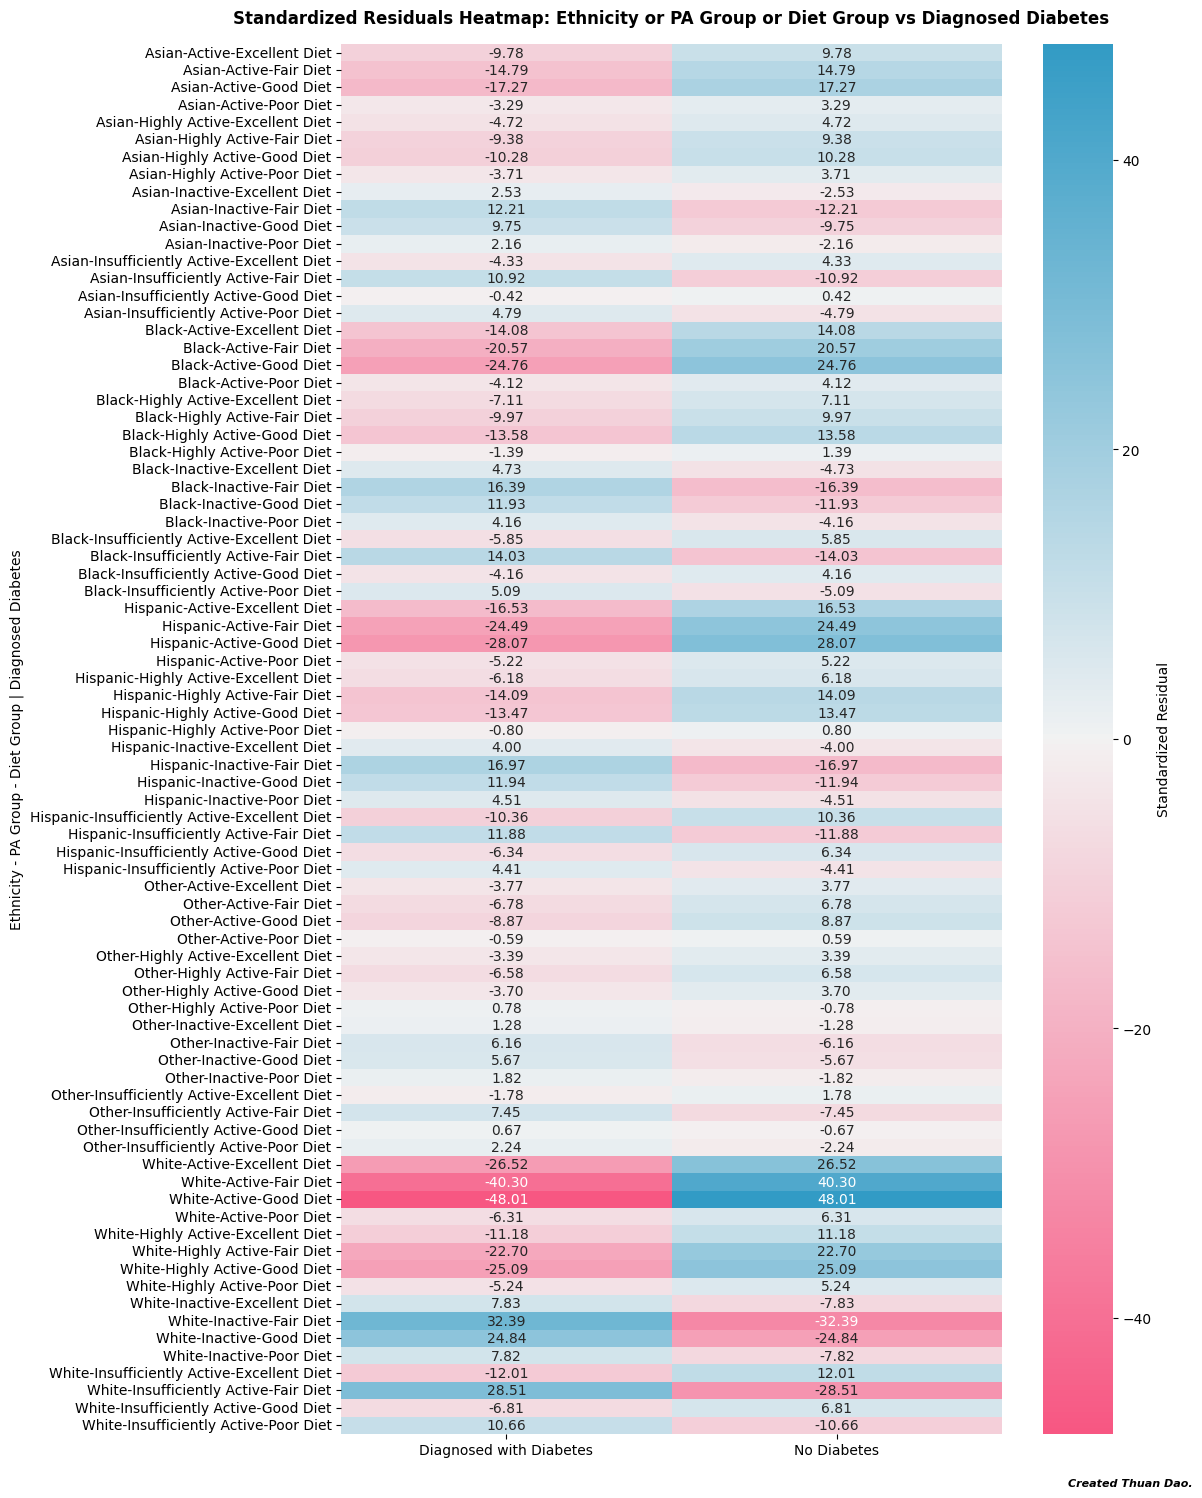

In [48]:
print("[i] Computing percentage table by Ethnicity × PA Group × Diet Group...")
df_group = pd.crosstab(
    [df_plot["ethnicity"], df_plot["pa_group"], df_plot["diet_group"]],
    df_plot["diagnosed_diabetes"],
    normalize="index"
) * 100
display(df_group)

print("[i] Running Chi-Square Test for combined factors (Ethnicity × PA Group × Diet Group) vs Diagnosed Diabetes...")
contingency = pd.crosstab(
    [df_plot["ethnicity"], df_plot["pa_group"], df_plot["diet_group"]],
    df_plot["diagnosed_diabetes"]
)

# Chi-square test + expected counts
chi2, p, dof, expected = chi2_contingency(contingency.values)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print(f"[i] Chi2: {chi2:.4f}")
print(f"[i] dof: {dof}")
print(f"[i] p-value: {p:.6f}")

# Standardized residuals (adjusted)
row_sums = contingency.sum(axis=1).values[:, None]        # shape (R,1)
col_sums = contingency.sum(axis=0).values[None, :]        # shape (1,C)
grand_total = contingency.values.sum()

row_prob = row_sums / grand_total               # R x 1
col_prob = col_sums / grand_total               # 1 x C

denom = np.sqrt(expected * (1 - row_prob) * (1 - col_prob))
std_resid = (contingency.values - expected) / denom

std_resid_df = pd.DataFrame(std_resid, index=contingency.index,
                            columns=contingency.columns)

# Heatmap — display nicely the multiindex
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
plt.figure(figsize=(12,15))
sns.heatmap(
    std_resid_df,
    annot=True, fmt=".2f", cmap=cmap, center=0,
    cbar_kws={"label": "Standardized Residual"}
)
plt.title("Standardized Residuals Heatmap: Ethnicity or PA Group or Diet Group vs Diagnosed Diabetes", weight="bold", fontsize=12, pad=15)
plt.ylabel("Ethnicity - PA Group - Diet Group | Diagnosed Diabetes")
plt.xlabel("")
plt.text(2.2, 83, "Created Thuan Dao.", fontsize=8, color="black", fontweight="bold", style="italic")
plt.tight_layout()
plt.show()

**Analysis:**

**Yes. Certain ethnic groups are more sensitive to lifestyle factors.**

* **White individuals show the strongest sensitivity** — good diet/activity sharply reduces risk, while poor lifestyle dramatically increases it.
* **Hispanic individuals also exhibit clear but moderate sensitivity.**
* **Black individuals show weaker lifestyle-driven shifts in risk.**
* **Asian individuals appear the least sensitive**, with relatively stable diabetes rates regardless of lifestyle cluster.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Re-checking Skew

In [49]:
skew_feature_train, skew_train_df = check_skewness(df_train, "Train Data", numerical_features=num_features)


[i] Skewness for Train Data...
--------------------------------------------------------------------------------
Feature                                  | Skewness  | Remark
--------------------------------------------------------------------------------
physical_activity_minutes_per_week       |   +2.8142 | Highly skewed
triglycerides                            |   +0.1924 | Approximately symmetric
ldl_cholesterol                          |   +0.1323 | Approximately symmetric
screen_time_hours_per_day                |   +0.1141 | Approximately symmetric
systolic_bp                              |   +0.0972 | Approximately symmetric
diet_score                               |   -0.0630 | Approximately symmetric
cholesterol_total                        |   +0.0611 | Approximately symmetric
waist_to_hip_ratio                       |   +0.0377 | Approximately symmetric
bmi                                      |   +0.0321 | Approximately symmetric
hdl_cholesterol                          | 

In [50]:
skew_feature_test, skew_test_df = check_skewness(df_test, "Test Data", numerical_features=num_features)


[i] Skewness for Test Data...
--------------------------------------------------------------------------------
Feature                                  | Skewness  | Remark
--------------------------------------------------------------------------------
physical_activity_minutes_per_week       |   +1.9177 | Highly skewed
ldl_cholesterol                          |   +0.1940 | Approximately symmetric
triglycerides                            |   +0.1544 | Approximately symmetric
systolic_bp                              |   +0.1331 | Approximately symmetric
screen_time_hours_per_day                |   +0.1129 | Approximately symmetric
cholesterol_total                        |   +0.1101 | Approximately symmetric
diet_score                               |   -0.0777 | Approximately symmetric
hdl_cholesterol                          |   -0.0322 | Approximately symmetric
age                                      |   +0.0286 | Approximately symmetric
bmi                                      |  

In [51]:
from sklearn.preprocessing import PowerTransformer

def handle_skewed_features(
    df,
    zero_threshold=0.9,
    skew_threshold=0.5,
    num_features=None,
    exclude_cols=None
):
    """
    Handle skewed numerical features by applying appropriate transformations.

    Parameters:
    - df: pandas.DataFrame
    - zero_threshold: float (default=0.9)
    - skew_threshold: float (default=0.5)
    - num_features: list of numerical columns to consider
    - exclude_cols: list of columns to skip entirely

    Returns:
    - df: transformed DataFrame
    - transformed_cols: list of new feature names
    - high_zero_cols: list of sparse features (> zero_threshold)
    - skewed_cols: list of auto‑detected skewed features
    """
    df = df.copy()
    if num_features is None:
        raise ValueError("`num_features` must be provided")
    if exclude_cols is None:
        exclude_cols = []

    # 1) pick the numeric cols to scan
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # 2) detect ultra‑sparse
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # 3) compute skew
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # 4) union these with your forced list
    to_transform = list(set(auto_skewed))

    transformed_cols = []
    dropped_cols     = []

    for col in to_transform:
        # if it's sparse → binary+log
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x) if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)
        # if it's discrete small‑cardinality, skip transform but keep
        elif df[col].nunique() <= 5:
            # do nothing (we still keep raw col in df)
            continue
        # otherwise apply Yeo‑Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # drop originals for any column we did transform
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed

In [52]:
num_features = ["age", "physical_activity_minutes_per_week", "diet_score", "sleep_hours_per_day", "screen_time_hours_per_day", 
                "bmi", "waist_to_hip_ratio", "systolic_bp", "diastolic_bp", "heart_rate", "cholesterol_total", "hdl_cholesterol", 
                "ldl_cholesterol", "triglycerides"]
cat_features = ["alcohol_consumption_per_week", "gender", "ethnicity", "education_level", "income_level", "smoking_status", 
                "employment_status", "family_history_diabetes", "hypertension_history", "cardiovascular_history"]

In [53]:
processed_train_df, transformed_columns, sparse_columns, skewed_columns = handle_skewed_features(df=df_train, num_features=skew_feature_train)
num_features = ["age", "PT_physical_activity_minutes_per_week", "diet_score", "sleep_hours_per_day", "screen_time_hours_per_day", 
                "bmi", "waist_to_hip_ratio", "systolic_bp", "diastolic_bp", "heart_rate", "cholesterol_total", "hdl_cholesterol", 
                "ldl_cholesterol", "triglycerides"]
skew_feature_train, skew_train_df = check_skewness(processed_train_df, "Train Data", numerical_features=num_features)


[i] Skewness for Train Data...
--------------------------------------------------------------------------------
Feature                                  | Skewness  | Remark
--------------------------------------------------------------------------------
triglycerides                            |   +0.1924 | Approximately symmetric
ldl_cholesterol                          |   +0.1323 | Approximately symmetric
screen_time_hours_per_day                |   +0.1141 | Approximately symmetric
systolic_bp                              |   +0.0972 | Approximately symmetric
diet_score                               |   -0.0630 | Approximately symmetric
cholesterol_total                        |   +0.0611 | Approximately symmetric
waist_to_hip_ratio                       |   +0.0377 | Approximately symmetric
bmi                                      |   +0.0321 | Approximately symmetric
hdl_cholesterol                          |   -0.0213 | Approximately symmetric
age                              

In [54]:
processed_test_df, transformed_columns_test, sparse_columns_test, skewed_columns_test = handle_skewed_features(df=df_test, num_features=skew_feature_test)
skew_feature_test, skew_test_df = check_skewness(data=processed_test_df, numerical_features=num_features,
                                                   dataset_name= "Test data")


[i] Skewness for Test data...
--------------------------------------------------------------------------------
Feature                                  | Skewness  | Remark
--------------------------------------------------------------------------------
ldl_cholesterol                          |   +0.1940 | Approximately symmetric
triglycerides                            |   +0.1544 | Approximately symmetric
systolic_bp                              |   +0.1331 | Approximately symmetric
screen_time_hours_per_day                |   +0.1129 | Approximately symmetric
cholesterol_total                        |   +0.1101 | Approximately symmetric
diet_score                               |   -0.0777 | Approximately symmetric
hdl_cholesterol                          |   -0.0322 | Approximately symmetric
age                                      |   +0.0286 | Approximately symmetric
bmi                                      |   +0.0268 | Approximately symmetric
diastolic_bp                      

**Observations from the Skewness Table (`processed_train_df` and `processed_test_df`):**

**Approximately Symmetric**:

* Several features, such as:

  * `PT_physical_activity_minutes_per_week` close to zero.
  * This indicates that **Yeo-Johnson transformation was effective** for this features.

## Re-check Outliers

In [55]:
checking_outlier(list_feature=num_features, df=processed_train_df, dataset_name="Train Data")

[i] Checking for outliers in Train Data...


,Feature,Outlier Count
0,age,1013
1,PT_physical_activity_minutes_per_week,20328
2,diet_score,1997
3,sleep_hours_per_day,6152
4,screen_time_hours_per_day,2337
5,bmi,4254
6,waist_to_hip_ratio,6159
7,systolic_bp,775
8,diastolic_bp,5752
9,heart_rate,1797


In [56]:
checking_outlier(list_feature=num_features, df=processed_test_df, dataset_name="Test Data")

[i] Checking for outliers in Test Data...


,Feature,Outlier Count
0,age,339
1,PT_physical_activity_minutes_per_week,4892
2,diet_score,1050
3,sleep_hours_per_day,3235
4,screen_time_hours_per_day,1179
5,bmi,2107
6,waist_to_hip_ratio,329
7,systolic_bp,599
8,diastolic_bp,2767
9,heart_rate,1044


**Insight:**

* The health dataset is highly skewed and contains many natural outliers. 
* RobustScaler effectively reduces the influence of extreme values, smooths distributions, and improves model stability—especially during OOF training with XGBoost.

## Create Test Set

* Suppose you chatted with experts who told you that the **bmi** is a very important attribute to predict **diagnosed_diabetes**. <br>
* We may want to ensure that the test set is representative of the various categories of bmi in the whole dataset. Since the bmi is a continuous numerical attribute, we first need to create an category attribute.

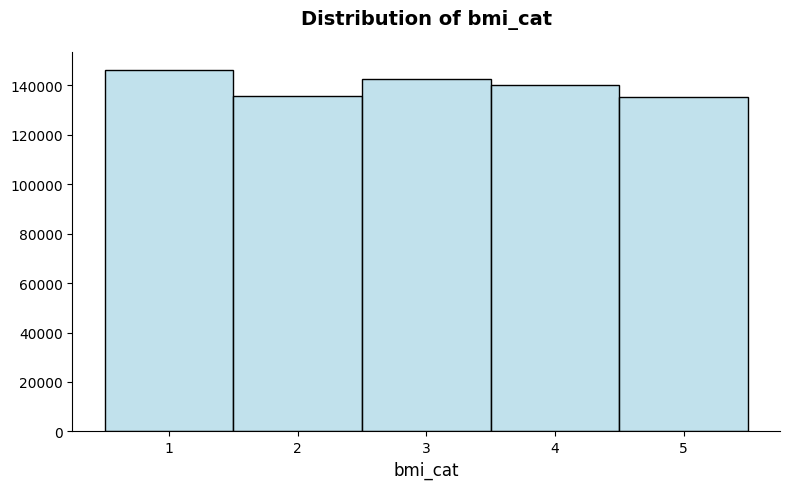

In [57]:
processed_train_df["bmi_cat"] = pd.qcut(processed_train_df["bmi"],
                                              q=5,
                                              labels=[1, 2, 3, 4, 5])

plt.figure(figsize=(8, 5))
sns.histplot(data=processed_train_df, x="bmi_cat", color="lightblue", edgecolor="black")
sns.despine(top=True, right=True, left=False, bottom=False)
plt.title("Distribution of bmi_cat", fontsize=14, weight="bold",pad=20)
plt.xlabel("bmi_cat", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [58]:
split = StratifiedShuffleSplit(n_splits=Config.n_split_shuffle, test_size=Config.test_size, 
                               random_state=Config.seed)
for train_index, val_index in split.split(processed_train_df, processed_train_df["bmi_cat"]):
    start_train_set = processed_train_df.loc[train_index]
    start_val_set = processed_train_df.loc[val_index]

# Now we should remove the bmi_cat attribute so the data is back to its original state:
for set_ in (start_train_set, start_val_set): 
    set_.drop("bmi_cat", axis=1, inplace=True)

df_train_new = start_train_set.drop("diagnosed_diabetes", axis=1)
df_train_label = start_train_set["diagnosed_diabetes"].copy()

## Scale and Encode

In [59]:
robust_transfomer = Pipeline(steps=[
    ("scaler", RobustScaler()),
    ("imputer", SimpleImputer(strategy="median"))
])

cat_transfomer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_robust", robust_transfomer, num_features),
        ("cat", cat_transfomer, cat_features),
    ]
)

preprocessor.fit(df_train_new)

df_train_new_prepared = preprocessor.transform(df_train_new)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num_standard__", "").replace("num_robust__", "").replace("cat__", "").replace("PT_", "") for col in list_feature_prepared]
clean_features

['age',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'alcohol_consumption_per_week_1',
 'alcohol_consumption_per_week_2',
 'alcohol_consumption_per_week_3',
 'alcohol_consumption_per_week_4',
 'alcohol_consumption_per_week_>=5',
 'gender_Female',
 'gender_Male',
 'gender_Other',
 'ethnicity_Asian',
 'ethnicity_Black',
 'ethnicity_Hispanic',
 'ethnicity_Other',
 'ethnicity_White',
 'education_level_Graduate',
 'education_level_Highschool',
 'education_level_No formal',
 'education_level_Postgraduate',
 'income_level_High',
 'income_level_Low',
 'income_level_Lower-Middle',
 'income_level_Middle',
 'income_level_Upper-Middle',
 'smoking_status_Current',
 'smoking_status_Former',
 'smoking_status_Never',
 'employment_status_Employed',
 'employment_status_Retired',
 'emp

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Metric
    </h1>
</div>


**AUC-ROC Overview**

**AUC-ROC** evaluates a model’s ability to **distinguish between two classes**.

* **ROC curve** plots **TPR vs FPR**
* **AUC** = Area under ROC curve → **ranking quality of predictions**

**Why AUC-ROC?**

* Robust to **class imbalance**
* Measures **ranking ability**, not fixed threshold (0.5)
* Common metric in **credit risk & fraud prediction**

> Higher AUC → better separation between *Paid* vs *Default*

**Interpretation**

| AUC Score     | Meaning                  |
| ------------- | ------------------------ |
| **1.0**       | Perfect model            |
| **0.9+**      | Excellent discrimination |
| **0.7 – 0.9** | Good                     |
| **0.5**       | Random guessing          |
| **< 0.5**     | Worse than random        |

(Source: [ROC AUC](https://en.wikipedia.org/wiki/Receiver_operating_characteristic))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>

In [60]:
def shap_plot(model, X_test, list_feature, type = None):
     # https://towardsdatascience.com/using-shap-values-to-explain-how-your-machine-learning-model-works-732b3f40e137/
    if hasattr(X_test, "toarray"):
        X_test = X_test.toarray()
    X_test_sample = pd.DataFrame(X_test, columns=list_feature)
    explainer = shap.Explainer(model.predict, X_test_sample)
    shap_values = explainer(X_test_sample)
    if type =="bar":
        shap_importance = np.abs(shap_values.values).mean(axis=0)
        shap_df = pd.DataFrame({"feature": X_test_sample.columns, "importance": shap_importance})
        shap_df = shap_df.sort_values("importance", ascending=False).head(20)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=shap_df["importance"], y=shap_df["feature"], palette="viridis", order=shap_df["feature"])
        plt.xlabel("mean(|SHAP value|)")
        plt.title("SHAP Feature Importance", fontsize=12, weight="bold", pad=15)
        plt.tight_layout()
        plt.show()
    else:
        shap.summary_plot(shap_values, X_test_sample)

In [61]:
X_val = start_val_set.drop("diagnosed_diabetes", axis=1)
y_val = start_val_set["diagnosed_diabetes"].copy()
X_val_prepared = preprocessor.transform(X_val)

## XGBClassifier

In [62]:
def run_oof(model, X, y, X_test, n_splits=Config.n_split_kfold):
    print(f"[i] Starting OOF training with {model.__class__.__name__}...")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    oof_pred = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    fold_models = []
    fold_auc = []

    # For plotting
    roc_curves = []
    pr_curves = []
    auc_values = []
    ap_values = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        print(f"\n[i] Fold {fold+1}/{n_splits}...")

        X_train, X_valid = X[train_idx], X[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False,
            early_stopping_rounds=300
        )

        fold_models.append(model)

        # Predict fold
        fold_pred = model.predict_proba(
            X_valid,
            iteration_range=(0, model.best_iteration + 1)
        )[:, 1]

        oof_pred[valid_idx] = fold_pred

        # Test prediction
        test_pred += model.predict_proba(
            X_test,
            iteration_range=(0, model.best_iteration + 1)
        )[:, 1] / n_splits

        # === Compute AUC for the fold ===
        auc_fold = roc_auc_score(y_valid, fold_pred)
        fold_auc.append(auc_fold)
        print(f"[✓] Fold {fold+1} - AUC: {auc_fold:.5f}")

        # === ROC curve by fold ===
        fpr, tpr, _ = roc_curve(y_valid, fold_pred)
        roc_curves.append((fpr, tpr))

        # === Precision–Recall curve by fold ===
        precision, recall, _ = precision_recall_curve(y_valid, fold_pred)
        pr_curves.append((recall, precision))

        # Average Precision for fold
        ap = average_precision_score(y_valid, fold_pred)
        ap_values.append(ap)

    # Final OOF AUC
    oof_auc = roc_auc_score(y, oof_pred)
    print("\n==========================")
    print(f"[i] OOF AUC: {oof_auc:.5f}")
    print(f"[✓] Fold AUCs: {fold_auc}")
    print("==========================\n")

    # 3 SUBPLOTS: ROC, PR, CONF MATRIX

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # ------------------------ ROC Curve ------------------------
    ax = axes[0, 0]
    for i, (fpr, tpr) in enumerate(roc_curves):
        ax.plot(fpr, tpr, label=f"Fold {i+1} AUC = {fold_auc[i]:.4f}")

    ax.plot([0,1], [0,1], "--", color="gray")
    ax.set_title("ROC Curve (Each Fold)", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(True)

    # --------------------- PR Curve ---------------------------
    ax = axes[0, 1]
    for i, (recall, precision) in enumerate(pr_curves):
        ax.plot(recall, precision, label=f"Fold {i+1} AP = {ap_values[i]:.4f}")

    ax.set_title("Precision–Recall Curve (Each Fold)", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.grid(True)

    # --------------------- Confusion Matrix --------------------
    ax = axes[1, 0]
    threshold = 0.5
    y_pred_label = (oof_pred >= threshold).astype(int)
    cm = confusion_matrix(y, y_pred_label)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix (Threshold = 0.5)", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax = axes[1, 1]
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return oof_pred, test_pred, fold_models

[i] Starting OOF training with XGBClassifier...

[i] Fold 1/5...
[✓] Fold 1 - AUC: 0.72552

[i] Fold 2/5...
[✓] Fold 2 - AUC: 0.72779

[i] Fold 3/5...
[✓] Fold 3 - AUC: 0.72736

[i] Fold 4/5...
[✓] Fold 4 - AUC: 0.72855

[i] Fold 5/5...
[✓] Fold 5 - AUC: 0.72715

[i] OOF AUC: 0.72727
[✓] Fold AUCs: [0.7255235924178547, 0.7277908402943133, 0.7273605103221354, 0.7285466807321362, 0.7271549156437304]



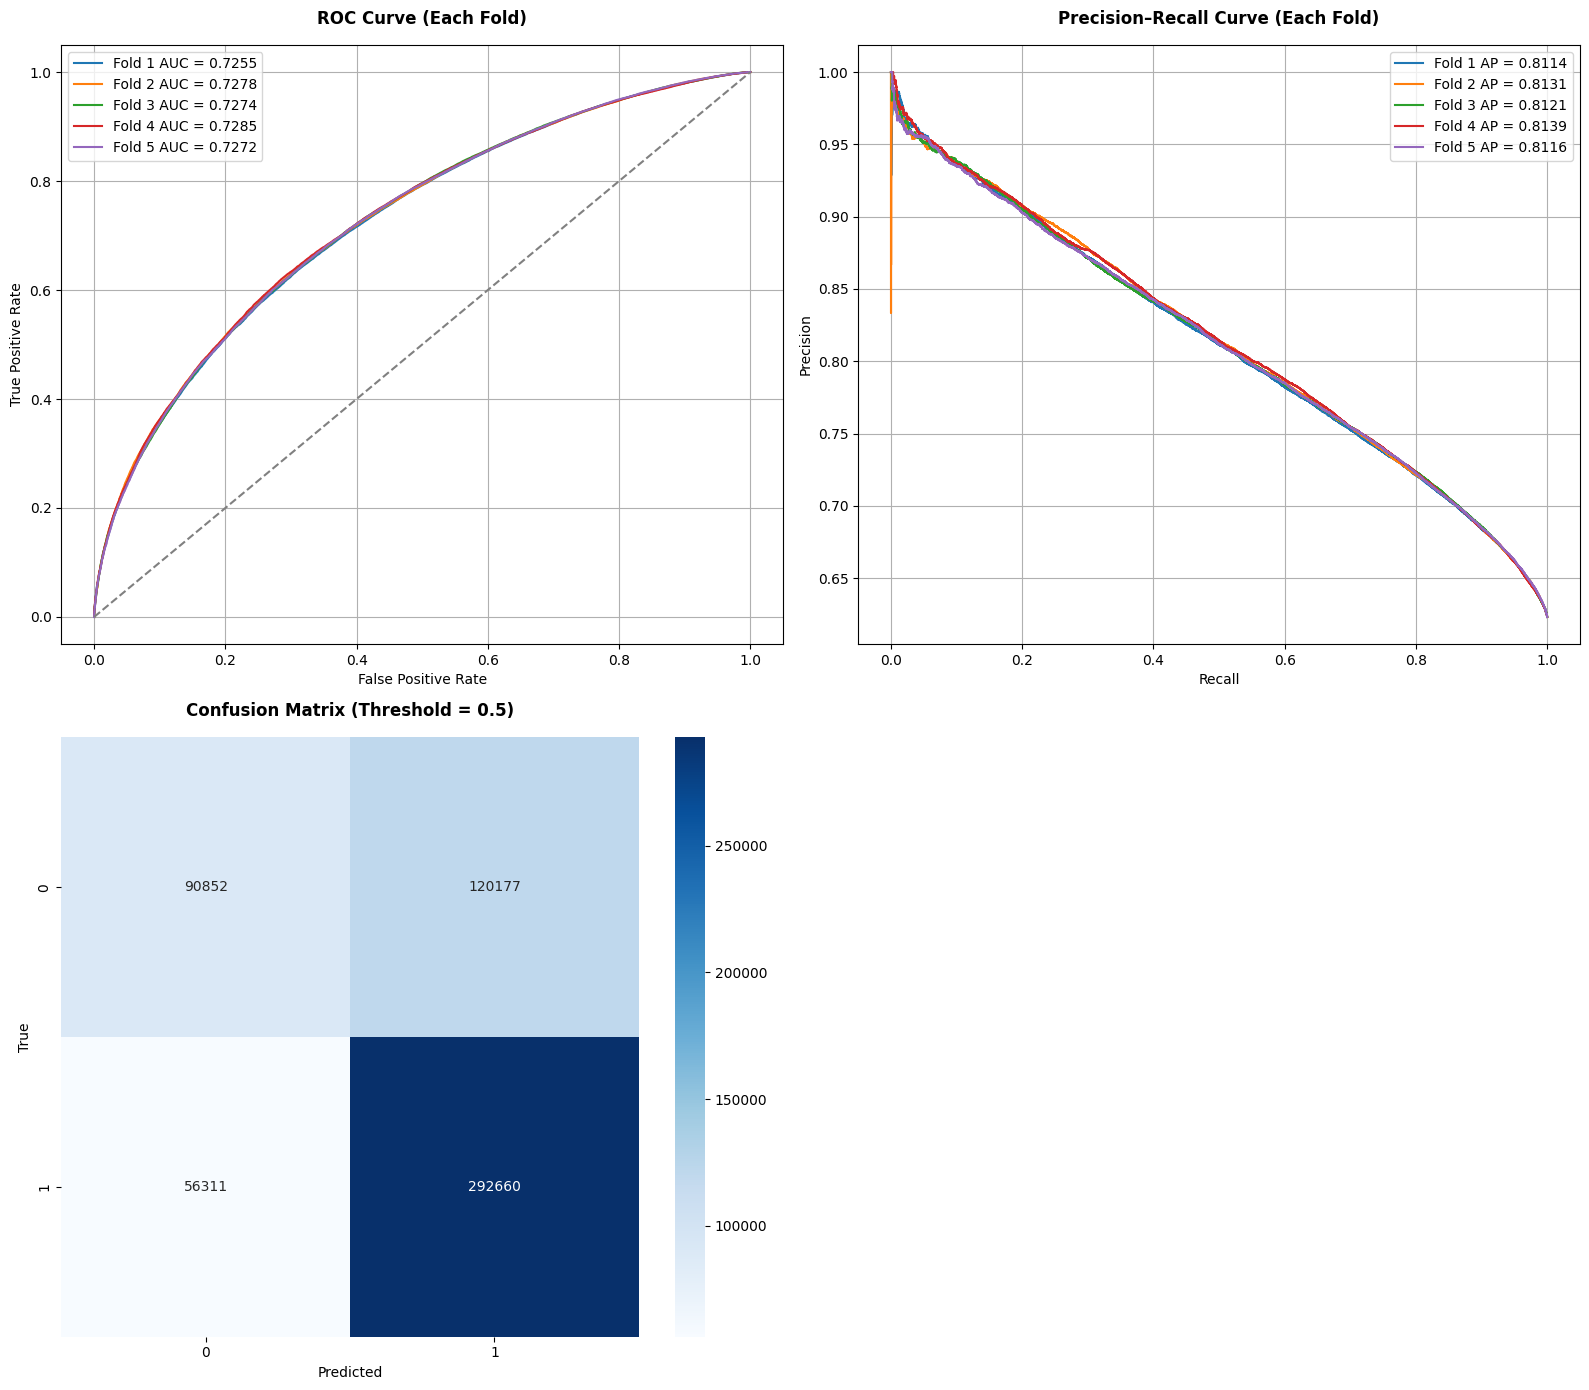

In [63]:
param_xgb = {
"learning_rate": 0.010101790233963715, 
"max_depth": 4, 
"min_child_weight": 7.875908100225339, 
"subsample": 0.7225393932188394, 
"colsample_bytree": 0.5325708121965714, 
"gamma": 1.2582788478340508,
"lambda": 0.016947240752074988, 
"alpha": 7.335937487680093, 
"max_leaves": 123,
"booster": "gbtree",
"random_state": Config.seed,
"use_label_encoder": False,
"verbosity": 0,
"tree_method": "gpu_hist",
"predictor": "gpu_predictor",
"grow_policy": "lossguide",
"n_jobs": -1,
"n_estimators": 20000,
"max_bin": 256,
"objective": "binary:logistic",
"eval_metric": "auc"    
}

model_xgb = xgb.XGBClassifier(**param_xgb)

df_test_prepared = preprocessor.transform(processed_test_df)
oof_pred, test_pred, fold_models = run_oof(model = model_xgb, X = df_train_new_prepared, y = df_train_label.values, 
           X_test = df_test_prepared)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Prepare Final Submission File</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Prepare Final Submission File
    </h1>
</div>


In [64]:
# Prepare submission file
submission = pd.DataFrame({
    "id": list_test_id,
    "diagnosed_diabetes": test_pred
})

submission.to_csv("submission.csv", index=False)
print("\nSubmission file saved!")
submission.head()


Submission file saved!


,id,diagnosed_diabetes
0,700000,0.394760
1,700001,0.648495
2,700002,0.725344
3,700003,0.635323
4,700004,0.854980


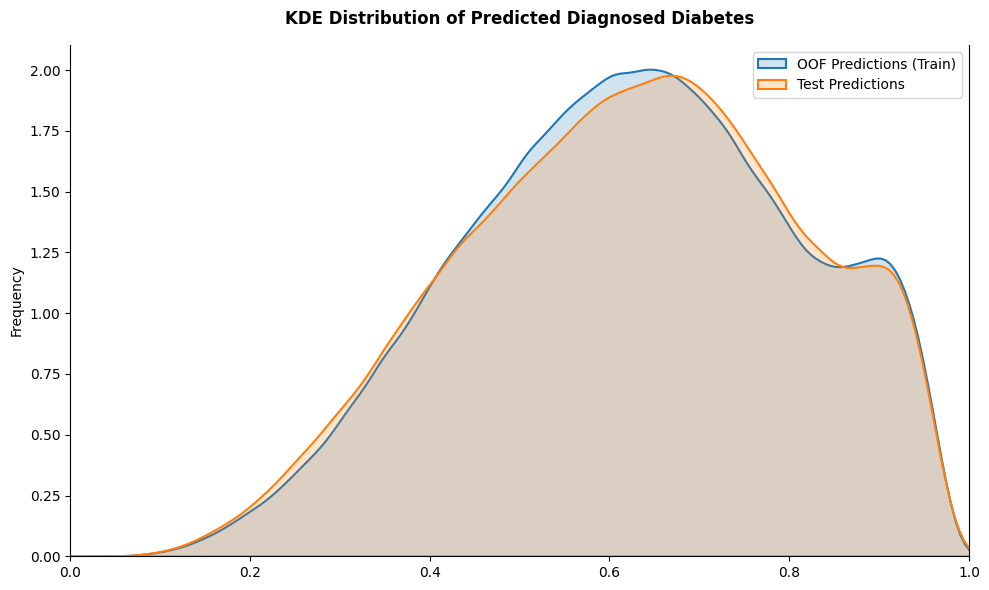

In [65]:
# Plot distribution of predicted probabilities
plt.figure(figsize=(10, 6))
sns.kdeplot(oof_pred, fill=True, linewidth=1.5, alpha=0.2, label="OOF Predictions (Train)")
sns.kdeplot(test_pred, fill=True, linewidth=1.5, alpha=0.2, label="Test Predictions")
plt.title("KDE Distribution of Predicted Diagnosed Diabetes", weight="bold", pad=15, fontsize=12)
plt.xlabel("Predicted Probability of Diagnosed Diabetes")
sns.despine(left=False, bottom=False, right=False)
plt.ylabel("Frequency")
plt.xlabel("")
plt.xlim(0, 1)  # Limit x-axis to [0, 1]
plt.legend()
plt.tight_layout()
plt.show()

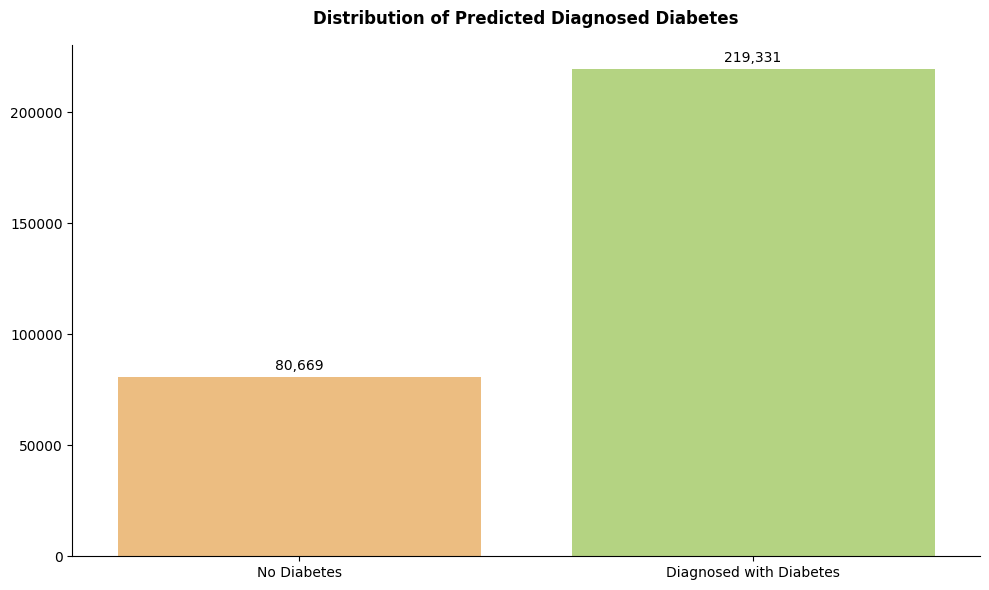

In [66]:
# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
binary_predictions = (test_pred > 0.5).astype(int)

# Plot distribution of binary predictions
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=binary_predictions.flatten(), palette= "RdYlGn")
plt.title("Distribution of Predicted Diagnosed Diabetes", weight="bold", pad=15, fontsize=12)
plt.xlabel("Diagnosed Diabetes (0: No Diabetes, 1: Diagnosed with Diabetes)")
plt.ylabel("")
plt.xlabel("")
sns.despine(left=False, bottom=False)
plt.xticks(ticks=[0, 1], labels=["No Diabetes", "Diagnosed with Diabetes"])
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(
        f"{count:,}", 
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="baseline",
        fontsize=10,
        xytext=(0, 5),
        textcoords="offset points"
    )
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 1001it [11:26,  1.44it/s]


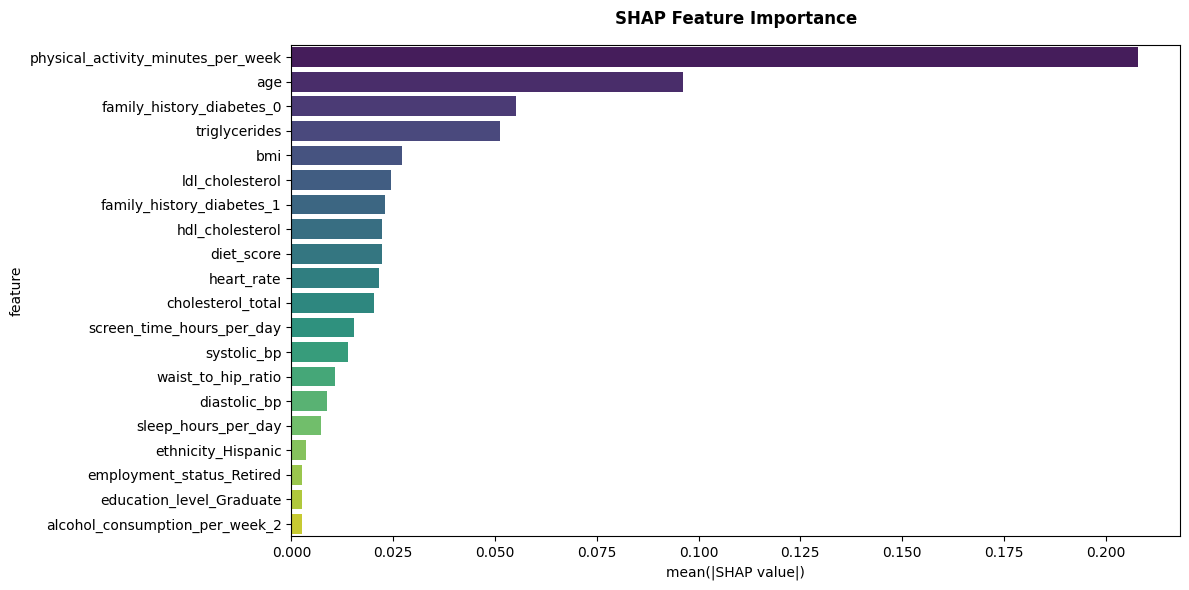

In [67]:
shap_plot(model=model_xgb, X_test=df_test_prepared[:1000], list_feature=clean_features, type="bar")

PermutationExplainer explainer: 1001it [11:24,  1.44it/s]


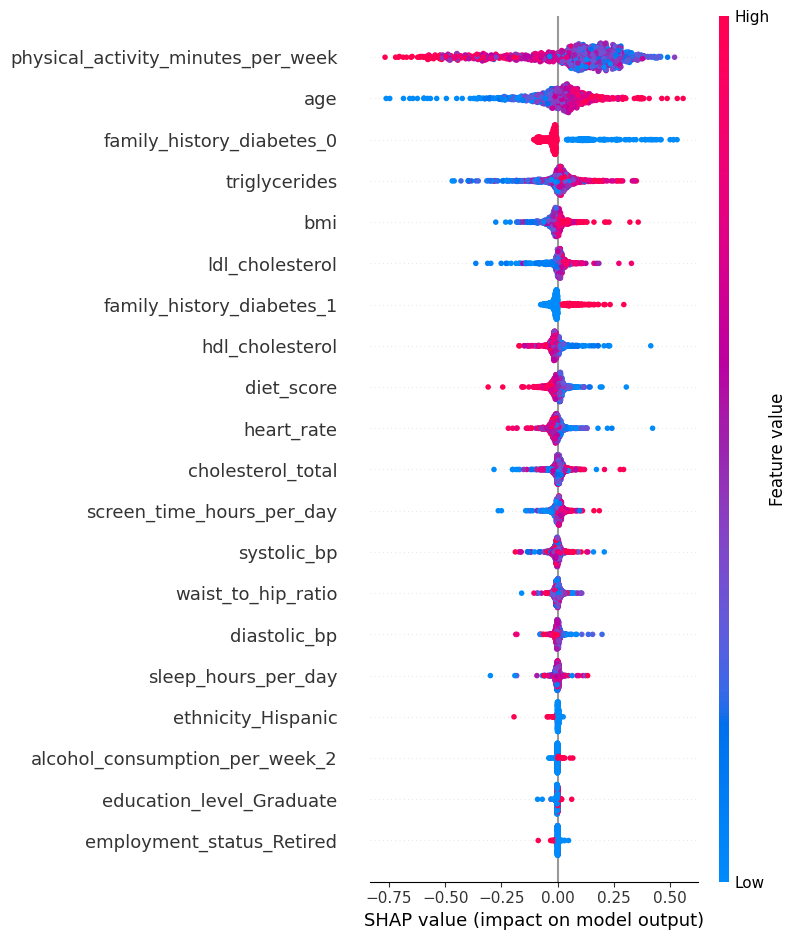

In [68]:
shap_plot(model=model_xgb, X_test=df_test_prepared[:1000], list_feature=clean_features)

**Key Insights (Slide Summary)**



***Physical activity is the most influential protective factor, while age, family history, triglycerides, BMI, and LDL are the strongest drivers of diabetes risk in the SHAP model. Most lifestyle factors (diet, sleep, screen time) show smaller effects, highlighting that metabolic health and heredity dominate predictive power.***

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Conclusion</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Conclusion
    </h1>
</div>

| **Feature**                            | **Summary**                                                                                                                                              |
| -------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **age**                                | Individuals with diabetes are generally **older**, and age shows a **moderate practical impact**, making it a strong distinguishing feature.             |
| **physical_activity_minutes_per_week** | Non-diabetic individuals engage in **more physical activity**. Lower activity levels are **meaningfully linked** to higher diabetes prevalence.          |
| **diet_score**                         | Differences are statistically significant but **very small in effect**, meaning diet score alone is **not a strong discriminator**.                      |
| **sleep_hours_per_day**                | Sleep duration is nearly identical between groups → **not a meaningful predictor** despite statistical significance.                                     |
| **screen_time_hours_per_day**          | Extremely small effect size; screen time is **not a practical differentiator** between diabetic and non-diabetic individuals.                            |
| **bmi**                                | Individuals with diabetes have **higher BMI**. Medium effect size → BMI is a **notable and relevant predictor** of diabetes risk.                        |
| **waist_to_hip_ratio**                 | Diabetic individuals show **higher central obesity**. A small but meaningful trend aligned with medical evidence.                                        |
| **systolic_bp**                        | Higher systolic BP is more common in diabetes; **moderate effect size** → a useful cardiometabolic indicator.                                            |
| **diastolic_bp**                       | Small effect size → diastolic BP alone is **not a strong differentiator**, though it contributes when combined with systolic BP.                         |
| **heart_rate**                         | Very small effect size → heart rate is **not a strong standalone predictor**, but supports broader cardiometabolic profiling.                            |
| **cholesterol_total**                  | Small effect size, but total cholesterol remains a **supporting cardiovascular risk marker** when combined with other lipid indicators.                  |
| **hdl_cholesterol**                    | Small effect → HDL alone is **not a strong discriminator**, though clinically relevant as part of lipid profile.                                         |
| **ldl_cholesterol**                    | Statistically and practically meaningful; diabetic individuals have **higher LDL**, indicating increased cardiovascular risk.                            |
| **triglycerides**                      | Diabetic individuals show **elevated triglycerides**; small-to-moderate effect and clinically relevant.                                                  |
| **alcohol_consumption_per_week**       | Mild association; moderate consumption levels (2–4×/week) show **slightly higher diabetes prevalence**.                                                  |
| **gender**                             | Mild association but **no group deviates strongly** from expected patterns.                                                                              |
| **ethnicity**                          | Statistically associated; Hispanic and some Asian/Other subgroups show the **most notable deviations**.                                                  |
| **education_level**                    | Meaningful association; *Graduate* and *No-formal* groups show **higher diabetes rates**, while *Postgraduates* show **lower-than-expected** prevalence. |
| **income_level**                       | Lower-income groups show **higher diabetes prevalence**, whereas middle-income individuals are **below expectation**.                                    |
| **smoking_status**                     | **No meaningful difference** between diabetic and non-diabetic individuals.                                                                              |
| **employment_status**                  | Mild association; the **Retired** group contributes the most to deviation, while other groups show small differences.                                    |
| **family_history_diabetes**            | **Strongest categorical predictor** — individuals with family history are **significantly more likely** to have diabetes.                                |
| **hypertension_history**               | Strong indicator — those with hypertension are **much more likely** to be diabetic.                                                                      |
| **cardiovascular_history**             | Significant risk marker — history of cardiovascular disease is **strongly linked** to diabetes diagnosis.                                                |


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>

| **Risk Category**                                          | **Observed Risk Pattern**                                                                       | **Recommended Action**                                                                                                 | **Target Group / Priority**                      |
| ---------------------------------------------------------- | ----------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------ |
| **1. Weight & Obesity (BMI, WHR)**                         | High BMI and central obesity are strong predictors of diabetes.                                 | - Weight reduction toward Normal BMI<br>- Increase muscle mass, reduce abdominal fat<br>- Reduce sugar & refined carbs | Overweight/obese individuals, high WHR           |
| **2. Physical Inactivity**                                 | Low physical activity is clearly linked to higher diabetes prevalence.                          | - ≥150 min/week of exercise<br>- Increase daily steps<br>- Take breaks during prolonged sitting                        | Sedentary individuals, office workers            |
| **3. Screen Time Excess**                                  | High screen time + low activity amplifies diabetes risk.                                        | - Limit screen exposure<br>- 5-min break every 45 minutes                                                              | Heavy device users, office workers               |
| **4. Cardiometabolic Indicators (BP, LDL, Triglycerides)** | High BP, LDL, and triglycerides strongly predict diabetes.                                      | - Control blood pressure<br>- Lower LDL with diet/exercise<br>- Reduce saturated & trans fats                          | Individuals with hypertension or dyslipidemia    |
| **5. Total Cholesterol / HDL**                             | Small independent effect, but supports cardiovascular risk assessment.                          | - Regular lipid monitoring<br>- Increase HDL via exercise & healthy fats                                               | Adults, especially 40+                           |
| **6. Diet Quality (Diet Score)**                           | Weak independent effect but becomes meaningful when combined with BMI & inactivity.             | - Mediterranean / Healthy Plate diet<br>- Increase fiber, vegetables<br>- Reduce sugar & processed food                | All individuals, especially high-BMI or inactive |
| **7. Alcohol Consumption**                                 | Moderate alcohol use (2–4×/week) slightly increases risk, especially combined with high BMI.    | - Reduce frequency & volume of alcohol intake<br>- Avoid binge drinking                                                | Regular drinkers, overweight individuals         |
| **8. Age**                                                 | Older individuals show higher diabetes prevalence.                                              | - Earlier and more frequent screening<br>- Monitor BP and lipid levels                                                 | Age 40+, especially with family history          |
| **9. Family History (Strongest predictor)**                | Strongest categorical risk factor — family history significantly increases diabetes likelihood. | - Early screening<br>- More aggressive lifestyle interventions                                                         | Individuals with diabetic parents/siblings       |
| **10. Hypertension**                                       | Strongly associated with diabetes — hypertensive individuals have much higher prevalence.       | - Strict BP control<br>- Reduce salt & manage stress                                                                   | People with hypertension                         |
| **11. Cardiovascular History**                             | Individuals with prior heart conditions have much higher diabetes rates.                        | - Close monitoring of glucose & lipids<br>- Enhanced cardiometabolic management                                        | People with cardiovascular disease               |
| **12. Sleep Duration**                                     | Minimal predictive value.                                                                       | - Maintain 7–9 hours of sleep<br>- Reduce stress, avoid late nights                                                    | Everyone                                         |
| **13. Smoking Status**                                     | No meaningful difference observed.                                                              | - Encourage smoking cessation for overall health                                                                       | Smokers                                          |
| **14. Gender**                                             | Mild association; no strong deviations.                                                         | - No gender-specific intervention required                                                                             | All groups                                       |
| **15. Ethnicity**                                          | Some ethnic groups (Hispanic, Asian/Other) show higher-than-expected prevalence.                | - Targeted health education & early screening                                                                          | Higher-risk ethnic groups                        |
| **16. Education Level**                                    | Lower education levels linked to higher diabetes rates; postgraduates are lowest risk.          | - Health education programs<br>- Early screening for high-risk groups                                                  | Low-education populations                        |
| **17. Income Level**                                       | Lower-income groups show the highest diabetes prevalence.                                       | - Improve access to healthcare<br>- Promote low-cost healthier diet options                                            | Low-income individuals                           |
| **18. Employment Status**                                  | Retired individuals drive most of the deviation.                                                | - Increase screening frequency<br>- Encourage daily light exercise                                                     | Older adults, retirees                           |


**Summary:**

Diabetes prevention should prioritize weight control, increased physical activity, and cardiometabolic management (BP, LDL, triglycerides), especially for high-risk groups such as individuals with family history, hypertension, cardiovascular disease, low income, or low education. Lifestyle modifications—including reduced alcohol intake, better diet quality, and regular health screenings—further enhance prevention effectiveness.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
